In [3]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import glob

PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "gen_pop_carriers"

client = bigquery.Client(project=PROJECT_ID)

In [ ]:
scratch_dataset_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}"
scratch_dataset = bigquery.Dataset(scratch_dataset_id)
scratch_dataset.location = "US"

try:
    scratch_dataset = client.create_dataset(scratch_dataset, timeout=30)
    print(f" Created scratch dataset: {scratch_dataset_id}")
except Exception as e:
    if "Already Exists" in str(e):
        print(f" Scratch dataset already exists: {scratch_dataset_id}")
    else:
        print(f" Error creating dataset: {e}")
        
print(f"Working Configuration:")
print(f"  Project: {PROJECT_ID}")
print(f"  Scratch Dataset: {SCRATCH_DATASET_ID}")
print(f"  Location: US")

In [2]:
import pandas as pd
import numpy as np
from google.cloud import bigquery
import os

# Load PRS scores for everyone
print("\nLoading: prs_scores_all_samples.tsv")
df_prs_hcm = pd.read_csv('/home/jupyter/prs_output/prs_scores_all_samples.tsv', sep='\t')
print(f"   Loaded: {len(df_prs_hcm):,} rows, {len(df_prs_hcm.columns)} columns")
print(f"   Columns: {list(df_prs_hcm.columns)}")

# Rename IID to person_id, PRS to prs
df_prs_hcm = df_prs_hcm.rename(columns={'IID': 'person_id', 'PRS': 'prs'})
print(f"   Standardized columns to: {list(df_prs_hcm.columns)}")

# Load variant information for carriers
print("\nLoading: all_carriers_long_format.tsv")
df_hcm_variants = pd.read_csv('/home/jupyter/Invitae_HCM/all_carriers_long_format.tsv', sep='\t')
print(f"   Loaded: {len(df_hcm_variants):,} rows, {len(df_hcm_variants.columns)} columns")
print(f"   Columns: {list(df_hcm_variants.columns)}")
print(f"   Unique persons with variants: {df_hcm_variants['IID'].nunique()}")

# Rename IID to person_id
df_hcm_variants = df_hcm_variants.rename(columns={'IID': 'person_id'})
print(f"   Standardized columns to: {list(df_hcm_variants.columns)}")

#  Filter to only General Population Carriers (is_hcm = 0)

print(f"Total carriers before filtering: {df_hcm_variants['person_id'].nunique()}")
print(f"   is_hcm=1 (HCM carriers): {df_hcm_variants[df_hcm_variants['is_hcm']==1]['person_id'].nunique()}")
print(f"   is_hcm=0 (Gen Pop carriers): {df_hcm_variants[df_hcm_variants['is_hcm']==0]['person_id'].nunique()}")
    
# Filter to only gen pop carriers
df_gen_pop_carriers = df_hcm_variants[df_hcm_variants['is_hcm'] == 0].copy()
    
print(f"\nAfter filtering to is_hcm=0:")
print(f"   Rows: {len(df_gen_pop_carriers):,}")
print(f"   Unique persons: {df_gen_pop_carriers['person_id'].nunique()}")

# Extract PRS Scores for Gen Pop Carriers

# Get unique gen pop carrier IDs
gen_pop_carrier_ids = df_gen_pop_carriers['person_id'].unique()
print(f"Gen Pop Carrier IDs to extract: {len(gen_pop_carrier_ids)}")

# Extract PRS scores for these IDs
df_prs_gen_pop = df_prs_hcm[df_prs_hcm['person_id'].isin(gen_pop_carrier_ids)].copy()

print(f"\nPRS Scores extracted:")
print(f"   Total PRS records: {len(df_prs_gen_pop)}")
print(f"   Unique persons with PRS: {df_prs_gen_pop['person_id'].nunique()}")
print(f"   Missing PRS scores: {df_prs_gen_pop['prs'].isna().sum()}")

# STEP 3: Save Locally

output_file = '/home/jupyter/prs_output/prs_scores_gen_pop_carriers.tsv'
df_prs_gen_pop.to_csv(output_file, sep='\t', index=False)
print(f" Saved to: {output_file}")
print(f"   Rows: {len(df_prs_gen_pop):,}")
print(f"   Columns: {list(df_prs_gen_pop.columns)}")

# Show summary statistics
print(f"\nPRS Summary for Gen Pop Carriers:")
print(df_prs_gen_pop['prs'].describe())

#  save the gen pop carriers variant info

output_file_variants = '/home/jupyter/gen_pop_carriers_variants.tsv'
df_gen_pop_carriers.to_csv(output_file_variants, sep='\t', index=False)
print(f" Saved to: {output_file_variants}")
print(f"   Rows: {len(df_gen_pop_carriers):,}")
print(f"   Unique persons: {df_gen_pop_carriers['person_id'].nunique()}")


Loading: prs_scores_all_samples.tsv
   Loaded: 250,115 rows, 3 columns
   Columns: ['FID', 'IID', 'PRS']
   Standardized columns to: ['FID', 'person_id', 'prs']

Loading: all_carriers_long_format.tsv
   Loaded: 1,563 rows, 7 columns
   Columns: ['Gene', 'IID', 'FID', 'is_hcm', 'variant_id', 'dosage', 'genotype']
   Unique persons with variants: 1558
   Standardized columns to: ['Gene', 'person_id', 'FID', 'is_hcm', 'variant_id', 'dosage', 'genotype']
Total carriers before filtering: 1558
   is_hcm=1 (HCM carriers): 46
   is_hcm=0 (Gen Pop carriers): 1512

After filtering to is_hcm=0:
   Rows: 1,516
   Unique persons: 1512
Gen Pop Carrier IDs to extract: 1512

PRS Scores extracted:
   Total PRS records: 1512
   Unique persons with PRS: 1512
   Missing PRS scores: 0
 Saved to: /home/jupyter/prs_output/prs_scores_gen_pop_carriers.tsv
   Rows: 1,512
   Columns: ['FID', 'person_id', 'prs']

PRS Summary for Gen Pop Carriers:
count    1512.000000
mean       -4.037960
std         0.641228
min

In [5]:
# Load gender data from age_at_last_visit_carriers_only.tsv
print("\nLoading: age_at_last_visit_carriers_only.tsv")
df_carrier_demographics = pd.read_csv('/home/jupyter/Invitae_HCM/age_at_last_visit_carriers_only.tsv', sep='\t')
print(f"   Loaded: {len(df_carrier_demographics):,} rows, {len(df_carrier_demographics.columns)} columns")
print(f"   Columns: {list(df_carrier_demographics.columns)}")

# Rename IID to person_id
if 'IID' in df_carrier_demographics.columns:
    df_carrier_demographics = df_carrier_demographics.rename(columns={'IID': 'person_id'})
    print(f"   Renamed IID to person_id")

df_carrier_demographics = df_carrier_demographics[
    df_carrier_demographics['gender_concept_id'].isin([8507, 8532])
]
print(f"   Excluded unknown: {len(df_carrier_demographics):,} rows remaining")

# Filter to ONLY gen pop carriers
gen_pop_carrier_ids = set(df_gen_pop_carriers['person_id'].unique())
df_carrier_demographics = df_carrier_demographics[df_carrier_demographics['person_id'].isin(gen_pop_carrier_ids)]
print(f"   Filtered to gen pop carriers only: {len(df_carrier_demographics):,} rows")

if 'gender_concept_id' in df_carrier_demographics.columns:
    print(f"   Gen pop carriers gender distribution:")
    print(f"      Male (8507): {(df_carrier_demographics['gender_concept_id'] == 8507).sum()}")
    print(f"      Female (8532): {(df_carrier_demographics['gender_concept_id'] == 8532).sum()}")

# Upload DataFrames to BigQuery
def upload_dataframe_to_bq(df, table_name, dataset_id, project_id):
    """Upload a pandas DataFrame to BigQuery"""
    table_id = f"{project_id}.{dataset_id}.{table_name}"
    
    job_config = bigquery.LoadJobConfig(
        write_disposition="WRITE_TRUNCATE",
        autodetect=True 
    )
    
    job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
    job.result() 
    
    table = client.get_table(table_id)
    print(f"    Uploaded to BigQuery: {table.num_rows:,} rows")
    return table_id

# Gen pop carriers PRS scores
print("\nUploading: prs_scores_gen_pop_carriers")
table_id_prs_gen_pop = upload_dataframe_to_bq(
    df_prs_gen_pop,
    'prs_scores_gen_pop_carriers',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)

# Gen pop carriers variant info
print("\nUploading: gen_pop_carriers_variants")
table_id_gen_pop_variants = upload_dataframe_to_bq(
    df_gen_pop_carriers,
    'gen_pop_carriers_variants',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)

# Gen pop carrier demographics (includes gender)
print("\nUploading: gen_pop_carrier_demographics")
table_id_demographics = upload_dataframe_to_bq(
    df_carrier_demographics,
    'gen_pop_carrier_demographics',
    SCRATCH_DATASET_ID,
    PROJECT_ID
)

# Verification
verify_gen_pop_query = f"""
SELECT 
  COUNT(DISTINCT v.person_id) as n_carriers,
  COUNT(DISTINCT p.person_id) as n_with_prs,
  COUNT(DISTINCT d.person_id) as n_with_demographics
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_variants` v
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.prs_scores_gen_pop_carriers` p
  ON v.person_id = p.person_id
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carrier_demographics` d
  ON v.person_id = d.person_id
WHERE v.is_hcm = 0
"""

result = client.query(verify_gen_pop_query).to_dataframe()
print(result.to_string(index=False))

# Check gender distribution for gen pop carriers
verify_gen_pop_gender_query = f"""
SELECT 
  CASE 
    WHEN d.gender_concept_id = 8507 THEN 'Male'
    WHEN d.gender_concept_id = 8532 THEN 'Female'
    ELSE 'Unknown'
  END as gender,
  COUNT(DISTINCT v.person_id) as n_gen_pop_carriers
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_variants` v
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carrier_demographics` d
  ON v.person_id = d.person_id
WHERE v.is_hcm = 0
GROUP BY gender
ORDER BY gender
"""

result = client.query(verify_gen_pop_gender_query).to_dataframe()
print("\n Gen Pop Carriers Gender Distribution:")
print(result.to_string(index=False))

# Summary
print("Summary")
n_gen_pop_carriers = df_gen_pop_carriers['person_id'].nunique()
print(f"   - Gen Pop Carriers: {n_gen_pop_carriers}")
print(f"   - Gen Pop Carriers with demographics: {df_carrier_demographics['person_id'].nunique()}")
print(f"   - Gen Pop Carriers with PRS: {df_prs_gen_pop['person_id'].nunique()}")


Loading: age_at_last_visit_carriers_only.tsv
   Loaded: 1,556 rows, 7 columns
   Columns: ['person_id', 'last_visit_date', 'total_visits', 'birth_datetime', 'gender_concept_id', 'age_at_last_visit', 'cohort_type']
   Excluded unknown: 1,556 rows remaining
   Filtered to gen pop carriers only: 1,510 rows
   Gen pop carriers gender distribution:
      Male (8507): 676
      Female (8532): 834

Uploading: prs_scores_gen_pop_carriers
    Uploaded to BigQuery: 1,512 rows

Uploading: gen_pop_carriers_variants
    Uploaded to BigQuery: 1,516 rows

Uploading: gen_pop_carrier_demographics
    Uploaded to BigQuery: 1,510 rows
 n_carriers  n_with_prs  n_with_demographics
       1512        1512                 1510

 Gen Pop Carriers Gender Distribution:
 gender  n_gen_pop_carriers
 Female                 834
   Male                 676
Unknown                   2
Summary
   - Gen Pop Carriers: 1512
   - Gen Pop Carriers with demographics: 1510
   - Gen Pop Carriers with PRS: 1512


In [6]:
print("Create Gen Pop Carriers cohort table\n")
create_gen_pop_carriers_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers` AS

WITH carrier_variants AS (
  -- Get all variants for each carrier (one row per person-variant)
  SELECT 
    person_id,
    Gene,
    variant_id,
    dosage,
    genotype
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_variants`
  WHERE is_hcm = 0  -- Gen pop only
),

carrier_variant_summary AS (
  -- Summarize variants per person
  SELECT 
    person_id,
    COUNT(DISTINCT variant_id) as n_variants,
    -- Concatenate all genes (in case someone has variants in multiple genes)
    STRING_AGG(DISTINCT Gene, ', ' ORDER BY Gene) as genes,
    -- Concatenate all variant IDs
    STRING_AGG(variant_id, '; ' ORDER BY variant_id) as variant_list
  FROM carrier_variants
  GROUP BY person_id
)

SELECT 
  d.person_id,
  d.birth_datetime,
  d.gender_concept_id,
  CASE 
    WHEN d.gender_concept_id = 8507 THEN 'Male'
    WHEN d.gender_concept_id = 8532 THEN 'Female'
    ELSE 'Other/Unknown'
  END as gender,
  
  -- PRS information
  p.prs,
  
  -- Variant information
  v.n_variants,
  v.genes,
  v.variant_list

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carrier_demographics` d

LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.prs_scores_gen_pop_carriers` p
  ON d.person_id = p.person_id

LEFT JOIN carrier_variant_summary v
  ON d.person_id = v.person_id

WHERE p.prs IS NOT NULL  -- Ensure we have PRS score
  AND v.n_variants IS NOT NULL  -- Ensure we have variant info

ORDER BY d.person_id
"""

client.query(create_gen_pop_carriers_query).result()
print(" Created table: model1_gen_pop_carriers")

# Verify gen pop carriers table
verify_gen_pop_carriers_query = f"""
SELECT 
  COUNT(*) as n_total,
  COUNT(DISTINCT person_id) as n_unique_persons,
  SUM(CASE WHEN gender = 'Male' THEN 1 ELSE 0 END) as n_male,
  SUM(CASE WHEN gender = 'Female' THEN 1 ELSE 0 END) as n_female,
  ROUND(AVG(prs), 4) as avg_prs,
  ROUND(STDDEV(prs), 4) as sd_prs,
  ROUND(MIN(prs), 4) as min_prs,
  ROUND(MAX(prs), 4) as max_prs,
  ROUND(AVG(n_variants), 2) as avg_n_variants,
  ROUND(MAX(n_variants), 0) as max_n_variants
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
"""

result = client.query(verify_gen_pop_carriers_query).to_dataframe()
print("\n Gen Pop Carriers Cohort Summary:")
print(result.to_string(index=False))

Create Gen Pop Carriers cohort table

 Created table: model1_gen_pop_carriers

 Gen Pop Carriers Cohort Summary:
 n_total  n_unique_persons  n_male  n_female  avg_prs  sd_prs  min_prs  max_prs  avg_n_variants  max_n_variants
    1510              1510     676       834  -4.0372  0.6413  -5.8666  -1.6635             1.0             2.0


In [7]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

# PART 1: Search CONDITION concepts
search_condition_concepts_query = f"""
WITH gen_pop_carriers_cohort AS (
  -- Get all gen pop carriers
  SELECT 
    person_id,
    birth_datetime
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
),

cardiac_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([
    -- Heart Failure
    STRUCT('Heart failure' AS search_term, 'Heart Failure' AS event_category),
    STRUCT('Cardiac failure' AS search_term, 'Heart Failure' AS event_category),
    STRUCT('Congestive heart failure' AS search_term, 'Heart Failure' AS event_category),
    
    -- Ventricular Arrhythmias
    STRUCT('Ventricular tachycardia' AS search_term, 'Ventricular Arrhythmia' AS event_category),
    STRUCT('Ventricular fibrillation' AS search_term, 'Ventricular Arrhythmia' AS event_category),
    STRUCT('Cardiac arrest' AS search_term, 'Cardiac Arrest' AS event_category),
    STRUCT('Sudden cardiac death' AS search_term, 'Sudden Cardiac Death' AS event_category),
    
    -- Atrial Fibrillation
    STRUCT('Atrial fibrillation' AS search_term, 'Atrial Fibrillation' AS event_category),
    STRUCT('Atrial flutter' AS search_term, 'Atrial Fibrillation' AS event_category),
    
    -- Cardiogenic Shock
    STRUCT('Cardiogenic shock' AS search_term, 'Cardiogenic Shock' AS event_category),
    
    -- Stroke
    STRUCT('Stroke' AS search_term, 'Stroke' AS event_category),
    STRUCT('Cerebrovascular accident' AS search_term, 'Stroke' AS event_category),
    STRUCT('Cerebral infarction' AS search_term, 'Stroke' AS event_category),
    
    -- HCM - to detect if they develop HCM
    STRUCT('Hypertrophic cardiomyopathy' AS search_term, 'HCM' AS event_category),
    STRUCT('Hypertrophic obstructive cardiomyopathy' AS search_term, 'HCM' AS event_category)
  ])
),

cohort_conditions AS (
  -- Get all conditions for gen pop carriers (no date restriction yet)
  SELECT 
    co.person_id,
    co.condition_concept_id,
    co.condition_start_date
  FROM `{OMOP_DATASET_ID}.condition_occurrence` co
  INNER JOIN gen_pop_carriers_cohort gpc
    ON co.person_id = gpc.person_id
)

SELECT 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category,
  COUNT(DISTINCT cc.person_id) as n_gen_pop_carriers_with_event,
  COUNT(*) as n_occurrences,
  MIN(cc.condition_start_date) as earliest_event_date,
  MAX(cc.condition_start_date) as latest_event_date
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN cardiac_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
INNER JOIN cohort_conditions cc
  ON c.concept_id = cc.condition_concept_id
WHERE c.domain_id = 'Condition'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
GROUP BY 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category
HAVING COUNT(DISTINCT cc.person_id) >= 1
ORDER BY 
  s.event_category,
  n_gen_pop_carriers_with_event DESC,
  c.concept_name
"""

print("Searching condition concepts in gen pop carriers cohort...\n")
conditions_df = client.query(search_condition_concepts_query).to_dataframe()

print(f" Found {len(conditions_df)} condition concepts in gen pop carriers\n")

# Print with better formatting
if len(conditions_df) > 0:
    for category in sorted(conditions_df['event_category'].unique()):
        cat_df = conditions_df[conditions_df['event_category'] == category]
        print(f"\n  {category.upper()} (n={len(cat_df)} concepts)")
        
        for _, row in cat_df.head(15).iterrows():
            print(f"  Concept ID: {row['concept_id']:>10} | "
                  f"N persons: {row['n_gen_pop_carriers_with_event']:>5} | "
                  f"N events: {row['n_occurrences']:>6} | "
                  f"{row['concept_name']}")
        
        if len(cat_df) > 15:
            print(f"  ... and {len(cat_df) - 15} more concepts")
else:
    print("    No condition concepts found!")

conditions_df.to_csv('cardiac_condition_concepts_gen_pop_carriers.csv', index=False)
print("\n Saved to: cardiac_condition_concepts_gen_pop_carriers.csv")

# Search procedure concepts

search_procedure_concepts_query = f"""
WITH gen_pop_carriers_cohort AS (
  -- Get all gen pop carriers
  SELECT 
    person_id,
    birth_datetime
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
),

procedure_search_terms AS (
  SELECT search_term, event_category FROM UNNEST([
    -- ICD/Device Implantation
    STRUCT('defibrillator' AS search_term, 'ICD Implantation' AS event_category),
    STRUCT('cardioverter' AS search_term, 'ICD Implantation' AS event_category),
    STRUCT('pacemaker' AS search_term, 'Pacemaker/Device' AS event_category),
    
    -- Heart Transplant
    STRUCT('heart transplant' AS search_term, 'Heart Transplant' AS event_category),
    STRUCT('cardiac transplant' AS search_term, 'Heart Transplant' AS event_category),
    STRUCT('transplantation of heart' AS search_term, 'Heart Transplant' AS event_category),
    
    -- Ablation
    STRUCT('cardiac ablation' AS search_term, 'Cardiac Ablation' AS event_category),
    STRUCT('catheter ablation' AS search_term, 'Cardiac Ablation' AS event_category),
    STRUCT('ablation of heart' AS search_term, 'Cardiac Ablation' AS event_category),
    
    -- Septal Reduction
    STRUCT('septal myectomy' AS search_term, 'Septal Reduction' AS event_category),
    STRUCT('septal ablation' AS search_term, 'Septal Reduction' AS event_category),
    STRUCT('myectomy' AS search_term, 'Septal Reduction' AS event_category),
    
    -- LVAD
    STRUCT('ventricular assist device' AS search_term, 'LVAD/VAD' AS event_category),
    STRUCT('LVAD' AS search_term, 'LVAD/VAD' AS event_category),
    STRUCT('mechanical circulatory support' AS search_term, 'LVAD/VAD' AS event_category)
  ])
),

cohort_procedures AS (
  -- Get all procedures for gen pop carriers (no date restriction yet)
  SELECT 
    po.person_id,
    po.procedure_concept_id,
    po.procedure_date
  FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
  INNER JOIN gen_pop_carriers_cohort gpc
    ON po.person_id = gpc.person_id
)

SELECT 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category,
  COUNT(DISTINCT cp.person_id) as n_gen_pop_carriers_with_procedure,
  COUNT(*) as n_occurrences,
  MIN(cp.procedure_date) as earliest_procedure_date,
  MAX(cp.procedure_date) as latest_procedure_date
FROM `{OMOP_DATASET_ID}.concept` c
INNER JOIN procedure_search_terms s
  ON LOWER(c.concept_name) LIKE CONCAT('%', LOWER(s.search_term), '%')
INNER JOIN cohort_procedures cp
  ON c.concept_id = cp.procedure_concept_id
WHERE c.domain_id = 'Procedure'
  AND c.standard_concept = 'S'
  AND c.invalid_reason IS NULL
GROUP BY 
  c.concept_id,
  c.concept_name,
  c.domain_id,
  c.vocabulary_id,
  c.concept_class_id,
  s.event_category
HAVING COUNT(DISTINCT cp.person_id) >= 1
ORDER BY 
  s.event_category,
  n_gen_pop_carriers_with_procedure DESC,
  c.concept_name
"""

print("Searching procedure concepts in gen pop carriers cohort...\n")
procedures_df = client.query(search_procedure_concepts_query).to_dataframe()

print(f" Found {len(procedures_df)} procedure concepts in gen pop carriers\n")

# Print with better formatting
if len(procedures_df) > 0:
    for category in sorted(procedures_df['event_category'].unique()):
        cat_df = procedures_df[procedures_df['event_category'] == category]
        print(f"\n  {category.upper()} (n={len(cat_df)} concepts)")
        
        for _, row in cat_df.head(15).iterrows():
            print(f"  Concept ID: {row['concept_id']:>10} | "
                  f"N persons: {row['n_gen_pop_carriers_with_procedure']:>5} | "
                  f"N events: {row['n_occurrences']:>6} | "
                  f"{row['concept_name']}")
        
        if len(cat_df) > 15:
            print(f"  ... and {len(cat_df) - 15} more concepts")
else:
    print("    No procedure concepts found!")

procedures_df.to_csv('cardiac_procedure_concepts_gen_pop_carriers.csv', index=False)
print("\n Saved to: cardiac_procedure_concepts_gen_pop_carriers.csv")

# Check DEATH in gen pop carriers cohort

check_death_query = f"""
WITH gen_pop_carriers_cohort AS (
  SELECT 
    person_id,
    birth_datetime
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
)

SELECT 
  COUNT(DISTINCT d.person_id) as n_deaths_in_gen_pop_carriers,
  MIN(d.death_date) as earliest_death_date,
  MAX(d.death_date) as latest_death_date
FROM `{OMOP_DATASET_ID}.death` d
INNER JOIN gen_pop_carriers_cohort gpc
  ON d.person_id = gpc.person_id
"""

print("Checking death in gen pop carriers cohort...\n")
death_df = client.query(check_death_query).to_dataframe()

print(" Death Summary in Gen Pop Carriers:")
print(death_df.to_string(index=False))

# SUMMARY
print(f"   Condition concepts: {len(conditions_df)}")
print(f"   Procedure concepts: {len(procedures_df)}")
if len(death_df) > 0 and death_df['n_deaths_in_gen_pop_carriers'].iloc[0] > 0:
    print(f"   Deaths in cohort: {death_df['n_deaths_in_gen_pop_carriers'].iloc[0]}")

Searching condition concepts in gen pop carriers cohort...

 Found 76 condition concepts in gen pop carriers


  ATRIAL FIBRILLATION (n=9 concepts)
  Concept ID:     313217 | N persons:   219 | N events:   7154 | Atrial fibrillation
  Concept ID:    4154290 | N persons:   124 | N events:   5442 | Paroxysmal atrial fibrillation
  Concept ID:     314665 | N persons:    92 | N events:   1130 | Atrial flutter
  Concept ID:    4232697 | N persons:    65 | N events:   1360 | Persistent atrial fibrillation
  Concept ID:    4141360 | N persons:    44 | N events:    578 | Chronic atrial fibrillation
  Concept ID:   36714994 | N persons:    25 | N events:    148 | Typical atrial flutter
  Concept ID:   36712986 | N persons:    22 | N events:    260 | Atypical atrial flutter
  Concept ID:    4232691 | N persons:    19 | N events:    238 | Permanent atrial fibrillation
  Concept ID:   45768480 | N persons:    12 | N events:     93 | Longstanding persistent atrial fibrillation

  CARDIAC ARREST (n=

In [8]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

client = bigquery.Client(project=PROJECT_ID)

# Load CSVs
conditions_df = pd.read_csv('/home/jupyter/cardiac_condition_concepts_gen_pop_carriers.csv')
procedures_df = pd.read_csv('/home/jupyter/cardiac_procedure_concepts_gen_pop_carriers.csv')

conditions_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions"
procedures_table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures"


job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
)

client.load_table_from_dataframe(
    conditions_df, 
    conditions_table_id, 
    job_config=job_config
).result()

print(f" Uploaded {len(conditions_df)} condition concepts to {conditions_table_id}")

# Upload procedures
client.load_table_from_dataframe(
    procedures_df, 
    procedures_table_id, 
    job_config=job_config
).result()

print(f" Uploaded {len(procedures_df)} procedure concepts to {procedures_table_id}")

 Uploaded 76 condition concepts to nb-tre-dev-2-483522.gen_pop_carriers.staging_cardiac_conditions
 Uploaded 119 procedure concepts to nb-tre-dev-2-483522.gen_pop_carriers.staging_cardiac_procedures


In [9]:
mapping_table_query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_event_mapping` AS

-- Conditions for MACE model (exclude 8 concepts)
SELECT 
  concept_id,
  concept_name,
  domain_id,
  vocabulary_id,
  concept_class_id,
  event_category,
  'MACE' AS model_type,
  'condition' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_conditions`
WHERE concept_id NOT IN (
  37398951, 319034, 313502, 43530742, 37163753, 40482301, 4112026, 40481354
)

UNION ALL

-- Procedures for Intervention model (exclude 30 concepts)
SELECT 
  concept_id,
  concept_name,
  domain_id,
  vocabulary_id,
  concept_class_id,
  event_category,
  'Intervention' AS model_type,
  'procedure' AS source_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.staging_cardiac_procedures`
WHERE concept_id NOT IN (
  43528005, 43528006, 2313863, 2313862, 44783769, 2313935, 4228672, 2107046,
  46257716, 42739970, 42739971, 2313937, 46257677, 2787807, 2107022, 2107005,
  4144100, 43527922, 40756824, 2313861, 4078453, 42872818, 2313855,
  2107027, 2107029, 4215909, 42738819, 2313948, 2787806
)
"""

# Execute query
job = client.query(mapping_table_query)
job.result()

print("complete")

complete


In [10]:
# Extract condition events (MACE)
print("Extracting condition events")
condition_query = f"""
SELECT 
  co.person_id,
  co.condition_start_date AS event_date,
  em.event_category,
  em.model_type,
  em.source_type,
  em.concept_id,
  em.concept_name
FROM `{OMOP_DATASET_ID}.condition_occurrence` co
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_event_mapping` em
  ON co.condition_concept_id = em.concept_id
WHERE em.model_type = 'MACE'
"""
condition_events_df = client.query(condition_query).to_dataframe()
print(f" Extracted {len(condition_events_df)} condition events")

# Extract procedure events (Interventions)
print("Extracting procedure events")
procedure_query = f"""
SELECT 
  po.person_id,
  po.procedure_date AS event_date,
  em.event_category,
  em.model_type,
  em.source_type,
  em.concept_id,
  em.concept_name
FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_event_mapping` em
  ON po.procedure_concept_id = em.concept_id
WHERE em.model_type = 'Intervention'
"""
procedure_events_df = client.query(procedure_query).to_dataframe()
print(f" Extracted {len(procedure_events_df)} procedure events")

# Extract death events
print("Extracting death events")
death_query = f"""
SELECT 
  d.person_id,
  d.death_date AS event_date,
  'Death' AS event_category,
  'Death' AS model_type,
  'death' AS source_type,
  CAST(d.cause_concept_id AS INT64) AS concept_id,
  'All-cause mortality' AS concept_name
FROM `{OMOP_DATASET_ID}.death` d
"""
death_events_df = client.query(death_query).to_dataframe()
print(f" Extracted {len(death_events_df)} death events")

# Get gen pop carriers cohort with carrier status
print("Getting gen pop carriers cohort")
cohort_query = f"""
SELECT 
  person_id,
  birth_datetime,
  TRUE AS is_carrier  -- All gen pop carriers are carriers
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
"""
cohort_df = client.query(cohort_query).to_dataframe()
print(f" Extracted {len(cohort_df)} gen pop carriers")

Extracting condition events
 Extracted 10419911 condition events
Extracting procedure events
 Extracted 348572 procedure events
Extracting death events
 Extracted 336865 death events
Getting gen pop carriers cohort
 Extracted 1510 gen pop carriers


In [9]:
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

In [15]:
print("Extracting composite events for gen pop carriers cohort...")

LEFT_TRUNCATION_AGE = 20

query = f"""
WITH cohort_with_carrier_status AS (
  SELECT 
    person_id,
    birth_datetime,
    DATE_ADD(DATE(birth_datetime), INTERVAL {LEFT_TRUNCATION_AGE} YEAR) AS left_truncation_date,
    TRUE AS is_carrier  -- All gen pop carriers are carriers
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
),

-- Get condition events (MACE) for gen pop carriers only
condition_events AS (
  SELECT 
    co.person_id,
    DATE(co.condition_start_date) AS event_date,
    em.event_category,
    em.model_type,
    em.source_type,
    em.concept_id,
    em.concept_name
  FROM `{OMOP_DATASET_ID}.condition_occurrence` co
  INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_event_mapping` em
    ON co.condition_concept_id = em.concept_id
  INNER JOIN cohort_with_carrier_status cs
    ON co.person_id = cs.person_id
  WHERE em.model_type = 'MACE'
    AND DATE(co.condition_start_date) >= cs.left_truncation_date  -- Events after age {LEFT_TRUNCATION_AGE}
),

-- Get procedure events (Interventions) for gen pop carriers only
procedure_events AS (
  SELECT 
    po.person_id,
    DATE(po.procedure_date) AS event_date,
    em.event_category,
    em.model_type,
    em.source_type,
    em.concept_id,
    em.concept_name
  FROM `{OMOP_DATASET_ID}.procedure_occurrence` po
  INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_event_mapping` em
    ON po.procedure_concept_id = em.concept_id
  INNER JOIN cohort_with_carrier_status cs
    ON po.person_id = cs.person_id
  WHERE em.model_type = 'Intervention'
    AND DATE(po.procedure_date) >= cs.left_truncation_date  -- Events after age {LEFT_TRUNCATION_AGE}
),

-- Get death events for gen pop carriers only
death_events AS (
  SELECT 
    d.person_id,
    DATE(d.death_date) AS event_date,
    'Death' AS event_category,
    'Death' AS model_type,
    'death' AS source_type,
    d.cause_concept_id AS concept_id,
    'All-cause mortality' AS concept_name
  FROM `{OMOP_DATASET_ID}.death` d
  INNER JOIN cohort_with_carrier_status cs
    ON d.person_id = cs.person_id
  WHERE DATE(d.death_date) >= cs.left_truncation_date  -- Deaths after age {LEFT_TRUNCATION_AGE}
),

-- Union all events
all_events AS (
  SELECT * FROM condition_events
  UNION ALL
  SELECT * FROM procedure_events
  UNION ALL
  SELECT * FROM death_events
)

-- Final result: ALL cohort members with LEFT JOIN to events
SELECT 
  cs.person_id,
  cs.is_carrier,
  cs.birth_datetime,
  cs.left_truncation_date,
  ae.event_date,
  ae.event_category,
  ae.model_type,
  ae.source_type,
  ae.concept_id,
  ae.concept_name
FROM cohort_with_carrier_status cs
LEFT JOIN all_events ae
  ON cs.person_id = ae.person_id
ORDER BY cs.person_id, ae.event_date
"""

# Extract to pandas
composite_events_df = client.query(query).to_dataframe()

print(f" Extracted {len(composite_events_df):,} rows (events + people without events)")
print(f"   Total cohort size: {composite_events_df['person_id'].nunique():,} patients")
print(f"   Patients with events: {composite_events_df[composite_events_df['event_date'].notna()]['person_id'].nunique():,}")
print(f"   Patients without events: {composite_events_df[composite_events_df['event_date'].isna()]['person_id'].nunique():,}")

print("\n Summary by model type (among those with events):")
print(composite_events_df[composite_events_df['event_date'].notna()].groupby('model_type').agg({
    'person_id': 'nunique',
    'event_date': 'count'
}).rename(columns={'person_id': 'n_persons', 'event_date': 'n_events'}))

print("\n Sample events:")
print(composite_events_df.head(10))

Extracting composite events for gen pop carriers cohort...
 Extracted 58,203 rows (events + people without events)
   Total cohort size: 1,510 patients
   Patients with events: 457
   Patients without events: 1,053

 Summary by model type (among those with events):
              n_persons  n_events
model_type                       
Death               105       106
Intervention        135      1986
MACE                430     55058

 Sample events:
    person_id  is_carrier       birth_datetime left_truncation_date  \
0  R200125275        True  1974-03-17 00:00:00           1994-03-17   
1  R200276866        True  1950-03-20 00:00:00           1970-03-20   
2  R200276866        True  1950-03-20 00:00:00           1970-03-20   
3  R200276866        True  1950-03-20 00:00:00           1970-03-20   
4  R200276866        True  1950-03-20 00:00:00           1970-03-20   
5  R200276866        True  1950-03-20 00:00:00           1970-03-20   
6  R200276866        True  1950-03-20 00:00:00    

In [16]:
table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events"
composite_events_df.to_gbq(
    destination_table=table_id,
    project_id=PROJECT_ID,
    if_exists='replace'
)
print(f"\n Saved to BigQuery: {table_id}")

/var/tmp/ipykernel_5116/1089127570.py:2: FutureWarning: to_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.to_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.to_gbq
  composite_events_df.to_gbq(
100%|██████████| 1/1 [00:00<00:00, 13842.59it/s]


 Saved to BigQuery: nb-tre-dev-2-483522.gen_pop_carriers.gen_pop_carriers_all_composite_events


In [17]:
# Validation queries for gen_pop_carriers
print("VALIDATION 1: Overall Summary")

query1 = f"""
SELECT 
  model_type,
  source_type,
  is_carrier,
  COUNT(*) as n_events,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(DISTINCT event_category) as n_event_categories
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
GROUP BY model_type, source_type, is_carrier
ORDER BY model_type, is_carrier
"""

summary_df = client.query(query1).to_dataframe()
print(summary_df)

# Event category breakdown
print("VALIDATION 2: Event Categories by Carrier Status")

query2 = f"""
SELECT 
  model_type,
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
GROUP BY model_type, event_category, is_carrier
ORDER BY model_type, event_category, is_carrier
"""

categories_df = client.query(query2).to_dataframe()
print(categories_df)

# Check for events before left truncation (should be 0)
print(f"VALIDATION 3: Events Before Left Truncation Date (age {LEFT_TRUNCATION_AGE}) - should be 0")

query3 = f"""
SELECT COUNT(*) as n_events_before_truncation
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
WHERE event_date < left_truncation_date
"""

before_trunc_df = client.query(query3).to_dataframe()
print(before_trunc_df)
if before_trunc_df['n_events_before_truncation'][0] == 0:
    print(f" All events are after left truncation date (age {LEFT_TRUNCATION_AGE})!")
else:
    print(f"  Warning: {before_trunc_df['n_events_before_truncation'][0]} events occur before left truncation date")

# Date range check
print("VALIDATION 4: Date Ranges")

query4 = f"""
SELECT 
  model_type,
  is_carrier,
  MIN(event_date) as earliest_event,
  MAX(event_date) as latest_event,
  MIN(left_truncation_date) as earliest_truncation,
  MAX(left_truncation_date) as latest_truncation,
  MIN(birth_datetime) as earliest_birth,
  MAX(birth_datetime) as latest_birth
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
GROUP BY model_type, is_carrier
ORDER BY model_type, is_carrier
"""

dates_df = client.query(query4).to_dataframe()
print(dates_df)

# Check for duplicates
print("VALIDATION 5: Duplicate Events Check")

query5 = f"""
SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  COUNT(*) as n_occurrences
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
GROUP BY person_id, event_date, event_category, concept_id
HAVING COUNT(*) > 1
ORDER BY n_occurrences DESC
LIMIT 10
"""

duplicates_df = client.query(query5).to_dataframe()
if len(duplicates_df) == 0:
    print(" No duplicate events found!")
else:
    print(f"  Found {len(duplicates_df)} duplicate event patterns:")
    print(duplicates_df)

# Sample of actual data
print("VALIDATION 6: Sample Data")

query6 = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
ORDER BY person_id, event_date
LIMIT 10
"""

sample_df = client.query(query6).to_dataframe()
print(sample_df)

# Additional validation: Age at event
print("VALIDATION 7: Age at Event Distribution")

query7 = f"""
SELECT 
  model_type,
  MIN(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as min_age_at_event,
  MAX(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as max_age_at_event,
  AVG(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as avg_age_at_event,
  APPROX_QUANTILES(DATE_DIFF(event_date, DATE(birth_datetime), YEAR), 100)[OFFSET(50)] as median_age_at_event
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
GROUP BY model_type
ORDER BY model_type
"""

age_df = client.query(query7).to_dataframe()
print(age_df)
print(f"\nNote: All ages should be >= {LEFT_TRUNCATION_AGE} years")

VALIDATION 1: Overall Summary
     model_type source_type  is_carrier  n_events  n_persons  \
0          None        None        True      1053       1053   
1         Death       death        True       106        105   
2  Intervention   procedure        True      1986        135   
3          MACE   condition        True     55058        430   

   n_event_categories  
0                   0  
1                   1  
2                   6  
3                   8  
VALIDATION 2: Event Categories by Carrier Status
      model_type          event_category  is_carrier  n_persons  n_events
0           None                    None        True       1053      1053
1          Death                   Death        True        105       106
2   Intervention        Cardiac Ablation        True         48       153
3   Intervention        Heart Transplant        True         19        77
4   Intervention        ICD Implantation        True         72       658
5   Intervention                LVAD

In [18]:
# Deduplicate - Keep only first occurrence of each event category per person
print("Deduplicating events...")

query = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup` AS

WITH ranked_events AS (
  SELECT 
    *,
    ROW_NUMBER() OVER (
      PARTITION BY person_id, event_category 
      ORDER BY event_date ASC, concept_id ASC
    ) as rn
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
  WHERE event_date IS NOT NULL  -- Only rank actual events
)

SELECT 
  person_id,
  event_date,
  event_category,
  model_type,
  source_type,
  concept_id,
  concept_name,
  is_carrier,
  birth_datetime,
  left_truncation_date
FROM ranked_events
WHERE rn = 1

UNION ALL

-- Add back people with no events
SELECT 
  person_id,
  event_date,
  event_category,
  model_type,
  source_type,
  concept_id,
  concept_name,
  is_carrier,
  birth_datetime,
  left_truncation_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
WHERE event_date IS NULL

ORDER BY person_id, event_date
"""

job = client.query(query)
job.result()
print(" Deduplicated events table created")

# Quick summary of deduplication impact
print("\nChecking deduplication impact:")

query_check = f"""
SELECT 
  CASE WHEN event_date IS NULL THEN 'No events' ELSE model_type END as category,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_rows
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
GROUP BY category
ORDER BY category
"""

dedup_summary = client.query(query_check).to_dataframe()
print(dedup_summary)

Deduplicating events...
 Deduplicated events table created

Checking deduplication impact:
       category  n_persons  n_rows
0         Death        105     105
1  Intervention        135     244
2          MACE        430     925
3     No events       1053    1053


In [18]:
# Create MACE Model Table (Conditions only)
print("Creating MACE model table for gen_pop_carriers")
query_mace = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  birth_datetime,
  left_truncation_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
WHERE model_type = 'MACE'
ORDER BY person_id, event_date
"""

job = client.query(query_mace)
job.result()
print(" Created gen_pop_carriers_mace_events table")

# Validation
query_mace_summary = f"""
SELECT 
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events`
GROUP BY event_category, is_carrier
ORDER BY event_category, is_carrier
"""

mace_summary = client.query(query_mace_summary).to_dataframe()
print("\n MACE Events Summary:")
print(mace_summary)

# Additional validation - total counts
query_mace_total = f"""
SELECT 
  COUNT(DISTINCT person_id) as total_persons_with_mace,
  COUNT(*) as total_mace_events,
  COUNT(DISTINCT event_category) as n_event_categories
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events`
"""

mace_total = client.query(query_mace_total).to_dataframe()
print("\n Overall MACE Summary:")
print(mace_total)

Creating MACE model table for gen_pop_carriers
 Created gen_pop_carriers_mace_events table

 MACE Events Summary:
           event_category  is_carrier  n_persons  n_events
0     Atrial Fibrillation        True        229       229
1          Cardiac Arrest        True         33        33
2       Cardiogenic Shock        True         33        33
3                     HCM        True        104       104
4           Heart Failure        True        276       276
5                  Stroke        True         87        87
6    Sudden Cardiac Death        True          1         1
7  Ventricular Arrhythmia        True        162       162

 Overall MACE Summary:
   total_persons_with_mace  total_mace_events  n_event_categories
0                      430                925                   8


In [19]:
print("Creating Intervention model table for gen_pop_carriers")
query_intervention = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  birth_datetime,
  left_truncation_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
WHERE model_type = 'Intervention'
ORDER BY person_id, event_date
"""

job = client.query(query_intervention)
job.result()
print(" Created gen_pop_carriers_intervention_events table")

# Validation
query_intervention_summary = f"""
SELECT 
  event_category,
  is_carrier,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events`
GROUP BY event_category, is_carrier
ORDER BY event_category, is_carrier
"""

intervention_summary = client.query(query_intervention_summary).to_dataframe()
print("\n Intervention Events Summary:")
print(intervention_summary)

# Additional validation - total counts
query_intervention_total = f"""
SELECT 
  COUNT(DISTINCT person_id) as total_persons_with_intervention,
  COUNT(*) as total_intervention_events,
  COUNT(DISTINCT event_category) as n_event_categories
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events`
"""

intervention_total = client.query(query_intervention_total).to_dataframe()
print("\n Overall Intervention Summary:")
print(intervention_total)

Creating Intervention model table for gen_pop_carriers
 Created gen_pop_carriers_intervention_events table

 Intervention Events Summary:
     event_category  is_carrier  n_persons  n_events
0  Cardiac Ablation        True         48        48
1  Heart Transplant        True         19        19
2  ICD Implantation        True         72        72
3          LVAD/VAD        True          5         5
4  Pacemaker/Device        True         83        83
5  Septal Reduction        True         17        17

 Overall Intervention Summary:
   total_persons_with_intervention  total_intervention_events  \
0                              135                        244   

   n_event_categories  
0                   6  


In [20]:
# Create Death Model Table (All-cause mortality)
print("Creating Death model table for gen_pop_carriers")
query_death = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events` AS

SELECT 
  person_id,
  event_date,
  event_category,
  concept_id,
  concept_name,
  is_carrier,
  birth_datetime,
  left_truncation_date
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
WHERE model_type = 'Death'
ORDER BY person_id, event_date
"""

job = client.query(query_death)
job.result()
print(" Created gen_pop_carriers_death_events table")

# Validation
query_death_summary = f"""
SELECT 
  is_carrier,
  COUNT(DISTINCT person_id) as n_deaths,
  MIN(event_date) as earliest_death,
  MAX(event_date) as latest_death
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events`
GROUP BY is_carrier
"""

death_summary = client.query(query_death_summary).to_dataframe()
print("\n Death Events Summary:")
print(death_summary)

# Additional validation - age at death
query_death_age = f"""
SELECT 
  is_carrier,
  COUNT(DISTINCT person_id) as n_deaths,
  MIN(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as min_age_at_death,
  MAX(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as max_age_at_death,
  AVG(DATE_DIFF(event_date, DATE(birth_datetime), YEAR)) as avg_age_at_death,
  APPROX_QUANTILES(DATE_DIFF(event_date, DATE(birth_datetime), YEAR), 100)[OFFSET(50)] as median_age_at_death
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events`
GROUP BY is_carrier
"""

death_age = client.query(query_death_age).to_dataframe()
print("\n Age at Death Summary:")
print(death_age)

Creating Death model table for gen_pop_carriers
 Created gen_pop_carriers_death_events table

 Death Events Summary:
   is_carrier  n_deaths earliest_death latest_death
0        True       105     2009-02-02   2025-07-20

 Age at Death Summary:
   is_carrier  n_deaths  min_age_at_death  max_age_at_death  avg_age_at_death  \
0        True       105                24                89         68.038095   

   median_age_at_death  
0                   71  


In [20]:
# Create Combined Composite Outcome Table
# This table has one row per person with their FIRST event (MACE, Intervention, or Death)
# OR NULL if they had no events
# Death > MACE > Intervention priority for events on same day
print("Creating combined composite outcome table for gen_pop_carriers...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_composite_outcome` AS

WITH cohort AS (
  SELECT DISTINCT
    person_id,
    is_carrier,
    birth_datetime,
    left_truncation_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
),

ranked_first_events AS (
  SELECT 
    person_id,
    event_date,
    event_category,
    model_type,
    concept_name,
    concept_id,
    ROW_NUMBER() OVER (
      PARTITION BY person_id 
      ORDER BY event_date ASC, 
               CASE model_type 
                 WHEN 'Death' THEN 1 
                 WHEN 'MACE' THEN 2 
                 WHEN 'Intervention' THEN 3 
               END,
               concept_id ASC
    ) as rn
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
  WHERE event_date IS NOT NULL  -- Only actual events
)

SELECT 
  c.person_id,
  c.is_carrier,
  c.birth_datetime,
  c.left_truncation_date,
  fe.event_date as first_event_date,
  fe.event_category as first_event_category,
  fe.model_type as first_event_type,
  fe.concept_name as first_event_name,
  fe.concept_id as first_event_concept_id,
  CASE WHEN fe.event_date IS NOT NULL THEN 1 ELSE 0 END as had_event
FROM cohort c
LEFT JOIN ranked_first_events fe
  ON c.person_id = fe.person_id AND fe.rn = 1
ORDER BY c.person_id
"""

job = client.query(query_composite)
job.result()
print(" Created gen_pop_carriers_composite_outcome table")

# Validation
query_composite_summary = f"""
SELECT 
  CASE WHEN first_event_date IS NULL THEN 'No event' ELSE first_event_type END as event_status,
  COALESCE(first_event_category, 'No event') as event_category,
  COUNT(*) as n_persons
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_composite_outcome`
GROUP BY event_status, event_category
ORDER BY event_status, event_category
"""

composite_summary = client.query(query_composite_summary).to_dataframe()
print("\n First Event Type Distribution:")
print(composite_summary)

# Check for duplicates (should be none now)
query_composite_check = f"""
SELECT 
  COUNT(DISTINCT person_id) as unique_persons,
  COUNT(*) as total_rows,
  SUM(had_event) as persons_with_events,
  SUM(CASE WHEN had_event = 0 THEN 1 ELSE 0 END) as persons_without_events
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_composite_outcome`
"""

composite_check = client.query(query_composite_check).to_dataframe()
print("\n Duplicate Check:")
print(composite_check)
if composite_check['unique_persons'].iloc[0] == composite_check['total_rows'].iloc[0]:
    print(" Exactly one row per person")
else:
    print(" Has duplicates")

Creating combined composite outcome table for gen_pop_carriers...
 Created gen_pop_carriers_composite_outcome table

 First Event Type Distribution:
    event_status          event_category  n_persons
0          Death                   Death         27
1   Intervention        Pacemaker/Device          5
2   Intervention        Septal Reduction          3
3           MACE     Atrial Fibrillation        131
4           MACE          Cardiac Arrest          6
5           MACE       Cardiogenic Shock          8
6           MACE                     HCM         50
7           MACE           Heart Failure        139
8           MACE                  Stroke         46
9           MACE  Ventricular Arrhythmia         42
10      No event                No event       1053

 Duplicate Check:
   unique_persons  total_rows  persons_with_events  persons_without_events
0            1510        1510                  457                    1053
 Exactly one row per person


In [37]:
# Add PRS quartiles to gen_pop_carriers cohort tables

print("Adding PRS quartiles to gen_pop_carriers carrier table...")

# Get PRS quartile cutoffs within gen_pop_carriers cohort only
query_quartiles = f"""
WITH gen_pop_carriers_cohort AS (
  SELECT person_id, prs FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
)

SELECT 
  APPROX_QUANTILES(prs, 4) as quartile_cutoffs,
  MIN(prs) as min_prs,
  MAX(prs) as max_prs,
  AVG(prs) as mean_prs,
  STDDEV(prs) as sd_prs,
  COUNT(*) as n_total,
  COUNT(CASE WHEN prs IS NOT NULL THEN 1 END) as n_with_prs
FROM gen_pop_carriers_cohort
"""

quartile_info = client.query(query_quartiles).to_dataframe()
print("\n PRS Distribution in Gen Pop Carriers Cohort:")
print(quartile_info)

cutoffs = quartile_info['quartile_cutoffs'][0]
print(f"\n Quartile cutoffs: {cutoffs}")
print(f"   Q1: ≤ {cutoffs[1]:.4f}")
print(f"   Q2: {cutoffs[1]:.4f} - {cutoffs[2]:.4f}")
print(f"   Q3: {cutoffs[2]:.4f} - {cutoffs[3]:.4f}")
print(f"   Q4: > {cutoffs[3]:.4f}")

# Check if there are any missing PRS values
if quartile_info['n_total'][0] != quartile_info['n_with_prs'][0]:
    print(f"\n Warning: {quartile_info['n_total'][0] - quartile_info['n_with_prs'][0]} persons missing PRS values")

Adding PRS quartiles to gen_pop_carriers carrier table...

 PRS Distribution in Gen Pop Carriers Cohort:
                                    quartile_cutoffs   min_prs   max_prs  \
0  [-5.866568, -4.48198, -4.063776000000001, -3.6... -5.866568 -1.663467   

   mean_prs    sd_prs  n_total  n_with_prs  
0  -4.03724  0.641345     1510        1510  

 Quartile cutoffs: [-5.866568 -4.48198  -4.063776 -3.614916 -1.663467]
   Q1: ≤ -4.4820
   Q2: -4.4820 - -4.0638
   Q3: -4.0638 - -3.6149
   Q4: > -3.6149


In [27]:
print("\nAdding PRS quartile to composite events for gen_pop_carriers...")

query_add_prs = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup` AS

WITH gen_pop_carriers_prs AS (
  SELECT 
    person_id, 
    prs
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
),

prs_with_quartiles AS (
  SELECT 
    person_id,
    prs,
    NTILE(4) OVER (ORDER BY prs) as prs_quartile
  FROM gen_pop_carriers_prs
  WHERE prs IS NOT NULL
)

SELECT 
  e.*,
  p.prs,
  p.prs_quartile
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup` e
LEFT JOIN prs_with_quartiles p
  ON e.person_id = p.person_id
ORDER BY e.person_id, e.event_date
"""

job = client.query(query_add_prs)
job.result()
print(" Added PRS quartiles to gen_pop_carriers_all_composite_events_dedup")

# Validate
query_validate = f"""
SELECT 
  prs_quartile,
  COUNT(DISTINCT person_id) as n_persons,
  COUNT(*) as n_rows,
  AVG(prs) as mean_prs,
  MIN(prs) as min_prs,
  MAX(prs) as max_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

validation = client.query(query_validate).to_dataframe()
print("\n PRS Quartiles Distribution:")
print(validation)


Adding PRS quartile to composite events for gen_pop_carriers...


BadRequest: 400 GET https://bigquery.googleapis.com/bigquery/v2/projects/nb-tre-dev-2-483522/queries/e3cd4196-3f78-4ad1-b04e-60767dde3ca3?maxResults=0&location=US&prettyPrint=false: CREATE TABLE has columns with duplicate name prs at [4:1]

Location: US
Job ID: e3cd4196-3f78-4ad1-b04e-60767dde3ca3


In [25]:
print("\nUpdating model-specific tables with PRS quartiles for gen_pop_carriers...")

# Update MACE table
query_update_mace = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE model_type = 'MACE'
"""
client.query(query_update_mace).result()
print(" Updated gen_pop_carriers_mace_events")

# Update Intervention table
query_update_intervention = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE model_type = 'Intervention'
"""
client.query(query_update_intervention).result()
print(" Updated gen_pop_carriers_intervention_events")

# Update Death table
query_update_death = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events` AS
SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE model_type = 'Death'
"""
client.query(query_update_death).result()
print(" Updated gen_pop_carriers_death_events")

# Update Composite outcome table
query_update_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_composite_outcome_dedup` AS

WITH ranked_first_events AS (
  SELECT 
    person_id,
    event_date,
    event_category,
    model_type,
    concept_name,
    concept_id,
    is_carrier,
    birth_datetime,
    left_truncation_date,
    prs,
    prs_quartile,
    ROW_NUMBER() OVER (
      PARTITION BY person_id 
      ORDER BY event_date ASC, 
               CASE model_type 
                 WHEN 'Death' THEN 1 
                 WHEN 'MACE' THEN 2 
                 WHEN 'Intervention' THEN 3 
               END,
               concept_id ASC
    ) as rn
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
)

SELECT 
  person_id,
  event_date as first_event_date,
  event_category as first_event_category,
  model_type as first_event_type,
  concept_name as first_event_name,
  is_carrier,
  birth_datetime,
  left_truncation_date,
  prs,
  prs_quartile
FROM ranked_first_events
WHERE rn = 1
ORDER BY person_id
"""
client.query(query_update_composite).result()
print(" Updated gen_pop_carriers_composite_outcome")

# Validation summary
print("\n Validation Summary:")
for table_name, model_type in [
    ('gen_pop_carriers_mace_events', 'MACE'),
    ('gen_pop_carriers_intervention_events', 'Intervention'),
    ('gen_pop_carriers_death_events', 'Death')
]:
    query_check = f"""
    SELECT 
        COUNT(DISTINCT person_id) as n_persons,
        COUNT(*) as n_events,
        COUNT(DISTINCT CASE WHEN prs IS NOT NULL THEN person_id END) as n_with_prs
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.{table_name}`
    """
    result = client.query(query_check).to_dataframe()
    print(f"\n{model_type}: {result['n_persons'][0]} persons, {result['n_events'][0]} events, {result['n_with_prs'][0]} with PRS")

# Check composite outcome
query_check_composite = f"""
SELECT 
    COUNT(*) as n_total,
    COUNT(DISTINCT person_id) as n_unique_persons,
    COUNT(CASE WHEN prs IS NOT NULL THEN 1 END) as n_with_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_composite_outcome`
"""
result = client.query(query_check_composite).to_dataframe()
print(f"\nComposite: {result['n_unique_persons'][0]} persons with first events, {result['n_with_prs'][0]} with PRS")


Updating model-specific tables with PRS quartiles for gen_pop_carriers...
 Updated gen_pop_carriers_mace_events
 Updated gen_pop_carriers_intervention_events
 Updated gen_pop_carriers_death_events
 Updated gen_pop_carriers_composite_outcome

 Validation Summary:

MACE: 430 persons, 925 events, 430 with PRS

Intervention: 135 persons, 244 events, 135 with PRS

Death: 105 persons, 105 events, 105 with PRS

Composite: 457 persons with first events, 457 with PRS


In [22]:
# Extract visit data for gen_pop_carriers cohort, then upload

print("Getting gen_pop_carriers cohort person IDs...")

# Get gen_pop_carriers cohort person IDs (carriers only)
query_gen_pop_persons = f"""
SELECT DISTINCT person_id 
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.model1_gen_pop_carriers`
"""

gen_pop_persons = client.query(query_gen_pop_persons).to_dataframe()
print(f" Found {len(gen_pop_persons)} gen_pop_carriers patients")

# Convert to list for filtering
gen_pop_person_ids = gen_pop_persons['person_id'].tolist()
print(f" Converted to list with {len(gen_pop_person_ids)} person IDs for filtering")

Getting gen_pop_carriers cohort person IDs...
 Found 1510 gen_pop_carriers patients
 Converted to list with 1510 person IDs for filtering


In [23]:
print("\nQuerying visit_occurrence for GenPop cohort...")

person_id_list = ','.join([f"'{pid}'" for pid in gen_pop_person_ids])

query_visits = f"""
SELECT 
  person_id,
  visit_end_date
FROM `{OMOP_DATASET_ID}.visit_occurrence`
WHERE person_id IN ({person_id_list})
"""

# Extract to pandas
visits_df = client.query(query_visits).to_dataframe()
print(f" Extracted {len(visits_df)} visit records for Gen Pop Carriers cohort")
print(f"\nSample:")
print(visits_df.head())


Querying visit_occurrence for GenPop cohort...
 Extracted 162300 visit records for Gen Pop Carriers cohort

Sample:
    person_id visit_end_date
0  R231209478     2000-07-07
1  R231209478     2009-10-04
2  R231209478     2015-09-05
3  R209379071     2016-08-31
4  R275874305     2011-02-07


In [24]:
# Get last visit date per person in pandas
print("\nComputing last visit date per person...")

last_visits = visits_df.groupby('person_id')['visit_end_date'].max().reset_index()
last_visits.columns = ['person_id', 'last_visit_date']

print(f" Computed last visit dates for {len(last_visits)} persons")
print("\nSample:")
print(last_visits.head())
print(f"\nDate range: {last_visits['last_visit_date'].min()} to {last_visits['last_visit_date'].max()}")


Computing last visit date per person...
 Computed last visit dates for 1510 persons

Sample:
    person_id last_visit_date
0  R200125275      2022-12-05
1  R200276866      2011-11-06
2  R200331129      2009-02-27
3  R200446426      2019-06-06
4  R200490840      2025-05-01

Date range: 2006-03-15 to 2026-03-08


In [25]:
#  Upload last visit dates to BigQuery
print("\n Uploading last visit dates")

table_id = f"{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_last_visit_dates"

job_config = bigquery.LoadJobConfig(
    write_disposition="WRITE_TRUNCATE",
    schema=[
        bigquery.SchemaField("person_id", "STRING"), 
        bigquery.SchemaField("last_visit_date", "DATE"),
    ]
)

job = client.load_table_from_dataframe(
    last_visits, 
    table_id, 
    job_config=job_config
)
job.result()

print(f" Uploaded to {table_id}")

# Validate
query_validate = f"""
SELECT 
  COUNT(*) as n_persons,
  MIN(last_visit_date) as earliest_last_visit,
  MAX(last_visit_date) as latest_last_visit
FROM `{table_id}`
"""
validation = client.query(query_validate).to_dataframe()
print("\n Validation:")
print(validation)


 Uploading last visit dates
 Uploaded to nb-tre-dev-2-483522.gen_pop_carriers.gen_pop_carriers_last_visit_dates

 Validation:
   n_persons earliest_last_visit latest_last_visit
0       1510          2006-03-15        2026-03-08


In [32]:
print("Creating survival analysis dataset for gen_pop_carriers (one row per person, multiple outcome columns)...")

query_survival = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data` AS

WITH cohort_base AS (
  SELECT DISTINCT
    person_id,
    prs,
    TRUE as is_carrier,
    DATE(PARSE_TIMESTAMP('%Y-%m-%d %H:%M:%S', birth_datetime)) as birth_date,
    CAST(left_truncation_date AS DATE) as left_truncation_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events`
),

cohort_dedup AS (
  SELECT 
    person_id,
    ANY_VALUE(prs) as prs,
    ANY_VALUE(is_carrier) as is_carrier,
    ANY_VALUE(birth_date) as birth_date,
    ANY_VALUE(left_truncation_date) as left_truncation_date
  FROM cohort_base
  GROUP BY person_id
),

cohort_with_prs AS (
  SELECT 
    person_id,
    prs,
    is_carrier,
    birth_date,
    left_truncation_date,
    NTILE(4) OVER (ORDER BY prs) as prs_quartile
  FROM cohort_dedup
  WHERE prs IS NOT NULL
),

mace_events AS (
  SELECT 
    person_id,
    MIN(event_date) as mace_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events`
  GROUP BY person_id
),

intervention_events AS (
  SELECT 
    person_id,
    MIN(event_date) as intervention_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events`
  GROUP BY person_id
),

death_events AS (
  SELECT 
    person_id,
    event_date as death_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events`
)

SELECT 
  c.person_id,
  c.is_carrier,
  c.prs,
  c.prs_quartile,
  c.birth_date,
  c.left_truncation_date,
  v.last_visit_date,
  
  -- MACE outcome
  CASE WHEN m.mace_date IS NOT NULL THEN 1 ELSE 0 END as mace_event,
  m.mace_date,
  COALESCE(
    DATE_DIFF(m.mace_date, c.left_truncation_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.left_truncation_date, DAY)
  ) as mace_time_days,
  
  -- Intervention outcome
  CASE WHEN i.intervention_date IS NOT NULL THEN 1 ELSE 0 END as intervention_event,
  i.intervention_date,
  COALESCE(
    DATE_DIFF(i.intervention_date, c.left_truncation_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.left_truncation_date, DAY)
  ) as intervention_time_days,
  
  -- Death outcome
  CASE WHEN d.death_date IS NOT NULL THEN 1 ELSE 0 END as death_event,
  d.death_date,
  COALESCE(
    DATE_DIFF(d.death_date, c.left_truncation_date, DAY),
    DATE_DIFF(v.last_visit_date, c.left_truncation_date, DAY)
  ) as death_time_days

FROM cohort_with_prs c
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_last_visit_dates` v 
  ON c.person_id = v.person_id
LEFT JOIN mace_events m ON c.person_id = m.person_id
LEFT JOIN intervention_events i ON c.person_id = i.person_id
LEFT JOIN death_events d ON c.person_id = d.person_id

WHERE c.prs IS NOT NULL
ORDER BY c.person_id
"""

job = client.query(query_survival)
job.result()
print(" Created gen_pop_carriers_survival_data table")

# Verify and show sample
query_verify = f"""
SELECT 
  COUNT(*) as total_rows,
  COUNT(DISTINCT person_id) as unique_persons,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
"""

verify_df = client.query(query_verify).to_dataframe()
print(f"\n Verification:")
print(f"Total rows: {verify_df['total_rows'].values[0]}")
print(f"Unique persons: {verify_df['unique_persons'].values[0]}")
print(f"Match: {' YES' if verify_df['total_rows'].values[0] == verify_df['unique_persons'].values[0] else ' NO'}")
print(f"\nEvent counts:")
print(f"  MACE: {verify_df['n_mace'].values[0]}")
print(f"  Intervention: {verify_df['n_intervention'].values[0]}")
print(f"  Death: {verify_df['n_death'].values[0]}")

# Show sample with multiple outcomes
query_sample = f"""
SELECT 
  person_id,
  prs_quartile,
  left_truncation_date,
  last_visit_date,
  mace_event,
  mace_date,
  mace_time_days,
  intervention_event,
  intervention_date,
  intervention_time_days,
  death_event,
  death_date,
  death_time_days
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
WHERE mace_event = 1 OR intervention_event = 1 OR death_event = 1
ORDER BY person_id
LIMIT 10
"""

sample_df = client.query(query_sample).to_dataframe()
print("\n Sample rows with events:")
display(sample_df)

# PRS quartile distribution
query_prs_dist = f"""
SELECT 
  prs_quartile,
  COUNT(*) as n_persons,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death,
  AVG(prs) as mean_prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

prs_dist = client.query(query_prs_dist).to_dataframe()
print("\n Events by PRS Quartile:")
display(prs_dist)

Creating survival analysis dataset for gen_pop_carriers (one row per person, multiple outcome columns)...
 Created gen_pop_carriers_survival_data table

 Verification:
Total rows: 457
Unique persons: 457
Match:  YES

Event counts:
  MACE: 430
  Intervention: 135
  Death: 105

 Sample rows with events:


,person_id,prs_quartile,left_truncation_date,last_visit_date,mace_event,mace_date,mace_time_days,intervention_event,intervention_date,intervention_time_days,death_event,death_date,death_time_days
0,R200276866,4,1970-03-20,2011-11-06,1,2011-05-22,15038,0,NaT,15206,0,NaT,15206
1,R200490840,3,1982-07-17,2025-05-01,1,2024-05-16,15279,0,NaT,15629,0,NaT,15629
2,R200730951,3,1974-12-07,2015-02-08,1,1999-11-02,9096,1,1999-11-02,9096,0,NaT,14673
3,R200738012,4,1969-01-12,2024-03-01,0,NaT,20137,0,NaT,20137,1,2024-02-10,20117
4,R200847967,2,1999-06-18,2014-03-29,1,2011-05-15,4349,0,NaT,5398,0,NaT,5398
5,R200895831,1,1994-02-22,2025-06-11,1,2023-09-06,10788,0,NaT,11432,0,NaT,11432
6,R201326124,1,1974-08-22,2015-11-26,1,2015-12-25,15100,0,NaT,15071,1,2015-12-25,15100
7,R202050839,1,2024-06-28,2025-01-22,1,2024-12-16,171,0,NaT,208,0,NaT,208
8,R202875973,4,1965-10-03,2009-02-02,1,2002-02-15,13284,1,2006-05-14,14833,1,2009-02-02,15828
9,R203277003,2,1965-09-30,2016-02-18,1,2011-01-25,16553,0,NaT,18403,0,NaT,18403



 Events by PRS Quartile:


,prs_quartile,n_persons,n_mace,n_intervention,n_death,mean_prs
0,1,115,110,32,25,-4.829061
1,2,114,107,26,24,-4.228746
2,3,114,110,36,25,-3.793334
3,4,114,103,41,31,-3.094819


In [33]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "nb-tre-dev-2-483522"
SCRATCH_DATASET_ID = "gen_pop_carriers"

client = bigquery.Client(project=PROJECT_ID)
query = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
"""

survival_df = client.query(query).to_dataframe()

print(f" Loaded {len(survival_df)} rows from gen_pop_carriers_survival_data")
print(f"\nColumns: {list(survival_df.columns)}")
print(f"\nFirst few rows:")
print(survival_df.head())

 Loaded 457 rows from gen_pop_carriers_survival_data

Columns: ['person_id', 'is_carrier', 'prs', 'prs_quartile', 'birth_date', 'left_truncation_date', 'last_visit_date', 'mace_event', 'mace_date', 'mace_time_days', 'intervention_event', 'intervention_date', 'intervention_time_days', 'death_event', 'death_date', 'death_time_days']

First few rows:
    person_id  is_carrier       prs  prs_quartile  birth_date  \
0  R200276866        True -3.299141             4  1950-03-20   
1  R200490840        True -3.902787             3  1962-07-17   
2  R200730951        True -3.870462             3  1954-12-07   
3  R200738012        True -3.309391             4  1949-01-12   
4  R200847967        True -4.126159             2  1979-06-18   

  left_truncation_date last_visit_date  mace_event   mace_date  \
0           1970-03-20      2011-11-06           1  2011-05-22   
1           1982-07-17      2025-05-01           1  2024-05-16   
2           1974-12-07      2015-02-08           1  1999-11-0

In [34]:
!pip install lifelines -q

Loaded 457 gen_pop_carriers patients

Cleaning survival data...
Original rows: 457

Checking for missing values:
mace_time_days            0
mace_event                0
intervention_time_days    0
intervention_event        0
death_time_days           0
death_event               0
dtype: int64

Cleaned rows (INCLUDING censored patients):
  MACE: 457 (removed 0)
  Intervention: 457 (removed 0)
  Death: 457 (removed 0)

Event counts:
  MACE: 430 events, 27 censored
  Intervention: 135 events, 322 censored
  Death: 105 events, 352 censored
CREATING KAPLAN-MEIER CURVES BY PRS QUARTILE (GEN POP CARRIERS)

1. MACE - Major Adverse Cardiovascular Events


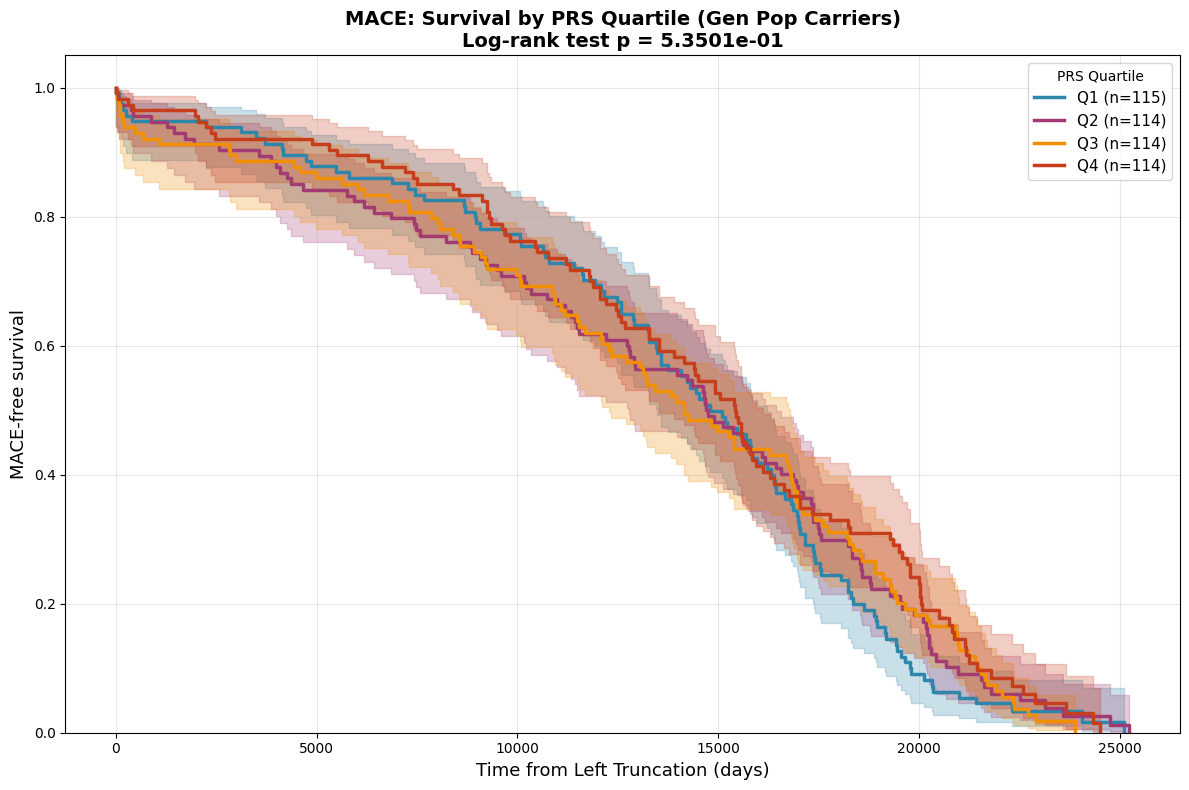


MACE Statistics by PRS Quartile:


,quartile,n,events,event_rate,median_followup_days
0,1,115,110,95.7%,14675.0
1,2,114,107,93.9%,14653.0
2,3,114,110,96.5%,14045.0
3,4,114,103,90.4%,14918.5


Overall log-rank test p-value: 5.3501e-01

2. Cardiac Interventions


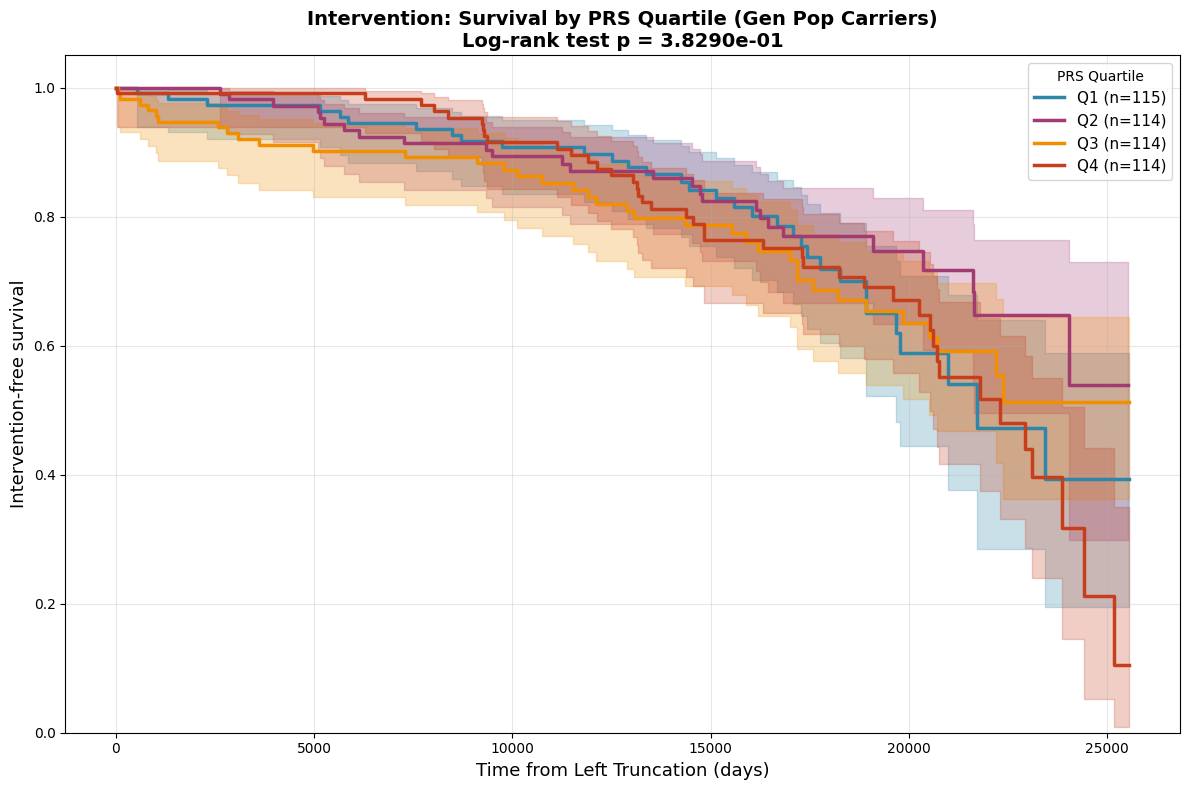


Intervention Statistics by PRS Quartile:


,quartile,n,events,event_rate,median_followup_days
0,1,115,32,27.8%,15661.0
1,2,114,26,22.8%,16522.0
2,3,114,36,31.6%,15907.0
3,4,114,41,36.0%,16539.5


Overall log-rank test p-value: 3.8290e-01

3. All-Cause Mortality


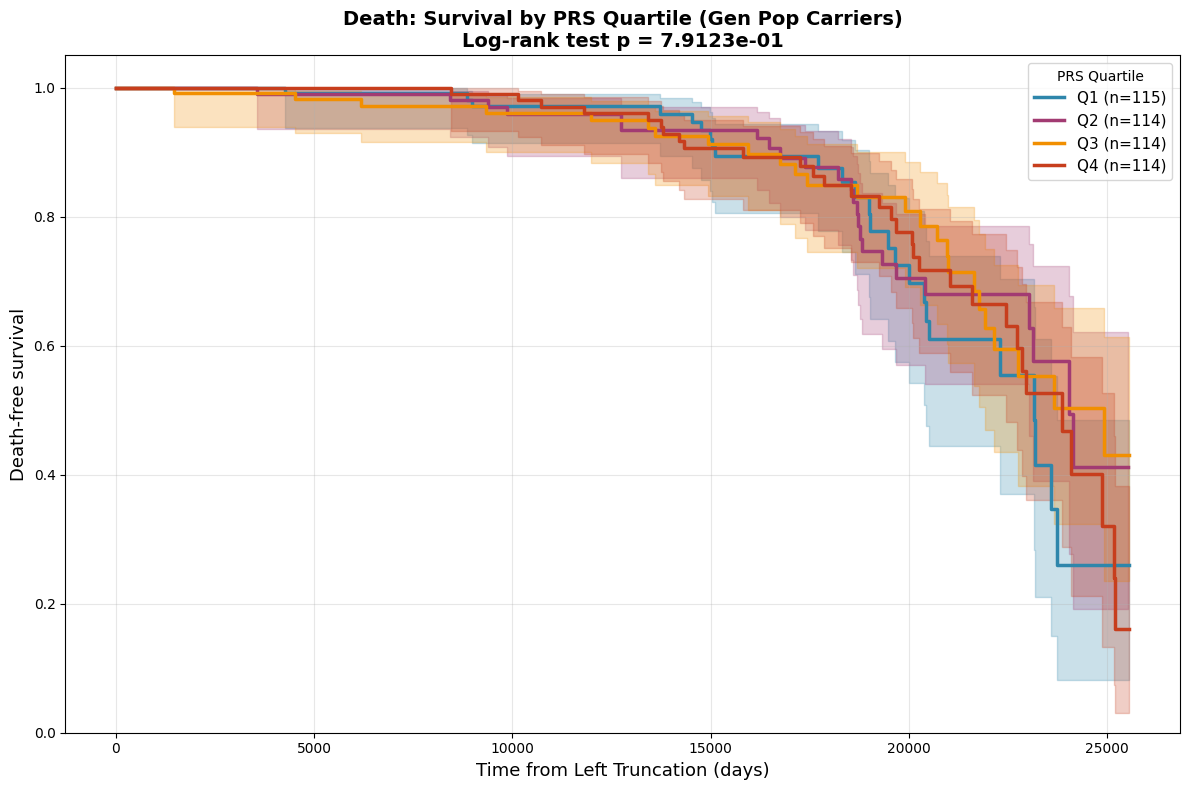


Death Statistics by PRS Quartile:


,quartile,n,events,event_rate,median_followup_days
0,1,115,25,21.7%,16074.0
1,2,114,24,21.1%,17434.5
2,3,114,25,21.9%,16747.5
3,4,114,31,27.2%,17840.5


Overall log-rank test p-value: 7.9123e-01
SUMMARY OF RESULTS


,Outcome,Total_N,Events,Event_Rate,Log_Rank_P,Significant
0,MACE,457,430,94.1%,0.535015,No
1,Intervention,457,135,29.5%,0.382902,No
2,Death,457,105,23.0%,0.791226,No



 Analysis complete for gen_pop_carriers!


In [35]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the gen_pop_carriers survival data
query_load = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
"""
survival_df = client.query(query_load).to_dataframe()

print(f"Loaded {len(survival_df)} gen_pop_carriers patients")

# Clean the data - include all patients (with and without events)
print("\nCleaning survival data...")
print(f"Original rows: {len(survival_df)}")

# Check for NaNs
print("\nChecking for missing values:")
print(survival_df[['mace_time_days', 'mace_event', 
                   'intervention_time_days', 'intervention_event',
                   'death_time_days', 'death_event']].isnull().sum())

# Create separate clean datasets for each outcome
survival_mace_clean = survival_df[
    (survival_df['mace_time_days'].notna()) & 
    (survival_df['mace_time_days'] >= 0) &
    (survival_df['mace_event'].notna()) &
    (survival_df['mace_event'].isin([0, 1]))  # Keep both events (1) and censored (0)
].copy()

survival_intervention_clean = survival_df[
    (survival_df['intervention_time_days'].notna()) & 
    (survival_df['intervention_time_days'] >= 0) &
    (survival_df['intervention_event'].notna()) &
    (survival_df['intervention_event'].isin([0, 1]))
].copy()

survival_death_clean = survival_df[
    (survival_df['death_time_days'].notna()) & 
    (survival_df['death_time_days'] >= 0) &
    (survival_df['death_event'].notna()) &
    (survival_df['death_event'].isin([0, 1]))
].copy()

print(f"\nCleaned rows (INCLUDING censored patients):")
print(f"  MACE: {len(survival_mace_clean)} (removed {len(survival_df) - len(survival_mace_clean)})")
print(f"  Intervention: {len(survival_intervention_clean)} (removed {len(survival_df) - len(survival_intervention_clean)})")
print(f"  Death: {len(survival_death_clean)} (removed {len(survival_df) - len(survival_death_clean)})")

# Check event rates
print(f"\nEvent counts:")
print(f"  MACE: {survival_mace_clean['mace_event'].sum()} events, {(survival_mace_clean['mace_event']==0).sum()} censored")
print(f"  Intervention: {survival_intervention_clean['intervention_event'].sum()} events, {(survival_intervention_clean['intervention_event']==0).sum()} censored")
print(f"  Death: {survival_death_clean['death_event'].sum()} events, {(survival_death_clean['death_event']==0).sum()} censored")

# Function to create KM plots comparing PRS quartiles
def plot_km_curve_by_prs_quartile(df, time_col, event_col, outcome_name):
    """
    Create Kaplan-Meier survival curves comparing PRS quartiles
    (all gen_pop_carriers, stratified by their PRS)
    """
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    
    kmf = KaplanMeierFitter()
    
    colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']  
    
    all_durations = []
    all_events = []
    all_groups = []
    
    quartile_stats = []
    
    for q in range(1, 5):
        # Filter to this quartile
        q_data = df[df['prs_quartile'] == q].copy()
        
        if len(q_data) > 0:
            # Fit KM curve
            kmf.fit(
                durations=q_data[time_col], 
                event_observed=q_data[event_col],
                label=f'Q{q} (n={len(q_data)})'
            )
            kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[q-1], linewidth=2.5)
            
            # Collect data for multivariate log-rank test
            all_durations.extend(q_data[time_col].tolist())
            all_events.extend(q_data[event_col].tolist())
            all_groups.extend([q] * len(q_data))
            
            # Collect stats
            quartile_stats.append({
                'quartile': q,
                'n': len(q_data),
                'events': int(q_data[event_col].sum()),
                'event_rate': f"{100 * q_data[event_col].sum() / len(q_data):.1f}%",
                'median_followup_days': q_data[time_col].median()
            })
    
    # Multivariate log-rank test (tests if ALL quartiles are different)
    test_result = multivariate_logrank_test(
        all_durations, 
        all_groups, 
        all_events
    )
    overall_p = test_result.p_value
    
    # Formatting
    ax.set_xlabel('Time from Left Truncation (days)', fontsize=13)
    ax.set_ylabel(f'{outcome_name}-free survival', fontsize=13)
    ax.set_title(f'{outcome_name}: Survival by PRS Quartile (Gen Pop Carriers)\nLog-rank test p = {overall_p:.4e}', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=11, title='PRS Quartile')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    plt.tight_layout()
    
    return fig, quartile_stats, overall_p


# Create KM curves for each outcome
print("CREATING KAPLAN-MEIER CURVES BY PRS QUARTILE (GEN POP CARRIERS)")

# 1. MACE outcome
print("\n1. MACE - Major Adverse Cardiovascular Events")
fig1, mace_stats, mace_p = plot_km_curve_by_prs_quartile(
    survival_mace_clean, 
    'mace_time_days', 
    'mace_event',
    'MACE'
)
plt.show()

print("\nMACE Statistics by PRS Quartile:")
mace_stats_df = pd.DataFrame(mace_stats)
display(mace_stats_df)
print(f"Overall log-rank test p-value: {mace_p:.4e}")

# 2. Intervention outcome
print("\n2. Cardiac Interventions")
fig2, intervention_stats, intervention_p = plot_km_curve_by_prs_quartile(
    survival_intervention_clean, 
    'intervention_time_days', 
    'intervention_event',
    'Intervention'
)
plt.show()

print("\nIntervention Statistics by PRS Quartile:")
intervention_stats_df = pd.DataFrame(intervention_stats)
display(intervention_stats_df)
print(f"Overall log-rank test p-value: {intervention_p:.4e}")

# 3. Death outcome
print("\n3. All-Cause Mortality")
fig3, death_stats, death_p = plot_km_curve_by_prs_quartile(
    survival_death_clean, 
    'death_time_days', 
    'death_event',
    'Death'
)
plt.show()

print("\nDeath Statistics by PRS Quartile:")
death_stats_df = pd.DataFrame(death_stats)
display(death_stats_df)
print(f"Overall log-rank test p-value: {death_p:.4e}")

# Summary table of all p-values
print("SUMMARY OF RESULTS")

summary_results = pd.DataFrame({
    'Outcome': ['MACE', 'Intervention', 'Death'],
    'Total_N': [len(survival_mace_clean), len(survival_intervention_clean), len(survival_death_clean)],
    'Events': [
        survival_mace_clean['mace_event'].sum(),
        survival_intervention_clean['intervention_event'].sum(),
        survival_death_clean['death_event'].sum()
    ],
    'Event_Rate': [
        f"{100 * survival_mace_clean['mace_event'].sum() / len(survival_mace_clean):.1f}%",
        f"{100 * survival_intervention_clean['intervention_event'].sum() / len(survival_intervention_clean):.1f}%",
        f"{100 * survival_death_clean['death_event'].sum() / len(survival_death_clean):.1f}%"
    ],
    'Log_Rank_P': [mace_p, intervention_p, death_p],
    'Significant': [
        ' YES' if mace_p < 0.05 else 'No',
        ' YES' if intervention_p < 0.05 else 'No',
        ' YES' if death_p < 0.05 else 'No'
    ]
})

display(summary_results)

In [1]:
SCRATCH_DATASET_ID_HCM = "hcm_analysis_scratch_updated"

In [41]:
print("Creating age-based survival tables...")

# HCM CARRIERS - Age-based survival (join with model1_hcm_carriers for birth_datetime)
query_hcm_age = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based` AS

SELECT 
  s.person_id,
  s.is_carrier,
  s.prs,
  s.prs_quartile,
  DATE(m.birth_datetime) as birth_date,
  s.first_hcm_date as entry_date,
  s.last_visit_date,
  
  -- Calculate age at entry (HCM diagnosis)
  DATE_DIFF(s.first_hcm_date, DATE(m.birth_datetime), YEAR) as age_at_entry,
  
  -- MACE outcome
  s.mace_event,
  s.mace_date,
  s.mace_time_days,
  CASE 
    WHEN s.mace_date IS NOT NULL 
    THEN DATE_DIFF(s.mace_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_mace,
  CASE 
    WHEN s.mace_date IS NOT NULL 
    THEN DATE_DIFF(s.mace_date, s.first_hcm_date, YEAR) 
    ELSE DATE_DIFF(COALESCE(s.last_visit_date, s.death_date), s.first_hcm_date, YEAR)
  END as mace_followup_years,
  
  -- Intervention outcome
  s.intervention_event,
  s.intervention_date,
  s.intervention_time_days,
  CASE 
    WHEN s.intervention_date IS NOT NULL 
    THEN DATE_DIFF(s.intervention_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CASE 
    WHEN s.intervention_date IS NOT NULL 
    THEN DATE_DIFF(s.intervention_date, s.first_hcm_date, YEAR)
    ELSE DATE_DIFF(COALESCE(s.last_visit_date, s.death_date), s.first_hcm_date, YEAR)
  END as intervention_followup_years,
  
  -- Death outcome
  s.death_event,
  s.death_date,
  s.death_time_days,
  CASE 
    WHEN s.death_date IS NOT NULL 
    THEN DATE_DIFF(s.death_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_death,
  CASE 
    WHEN s.death_date IS NOT NULL 
    THEN DATE_DIFF(s.death_date, s.first_hcm_date, YEAR)
    ELSE DATE_DIFF(s.last_visit_date, s.first_hcm_date, YEAR)
  END as death_followup_years,
  
  'HCM' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_survival_data` s
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.model1_hcm_carriers` m
  ON s.person_id = m.person_id
WHERE s.is_carrier = TRUE  -- Only carriers
  AND m.birth_datetime IS NOT NULL
  AND DATE_DIFF(s.first_hcm_date, DATE(m.birth_datetime), YEAR) >= 20  -- Age 20+ at HCM diagnosis
"""

job = client.query(query_hcm_age)
job.result()
print(" Created hcm_carriers_survival_age_based")

# GEN POP CARRIERS - Age-based survival
query_genpop_age = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based` AS

SELECT 
  person_id,
  is_carrier,
  prs,
  prs_quartile,
  birth_date,
  left_truncation_date as entry_date,
  last_visit_date,
  
  -- Calculate age at entry (left truncation)
  DATE_DIFF(left_truncation_date, birth_date, YEAR) as age_at_entry,
  
  -- MACE outcome
  mace_event,
  mace_date,
  mace_time_days,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(mace_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_mace,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(mace_date, left_truncation_date, YEAR)
    ELSE DATE_DIFF(COALESCE(last_visit_date, death_date), left_truncation_date, YEAR)
  END as mace_followup_years,
  
  -- Intervention outcome
  intervention_event,
  intervention_date,
  intervention_time_days,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(intervention_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(intervention_date, left_truncation_date, YEAR)
    ELSE DATE_DIFF(COALESCE(last_visit_date, death_date), left_truncation_date, YEAR)
  END as intervention_followup_years,
  
  -- Death outcome
  death_event,
  death_date,
  death_time_days,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(death_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_death,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(death_date, left_truncation_date, YEAR)
    ELSE DATE_DIFF(last_visit_date, left_truncation_date, YEAR)
  END as death_followup_years,
  
  'GenPop' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
WHERE birth_date IS NOT NULL
"""

job = client.query(query_genpop_age)
job.result()
print(" Created gen_pop_carriers_survival_age_based")

# Verify the age distributions
query_verify = f"""
SELECT 
  cohort,
  COUNT(*) as n,
  MIN(age_at_entry) as min_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(1)] as q1_entry_age,
  APPROX_QUANTILES(age_at_entry, 2)[OFFSET(1)] as median_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(3)] as q3_entry_age,
  MAX(age_at_entry) as max_entry_age,
  AVG(age_at_entry) as mean_entry_age,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death
FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
GROUP BY cohort
ORDER BY cohort
"""

verify_df = client.query(query_verify).to_dataframe()
print("\n Age Distribution at Entry by Cohort:")
display(verify_df)

# Show sample data
query_sample = f"""
SELECT 
  cohort,
  person_id,
  age_at_entry,
  entry_date,
  mace_event,
  age_at_mace,
  mace_followup_years,
  intervention_event,
  age_at_intervention,
  intervention_followup_years
FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
WHERE mace_event = 1 OR intervention_event = 1
ORDER BY cohort, person_id
LIMIT 10
"""

sample_df = client.query(query_sample).to_dataframe()
print("\n Sample rows with events:")
display(sample_df)

Creating age-based survival tables...
 Created hcm_carriers_survival_age_based
 Created gen_pop_carriers_survival_age_based

 Age Distribution at Entry by Cohort:


,cohort,n,min_entry_age,q1_entry_age,median_entry_age,q3_entry_age,max_entry_age,mean_entry_age,n_mace,n_intervention,n_death
0,GenPop,457,20,20,20,20,20,20.000000,430,135,105
1,HCM,39,20,35,51,59,82,48.179487,32,22,5



 Sample rows with events:


,cohort,person_id,age_at_entry,entry_date,mace_event,age_at_mace,mace_followup_years,intervention_event,age_at_intervention,intervention_followup_years
0,GenPop,R200276866,20,1970-03-20,1,61,41,0,<NA>,41
1,GenPop,R200490840,20,1982-07-17,1,62,42,0,<NA>,43
2,GenPop,R200730951,20,1974-12-07,1,45,25,1,45,25
3,GenPop,R200847967,20,1999-06-18,1,32,12,0,<NA>,15
4,GenPop,R200895831,20,1994-02-22,1,49,29,0,<NA>,31
5,GenPop,R201326124,20,1974-08-22,1,61,41,0,<NA>,41
6,GenPop,R202050839,20,2024-06-28,1,20,0,0,<NA>,1
7,GenPop,R202875973,20,1965-10-03,1,57,37,1,61,41
8,GenPop,R203277003,20,1965-09-30,1,66,46,0,<NA>,51
9,GenPop,R203648768,20,2007-09-15,1,20,0,1,20,0


Creating Kaplan-Meier curves: HCM Carriers vs GenPop Carriers by PRS Quartile
Reformatting as separate 2x2 grids for each outcome
MACE - KM Curves by PRS Quartile

Quartile 1:
  HCM Carriers: n=11, events=9
  GenPop Carriers: n=115, events=110
  Log-rank test p-value: 0.0000

Quartile 2:
  HCM Carriers: n=9, events=8
  GenPop Carriers: n=114, events=107
  Log-rank test p-value: 0.0000

Quartile 3:
  HCM Carriers: n=12, events=10
  GenPop Carriers: n=114, events=110
  Log-rank test p-value: 0.0000

Quartile 4:
  HCM Carriers: n=7, events=5
  GenPop Carriers: n=114, events=103
  Log-rank test p-value: 0.0000

 Saved: km_curves_mace_hcm_vs_genpop_by_prs.png


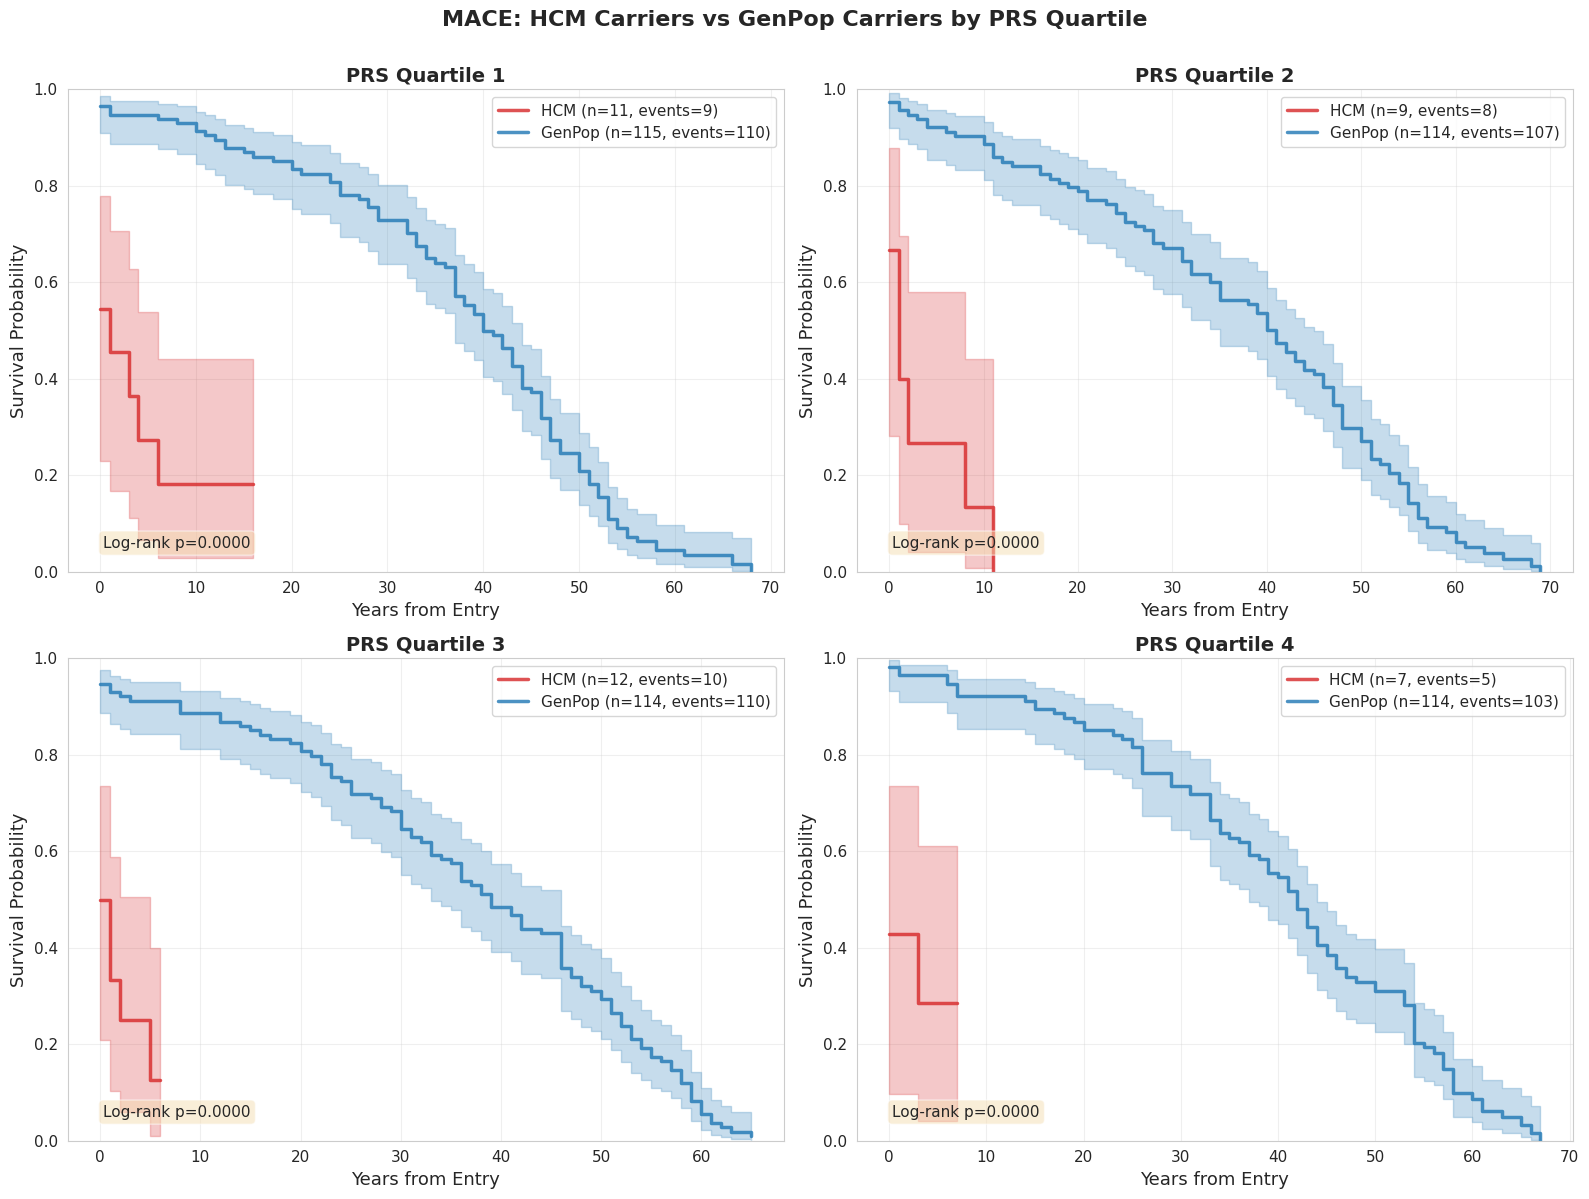

INTERVENTION - KM Curves by PRS Quartile

Quartile 1:
  HCM Carriers: n=11, events=4
  GenPop Carriers: n=115, events=32
  Log-rank test p-value: 0.0000

Quartile 2:
  HCM Carriers: n=9, events=7
  GenPop Carriers: n=114, events=26
  Log-rank test p-value: 0.0000

Quartile 3:
  HCM Carriers: n=12, events=8
  GenPop Carriers: n=114, events=36
  Log-rank test p-value: 0.0000

Quartile 4:
  HCM Carriers: n=7, events=3
  GenPop Carriers: n=114, events=41
  Log-rank test p-value: 0.0000

 Saved: km_curves_intervention_hcm_vs_genpop_by_prs.png


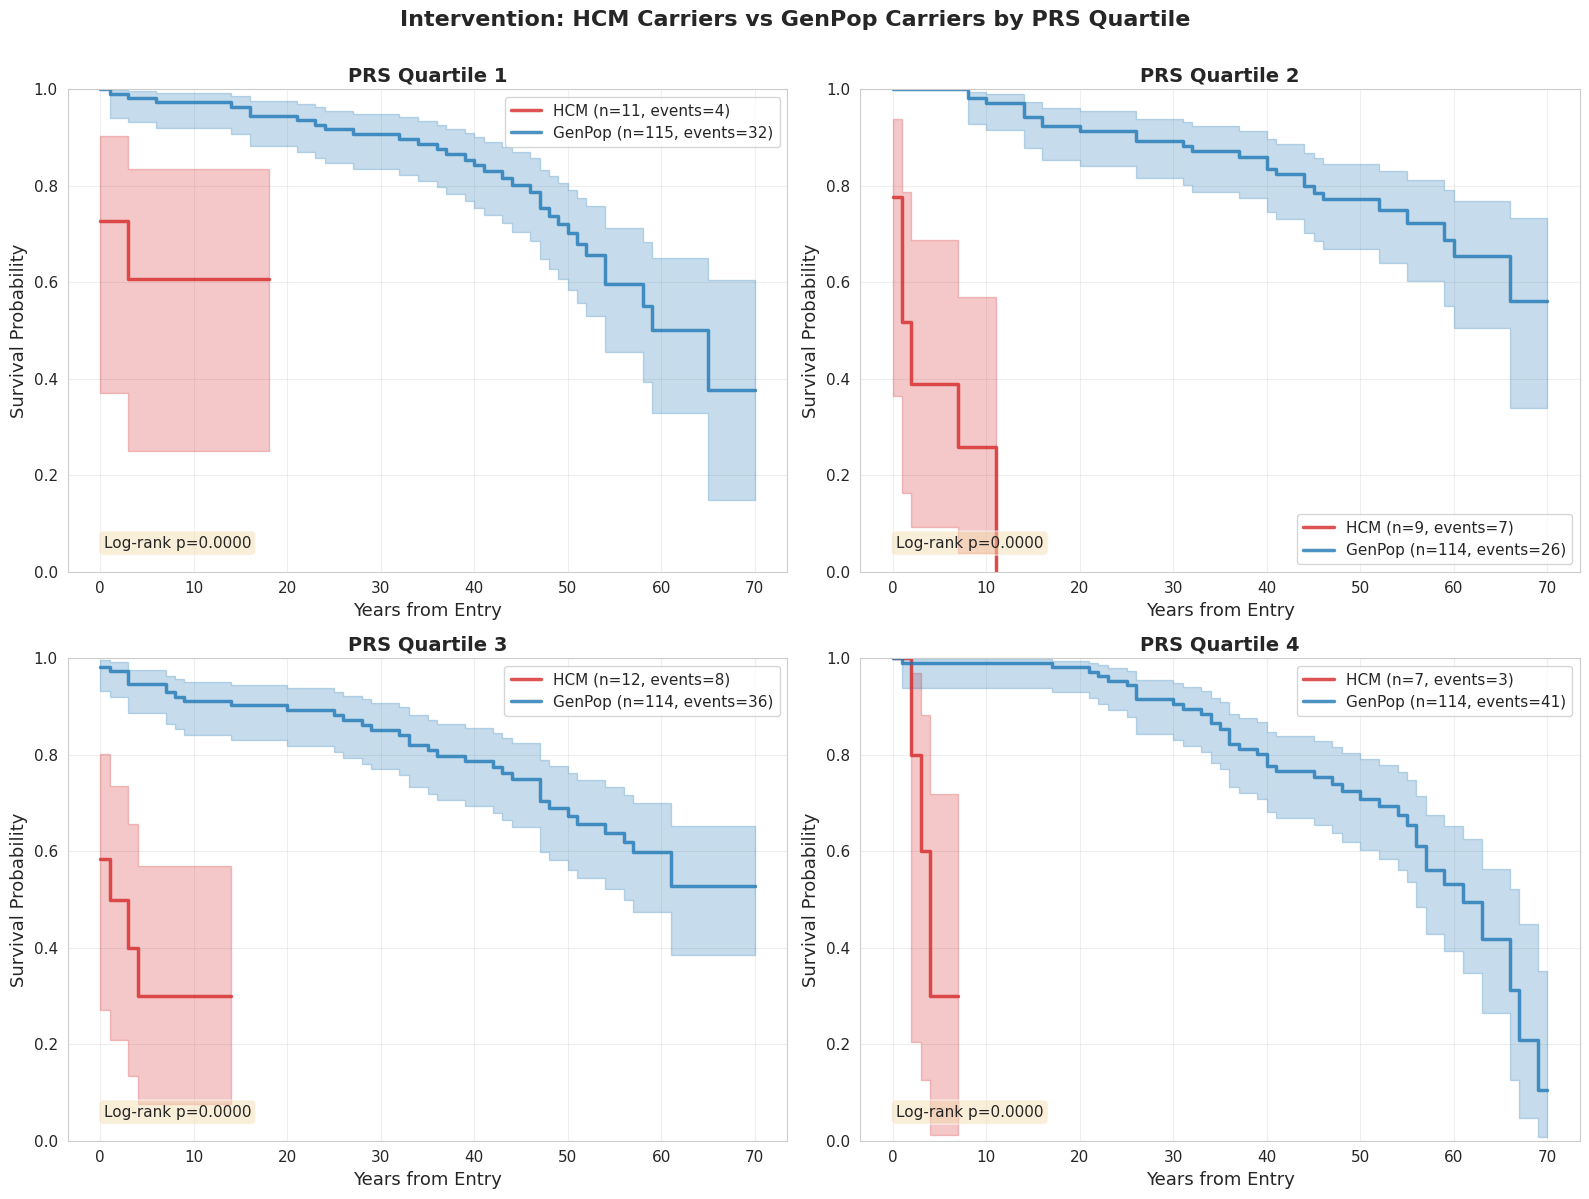

DEATH - KM Curves by PRS Quartile

Quartile 1:
  HCM Carriers: n=11, events=2
  GenPop Carriers: n=115, events=25
  Log-rank test p-value: 0.0000

Quartile 2:
  HCM Carriers: n=9, events=1
  GenPop Carriers: n=114, events=24
  Log-rank test p-value: 0.0000

Quartile 3:
  HCM Carriers: n=12, events=1
  GenPop Carriers: n=114, events=25
  Log-rank test p-value: 0.0203

Quartile 4:
  HCM Carriers: n=7, events=1
  GenPop Carriers: n=114, events=31
  Log-rank test p-value: 0.0000

 Saved: km_curves_death_hcm_vs_genpop_by_prs.png


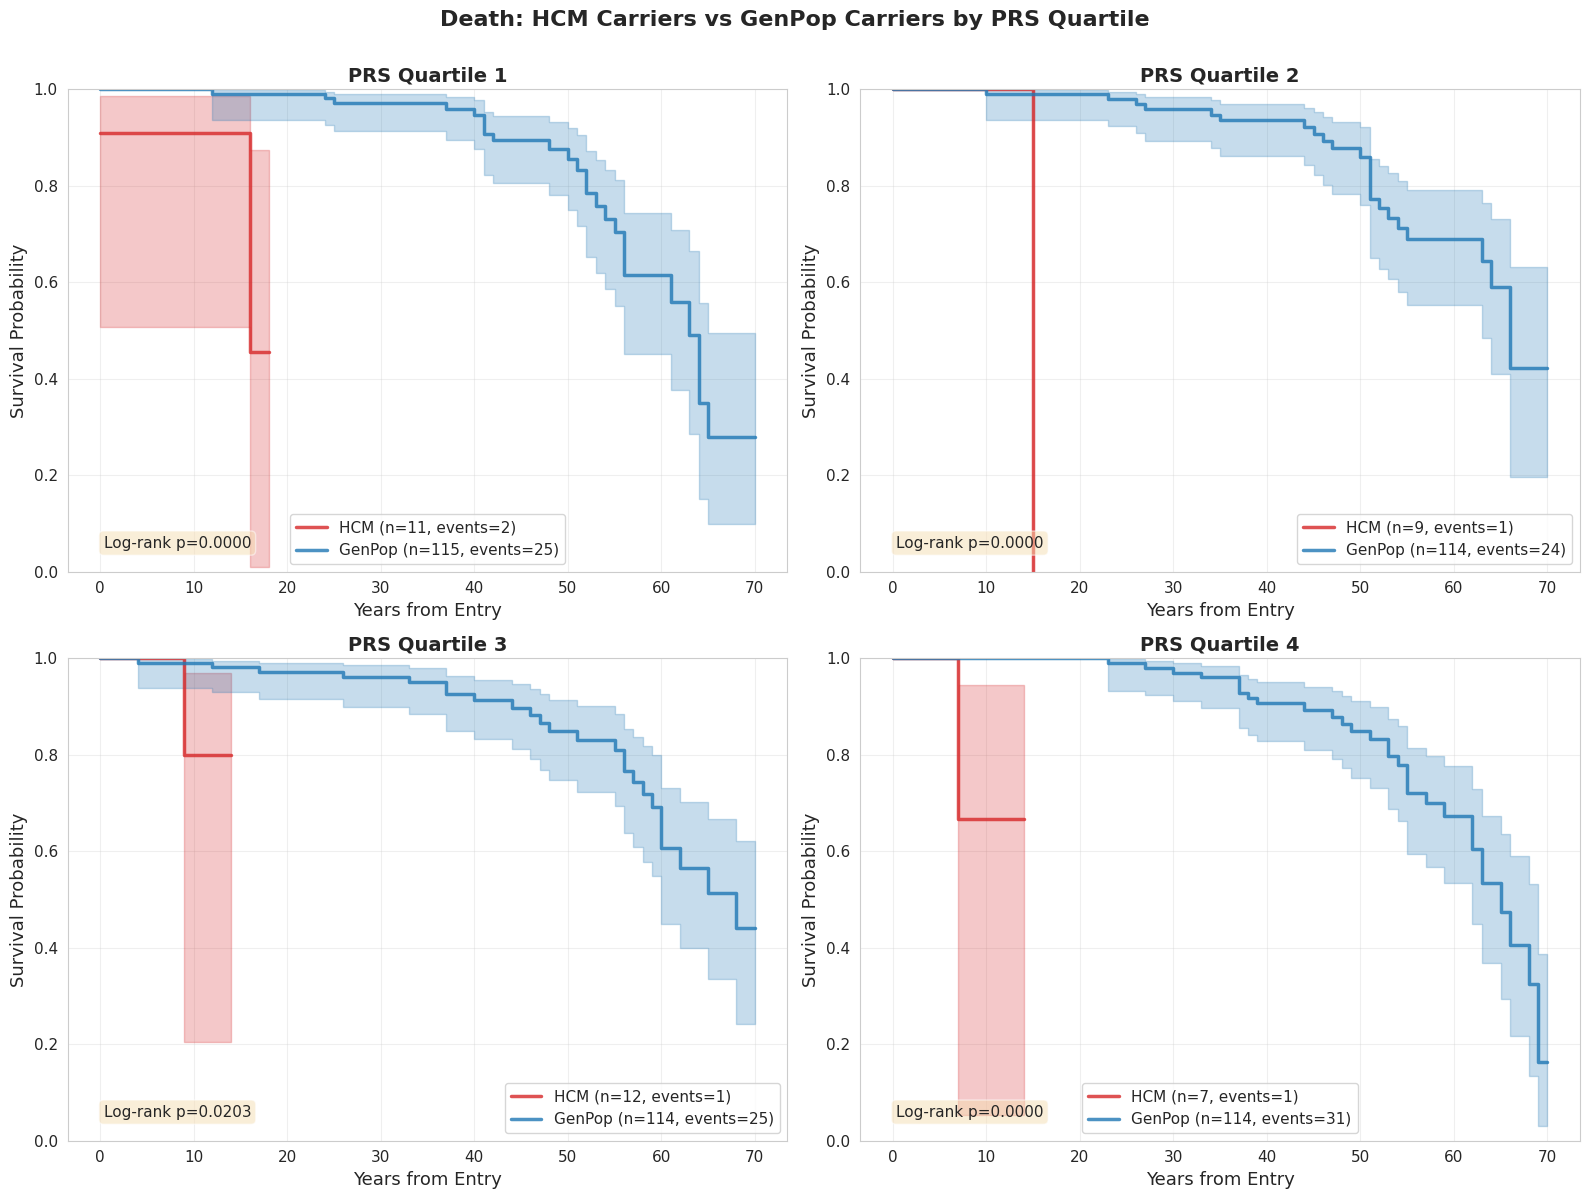

SUMMARY TABLE: HCM Carriers vs GenPop Carriers by PRS Quartile


,Outcome,PRS_Quartile,Cohort,N,Events,Person_Years,Median_Followup_Years,Event_Rate_per_100PY
0,MACE,Q1,HCM,11,9,41,1.0,21.95
1,MACE,Q1,GenPop,115,110,4259,40.0,2.58
2,MACE,Q2,HCM,9,8,23,1.0,34.78
3,MACE,Q2,GenPop,114,107,4109,40.0,2.60
4,MACE,Q3,HCM,12,10,17,0.5,58.82
5,MACE,Q3,GenPop,114,110,4148,38.5,2.65
6,MACE,Q4,HCM,7,5,13,0.0,38.46
7,MACE,Q4,GenPop,114,103,4409,41.0,2.34
8,Intervention,Q1,HCM,11,4,65,3.0,6.15
9,Intervention,Q1,GenPop,115,32,4695,43.0,0.68


In [44]:
print("Creating Kaplan-Meier curves: HCM Carriers vs GenPop Carriers by PRS Quartile")

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

colors = {'HCM': '#d62728', 'GenPop': '#1f77b4'}  # Red for HCM, Blue for GenPop

outcomes = [
    ('MACE', df_mace, 'mace_event', 'mace_followup_years'),
    ('Intervention', df_intervention, 'intervention_event', 'intervention_followup_years'),
    ('Death', df_death, 'death_event', 'death_followup_years')
]

# Create separate 2x2 figure for each outcome

for outcome_name, df, event_col, time_col in outcomes:
    
    print(f"{outcome_name.upper()} - KM Curves by PRS Quartile")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, quartile in enumerate([1, 2, 3, 4]):
        ax = axes[idx]
        
        # Filter to this quartile
        df_q = df[df['prs_quartile'] == quartile].copy()
        
        # Get counts
        n_hcm = len(df_q[df_q['cohort'] == 'HCM'])
        n_genpop = len(df_q[df_q['cohort'] == 'GenPop'])
        events_hcm = df_q[df_q['cohort'] == 'HCM'][event_col].sum()
        events_genpop = df_q[df_q['cohort'] == 'GenPop'][event_col].sum()
        
        print(f"\nQuartile {quartile}:")
        print(f"  HCM Carriers: n={n_hcm}, events={events_hcm}")
        print(f"  GenPop Carriers: n={n_genpop}, events={events_genpop}")
        
        # Fit KM curves for each cohort
        kmf = KaplanMeierFitter()
        
        for cohort, color in colors.items():
            df_cohort = df_q[df_q['cohort'] == cohort]
            
            if len(df_cohort) > 0:
                kmf.fit(
                    durations=df_cohort[time_col],
                    event_observed=df_cohort[event_col],
                    label=f"{cohort} (n={len(df_cohort)}, events={df_cohort[event_col].sum()})"
                )
                
                kmf.plot_survival_function(ax=ax, ci_show=True, color=color, linewidth=2.5, alpha=0.8)
        
        # Log-rank test
        if n_hcm > 0 and n_genpop > 0 and (events_hcm > 0 or events_genpop > 0):
            try:
                results = multivariate_logrank_test(
                    df_q[time_col],
                    df_q['cohort'],
                    df_q[event_col]
                )
                p_value = results.p_value
                
                ax.text(0.05, 0.05, f'Log-rank p={p_value:.4f}',
                       transform=ax.transAxes,
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                       fontsize=11)
                
                print(f"  Log-rank test p-value: {p_value:.4f}")
            except:
                print(f"  Log-rank test: Could not compute")
        
        # Formatting
        ax.set_xlabel('Years from Entry', fontsize=13)
        ax.set_ylabel('Survival Probability', fontsize=13)
        ax.set_title(f'PRS Quartile {quartile}', fontsize=14, fontweight='bold')
        ax.legend(loc='best', fontsize=11)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1])
        ax.tick_params(labelsize=11)
    
    # Add overall title
    fig.suptitle(f'{outcome_name}: HCM Carriers vs GenPop Carriers by PRS Quartile', 
                 fontsize=16, fontweight='bold', y=0.995)
    
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    
    # Save with outcome-specific filename
    filename = f'km_curves_{outcome_name.lower()}_hcm_vs_genpop_by_prs.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\n Saved: {filename}")
    plt.show()

# Create summary statistics table

summary_data = []

for outcome_name, df, event_col, time_col in outcomes:
    for quartile in [1, 2, 3, 4]:
        df_q = df[df['prs_quartile'] == quartile]
        
        for cohort in ['HCM', 'GenPop']:
            df_cohort = df_q[df_q['cohort'] == cohort]
            
            if len(df_cohort) > 0:
                n = len(df_cohort)
                events = df_cohort[event_col].sum()
                person_years = df_cohort[time_col].sum()
                median_followup = df_cohort[time_col].median()
                
                # Calculate event rate per 100 person-years
                rate_per_100py = (events / person_years * 100) if person_years > 0 else 0
                
                summary_data.append({
                    'Outcome': outcome_name,
                    'PRS_Quartile': f'Q{quartile}',
                    'Cohort': cohort,
                    'N': n,
                    'Events': int(events),
                    'Person_Years': round(person_years, 1),
                    'Median_Followup_Years': round(median_followup, 2),
                    'Event_Rate_per_100PY': round(rate_per_100py, 2)
                })

summary_df = pd.DataFrame(summary_data)

print("SUMMARY TABLE: HCM Carriers vs GenPop Carriers by PRS Quartile")
display(summary_df)

In [4]:
print("Creating age-based survival tables (ALL CARRIERS START AT AGE 20)...")
PROJECT_ID = "nb-tre-dev-2-483522"

# HCM CARRIERS 
query_hcm_age = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based` AS

SELECT 
  s.person_id,
  s.is_carrier,
  s.prs,
  s.prs_quartile,
  DATE(m.birth_datetime) as birth_date,
  
  -- Entry date is LATER of: age 20 or HCM diagnosis
  GREATEST(
    DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR),
    s.first_hcm_date
  ) as entry_date,
  
  s.first_hcm_date,
  s.last_visit_date,
  
  -- Age at entry (should be 20+ for all)
  DATE_DIFF(
    GREATEST(
      DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR),
      s.first_hcm_date
    ),
    DATE(m.birth_datetime), 
    YEAR
  ) as age_at_entry,
  
  -- MACE outcome
  s.mace_event,
  s.mace_date,
  s.mace_time_days,
  CASE 
    WHEN s.mace_date IS NOT NULL 
    THEN DATE_DIFF(s.mace_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_mace,
  CASE 
    WHEN s.mace_date IS NOT NULL 
    THEN DATE_DIFF(
      s.mace_date, 
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(s.last_visit_date, s.death_date),
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
  END as mace_followup_years,
  
  -- Intervention outcome
  s.intervention_event,
  s.intervention_date,
  s.intervention_time_days,
  CASE 
    WHEN s.intervention_date IS NOT NULL 
    THEN DATE_DIFF(s.intervention_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CASE 
    WHEN s.intervention_date IS NOT NULL 
    THEN DATE_DIFF(
      s.intervention_date,
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(s.last_visit_date, s.death_date),
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
  END as intervention_followup_years,
  
  -- Death outcome
  s.death_event,
  s.death_date,
  s.death_time_days,
  CASE 
    WHEN s.death_date IS NOT NULL 
    THEN DATE_DIFF(s.death_date, DATE(m.birth_datetime), YEAR)
    ELSE NULL 
  END as age_at_death,
  CASE 
    WHEN s.death_date IS NOT NULL 
    THEN DATE_DIFF(
      s.death_date,
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
    ELSE DATE_DIFF(
      s.last_visit_date,
      GREATEST(DATE_ADD(DATE(m.birth_datetime), INTERVAL 20 YEAR), s.first_hcm_date),
      YEAR
    )
  END as death_followup_years,
  
  'HCM' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_survival_data` s
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.model1_hcm_carriers` m
  ON s.person_id = m.person_id
WHERE s.is_carrier = TRUE  -- Only carriers
  AND m.birth_datetime IS NOT NULL
  -- Remove the age filter since we're handling it with GREATEST()
"""

job = client.query(query_hcm_age)
job.result()
print(" Created hcm_carriers_survival_age_based")

# GEN POP CARRIERS - Age-based survival starting at age 20
query_genpop_age = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based` AS

SELECT 
  person_id,
  is_carrier,
  prs,
  prs_quartile,
  birth_date,
  
  -- Entry date is LATER of: age 20 or left truncation
  GREATEST(
    DATE_ADD(birth_date, INTERVAL 20 YEAR),
    left_truncation_date
  ) as entry_date,
  
  left_truncation_date,
  last_visit_date,
  
  -- Age at entry (should be 20+ for all)
  DATE_DIFF(
    GREATEST(
      DATE_ADD(birth_date, INTERVAL 20 YEAR),
      left_truncation_date
    ),
    birth_date,
    YEAR
  ) as age_at_entry,
  
  -- MACE outcome
  mace_event,
  mace_date,
  mace_time_days,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(mace_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_mace,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(
      mace_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(last_visit_date, death_date),
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as mace_followup_years,
  
  -- Intervention outcome
  intervention_event,
  intervention_date,
  intervention_time_days,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(intervention_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(
      intervention_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(last_visit_date, death_date),
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as intervention_followup_years,
  
  -- Death outcome
  death_event,
  death_date,
  death_time_days,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(death_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_death,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(
      death_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      last_visit_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as death_followup_years,
  
  'GenPop' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
WHERE birth_date IS NOT NULL
"""

job = client.query(query_genpop_age)
job.result()
print(" Created gen_pop_carriers_survival_age_based")

# Verify the age distributions
query_verify = f"""
SELECT 
  cohort,
  COUNT(*) as n,
  MIN(age_at_entry) as min_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(1)] as q1_entry_age,
  APPROX_QUANTILES(age_at_entry, 2)[OFFSET(1)] as median_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(3)] as q3_entry_age,
  MAX(age_at_entry) as max_entry_age,
  AVG(age_at_entry) as mean_entry_age,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death
FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
GROUP BY cohort
ORDER BY cohort
"""

verify_df = client.query(query_verify).to_dataframe()
print("\n Age Distribution at Entry by Cohort:")
display(verify_df)

# Show sample data
query_sample = f"""
SELECT 
  cohort,
  person_id,
  age_at_entry,
  entry_date,
  mace_event,
  age_at_mace,
  mace_followup_years,
  intervention_event,
  age_at_intervention,
  intervention_followup_years
FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
WHERE mace_event = 1 OR intervention_event = 1
ORDER BY cohort, person_id
LIMIT 10
"""

sample_df = client.query(query_sample).to_dataframe()
print("\n Sample rows with events:")
display(sample_df)


Creating age-based survival tables (ALL CARRIERS START AT AGE 20)...
 Created hcm_carriers_survival_age_based
 Created gen_pop_carriers_survival_age_based

 Age Distribution at Entry by Cohort:


,cohort,n,min_entry_age,q1_entry_age,median_entry_age,q3_entry_age,max_entry_age,mean_entry_age,n_mace,n_intervention,n_death
0,GenPop,457,20,20,20,20,20,20.000000,430,135,105
1,HCM,46,20,25,48,57,82,43.891304,34,27,5



 Sample rows with events:


,cohort,person_id,age_at_entry,entry_date,mace_event,age_at_mace,mace_followup_years,intervention_event,age_at_intervention,intervention_followup_years
0,GenPop,R200276866,20,1970-03-20,1,61,41,0,<NA>,41
1,GenPop,R200490840,20,1982-07-17,1,62,42,0,<NA>,43
2,GenPop,R200730951,20,1974-12-07,1,45,25,1,45,25
3,GenPop,R200847967,20,1999-06-18,1,32,12,0,<NA>,15
4,GenPop,R200895831,20,1994-02-22,1,49,29,0,<NA>,31
5,GenPop,R201326124,20,1974-08-22,1,61,41,0,<NA>,41
6,GenPop,R202050839,20,2024-06-28,1,20,0,0,<NA>,1
7,GenPop,R202875973,20,1965-10-03,1,57,37,1,61,41
8,GenPop,R203277003,20,1965-09-30,1,66,46,0,<NA>,51
9,GenPop,R203648768,20,2007-09-15,1,20,0,1,20,0


Creating composite outcome and running survival analysis by PRS quartile...
 Created composite outcome table

 Composite Outcome Summary by Cohort and PRS Quartile:


,cohort,prs_quartile,n,n_composite,pct_composite,n_mace_first,n_intervention_first,n_death_first,mean_followup_years
0,GenPop,1,115,115,100.0,113,2,0,37.0
1,GenPop,2,114,114,100.0,112,2,0,35.9
2,GenPop,3,114,114,100.0,112,2,0,36.1
3,GenPop,4,114,114,100.0,113,1,0,38.7
4,HCM,1,11,10,90.9,10,0,0,3.7
5,HCM,2,9,8,88.9,7,1,0,2.4
6,HCM,3,15,11,73.3,10,1,0,1.2
7,HCM,4,11,9,81.8,7,2,0,1.0



 Loaded 499 carriers for analysis
   - HCM carriers: 42
   - GenPop carriers: 457
KAPLAN-MEIER ANALYSIS: Composite Outcome by PRS Quartile (All Carriers)

PRS Quartile 1:
  N = 126
  Events = 125 (99.2%)
  Median follow-up = 38.0 years
  Median survival time = 38.0 years

PRS Quartile 2:
  N = 123
  Events = 122 (99.2%)
  Median follow-up = 38.0 years
  Median survival time = 39.0 years

PRS Quartile 3:
  N = 128
  Events = 124 (96.9%)
  Median follow-up = 35.5 years
  Median survival time = 36.0 years

PRS Quartile 4:
  N = 122
  Events = 120 (98.4%)
  Median follow-up = 39.0 years
  Median survival time = 39.0 years
LOG-RANK TESTS (Pairwise Comparisons):
Q1 vs Q2: p = 0.4435 ns
Q1 vs Q3: p = 0.5158 ns
Q1 vs Q4: p = 0.1516 ns
Q2 vs Q3: p = 0.9890 ns
Q2 vs Q4: p = 0.4948 ns
Q3 vs Q4: p = 0.4121 ns


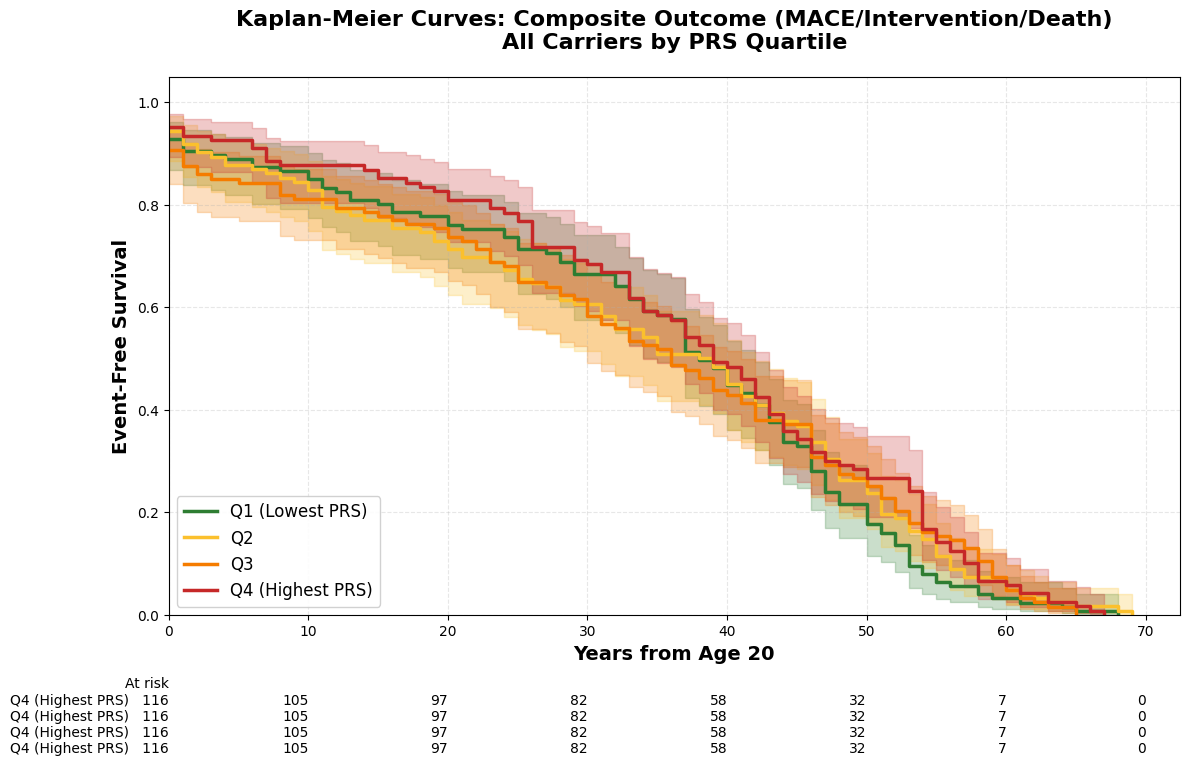


 Plot saved as 'km_curve_composite_carriers_by_prs_quartile.png'
EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS:

5-Year Event-Free Survival:
  Q1: 88.9% (95% CI: 82.0% - 93.3%)
  Q2: 87.7% (95% CI: 80.5% - 92.4%)
  Q3: 84.3% (95% CI: 76.7% - 89.6%)
  Q4: 92.6% (95% CI: 86.3% - 96.1%)

10-Year Event-Free Survival:
  Q1: 84.9% (95% CI: 77.4% - 90.1%)
  Q2: 82.8% (95% CI: 74.9% - 88.4%)
  Q3: 81.1% (95% CI: 73.1% - 86.9%)
  Q4: 87.7% (95% CI: 80.4% - 92.4%)

15-Year Event-Free Survival:
  Q1: 80.1% (95% CI: 72.0% - 86.1%)
  Q2: 77.1% (95% CI: 68.6% - 83.6%)
  Q3: 77.8% (95% CI: 69.5% - 84.1%)
  Q4: 85.1% (95% CI: 77.5% - 90.4%)

20-Year Event-Free Survival:
  Q1: 76.1% (95% CI: 67.7% - 82.7%)
  Q2: 71.3% (95% CI: 62.4% - 78.5%)
  Q3: 73.8% (95% CI: 65.1% - 80.6%)
  Q4: 81.0% (95% CI: 72.8% - 86.9%)


In [5]:
print("Creating composite outcome and running survival analysis by PRS quartile...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome` AS

SELECT 
  *,
  -- Composite outcome: MACE OR Intervention OR Death
  CASE 
    WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 
    THEN 1 
    ELSE 0 
  END as composite_event,
  
  -- Time to composite (earliest of the three)
  LEAST(
    COALESCE(mace_followup_years, 999),
    COALESCE(intervention_followup_years, 999),
    COALESCE(death_followup_years, 999)
  ) as composite_followup_years,
  
  -- Which event happened first (for reference)
  CASE 
    WHEN mace_event = 0 AND intervention_event = 0 AND death_event = 0 THEN 'None'
    WHEN mace_followup_years <= COALESCE(intervention_followup_years, 999) 
         AND mace_followup_years <= COALESCE(death_followup_years, 999) THEN 'MACE'
    WHEN intervention_followup_years <= COALESCE(mace_followup_years, 999)
         AND intervention_followup_years <= COALESCE(death_followup_years, 999) THEN 'Intervention'
    ELSE 'Death'
  END as first_event_type

FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
"""

job = client.query(query_composite)
job.result()
print(" Created composite outcome table")

# Verify composite outcomes
query_verify_composite = f"""
SELECT 
  cohort,
  prs_quartile,
  COUNT(*) as n,
  SUM(composite_event) as n_composite,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as pct_composite,
  SUM(CASE WHEN first_event_type = 'MACE' THEN 1 ELSE 0 END) as n_mace_first,
  SUM(CASE WHEN first_event_type = 'Intervention' THEN 1 ELSE 0 END) as n_intervention_first,
  SUM(CASE WHEN first_event_type = 'Death' THEN 1 ELSE 0 END) as n_death_first,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort, prs_quartile
ORDER BY cohort, prs_quartile
"""

verify_composite_df = client.query(query_verify_composite).to_dataframe()
print("\n Composite Outcome Summary by Cohort and PRS Quartile:")
display(verify_composite_df)

# Pull data for analysis
query_data = f"""
SELECT 
  person_id,
  cohort,
  prs_quartile,
  age_at_entry,
  composite_event,
  composite_followup_years,
  first_event_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE composite_followup_years >= 0  -- Valid follow-up
"""

df_composite = client.query(query_data).to_dataframe()
print(f"\n Loaded {len(df_composite):,} carriers for analysis")
print(f"   - HCM carriers: {len(df_composite[df_composite['cohort']=='HCM']):,}")
print(f"   - GenPop carriers: {len(df_composite[df_composite['cohort']=='GenPop']):,}")

# Fit Kaplan-Meier curves by PRS quartile (combining both cohorts)
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("KAPLAN-MEIER ANALYSIS: Composite Outcome by PRS Quartile (All Carriers)")

kmf = KaplanMeierFitter()
quartiles = sorted(df_composite['prs_quartile'].unique())

# Fit KM for each quartile
km_results = {}
for q in quartiles:
    df_q = df_composite[df_composite['prs_quartile'] == q]
    kmf.fit(
        durations=df_q['composite_followup_years'],
        event_observed=df_q['composite_event'],
        label=f'Q{q}'
    )
    km_results[q] = kmf.survival_function_.copy()
    
    # Print summary stats
    print(f"\nPRS Quartile {q}:")
    print(f"  N = {len(df_q):,}")
    print(f"  Events = {df_q['composite_event'].sum():,} ({100*df_q['composite_event'].mean():.1f}%)")
    print(f"  Median follow-up = {df_q['composite_followup_years'].median():.1f} years")
    if kmf.median_survival_time_ < 999:
        print(f"  Median survival time = {kmf.median_survival_time_:.1f} years")
    else:
        print(f"  Median survival time = Not reached")

# Log-rank tests
print("LOG-RANK TESTS (Pairwise Comparisons):")

from itertools import combinations
for q1, q2 in combinations(quartiles, 2):
    df_q1 = df_composite[df_composite['prs_quartile'] == q1]
    df_q2 = df_composite[df_composite['prs_quartile'] == q2]
    
    result = logrank_test(
        durations_A=df_q1['composite_followup_years'],
        durations_B=df_q2['composite_followup_years'],
        event_observed_A=df_q1['composite_event'],
        event_observed_B=df_q2['composite_event']
    )
    
    print(f"Q{q1} vs Q{q2}: p = {result.p_value:.4f} {'***' if result.p_value < 0.001 else '**' if result.p_value < 0.01 else '*' if result.p_value < 0.05 else 'ns'}")

# Plot Kaplan-Meier curves
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2E7D32', '#FBC02D', '#F57C00', '#C62828']  # Green to Red gradient
quartile_labels = {1: 'Q1 (Lowest PRS)', 2: 'Q2', 3: 'Q3', 4: 'Q4 (Highest PRS)'}

for i, q in enumerate(quartiles):
    df_q = df_composite[df_composite['prs_quartile'] == q]
    kmf.fit(
        durations=df_q['composite_followup_years'],
        event_observed=df_q['composite_event'],
        label=quartile_labels.get(q, f'Q{q}')
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[i], linewidth=2.5)

ax.set_xlabel('Years from Age 20', fontsize=14, fontweight='bold')
ax.set_ylabel('Event-Free Survival', fontsize=14, fontweight='bold')
ax.set_title('Kaplan-Meier Curves: Composite Outcome (MACE/Intervention/Death)\nAll Carriers by PRS Quartile', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.set_ylim([0, 1.05])
ax.set_xlim([0, None])

# Add at-risk table
from lifelines.plotting import add_at_risk_counts
add_at_risk_counts(
    *[kmf.fit(df_composite[df_composite['prs_quartile']==q]['composite_followup_years'],
              df_composite[df_composite['prs_quartile']==q]['composite_event']) 
      for q in quartiles],
    ax=ax,
    rows_to_show=['At risk']
)

plt.tight_layout()
plt.savefig('km_curve_composite_carriers_by_prs_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot saved as 'km_curve_composite_carriers_by_prs_quartile.png'")

# Additional analysis: Event rates at specific time points
print("EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS:")
time_points = [5, 10, 15, 20]
for t in time_points:
    print(f"\n{t}-Year Event-Free Survival:")
    for q in quartiles:
        df_q = df_composite[df_composite['prs_quartile'] == q]
        kmf.fit(df_q['composite_followup_years'], df_q['composite_event'])
        
        # Get survival probability at time t
        if t <= kmf.survival_function_.index.max():
            surv_prob = kmf.predict(t)
            ci = kmf.confidence_interval_survival_function_.loc[
                kmf.confidence_interval_survival_function_.index <= t
            ].iloc[-1]
            print(f"  Q{q}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%)")
        else:
            print(f"  Q{q}: Insufficient follow-up")

Creating composite outcome and running survival analysis by PRS quartile...
 Created composite outcome table

 Composite Outcome Summary by Cohort and PRS Quartile:


,cohort,prs_quartile,n,n_composite,pct_composite,n_mace_first,n_intervention_first,n_death_first,mean_followup_years
0,GenPop,1,115,115,100.0,113,2,0,37.0
1,GenPop,2,114,114,100.0,112,2,0,35.9
2,GenPop,3,114,114,100.0,112,2,0,36.1
3,GenPop,4,114,114,100.0,113,1,0,38.7
4,HCM,1,11,10,90.9,10,0,0,3.7
5,HCM,2,9,8,88.9,7,1,0,2.4
6,HCM,3,15,11,73.3,10,1,0,1.2
7,HCM,4,11,9,81.8,7,2,0,1.0



 Loaded 499 carriers for analysis
   - HCM carriers: 42
   - GenPop carriers: 457

BINARY COMPARISON: Q1-Q3 (Lower PRS) vs Q4 (Highest PRS)

Q1-Q3 (Lower):
  N = 377
  Events = 371 (98.4%)
  Median follow-up = 37.0 years
  Median survival time = 37.0 years

Q4 (Highest):
  N = 122
  Events = 120 (98.4%)
  Median follow-up = 39.0 years
  Median survival time = 39.0 years

--------------------------------------------------------------------------------
LOG-RANK TEST: Q1-Q3 vs Q4
Chi-square = 1.21
p-value = 2.7094e-01
Significance: ns
--------------------------------------------------------------------------------

APPROXIMATE HAZARD RATIO (Q4 vs Q1-Q3):
Event rate Q1-Q3: 2.96 per 100 person-years
Event rate Q4: 2.71 per 100 person-years
Hazard Ratio: 0.92


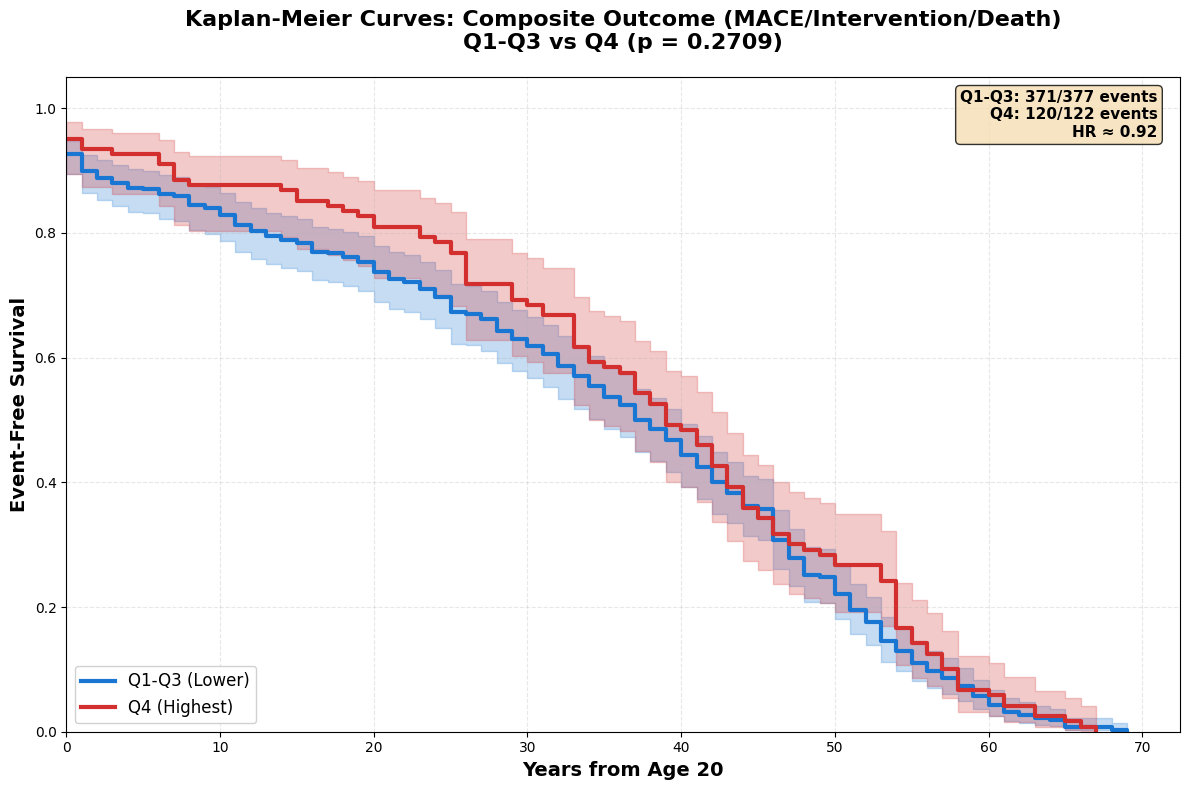


 Plot saved as 'km_curve_composite_q1q3_vs_q4.png'
EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS

5-Year Event-Free Survival:
  Q1-Q3 (Lower): 87.0% (95% CI: 83.1% - 90.0%)
  Q4 (Highest): 92.6% (95% CI: 86.3% - 96.1%) [-5.7% absolute reduction vs Q1-Q3]

10-Year Event-Free Survival:
  Q1-Q3 (Lower): 82.9% (95% CI: 78.7% - 86.4%)
  Q4 (Highest): 87.7% (95% CI: 80.4% - 92.4%) [-4.7% absolute reduction vs Q1-Q3]

15-Year Event-Free Survival:
  Q1-Q3 (Lower): 78.3% (95% CI: 73.8% - 82.2%)
  Q4 (Highest): 85.1% (95% CI: 77.5% - 90.4%) [-6.8% absolute reduction vs Q1-Q3]

20-Year Event-Free Survival:
  Q1-Q3 (Lower): 73.7% (95% CI: 69.0% - 77.9%)
  Q4 (Highest): 81.0% (95% CI: 72.8% - 86.9%) [-7.2% absolute reduction vs Q1-Q3]


In [6]:
print("Creating composite outcome and running survival analysis by PRS quartile...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome` AS

SELECT 
  *,
  -- Composite outcome: MACE OR Intervention OR Death
  CASE 
    WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 
    THEN 1 
    ELSE 0 
  END as composite_event,
  
  -- Time to composite (earliest of the three)
  LEAST(
    COALESCE(mace_followup_years, 999),
    COALESCE(intervention_followup_years, 999),
    COALESCE(death_followup_years, 999)
  ) as composite_followup_years,
  
  -- Which event happened first (for reference)
  CASE 
    WHEN mace_event = 0 AND intervention_event = 0 AND death_event = 0 THEN 'None'
    WHEN mace_followup_years <= COALESCE(intervention_followup_years, 999) 
         AND mace_followup_years <= COALESCE(death_followup_years, 999) THEN 'MACE'
    WHEN intervention_followup_years <= COALESCE(mace_followup_years, 999)
         AND intervention_followup_years <= COALESCE(death_followup_years, 999) THEN 'Intervention'
    ELSE 'Death'
  END as first_event_type,
  
  -- Binary PRS group (Q1-Q3 vs Q4)
  CASE 
    WHEN prs_quartile = 4 THEN 'Q4 (Highest)'
    ELSE 'Q1-Q3 (Lower)'
  END as prs_binary_group

FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
"""

job = client.query(query_composite)
job.result()
print(" Created composite outcome table")

# Verify composite outcomes
query_verify_composite = f"""
SELECT 
  cohort,
  prs_quartile,
  COUNT(*) as n,
  SUM(composite_event) as n_composite,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as pct_composite,
  SUM(CASE WHEN first_event_type = 'MACE' THEN 1 ELSE 0 END) as n_mace_first,
  SUM(CASE WHEN first_event_type = 'Intervention' THEN 1 ELSE 0 END) as n_intervention_first,
  SUM(CASE WHEN first_event_type = 'Death' THEN 1 ELSE 0 END) as n_death_first,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort, prs_quartile
ORDER BY cohort, prs_quartile
"""

verify_composite_df = client.query(query_verify_composite).to_dataframe()
print("\n Composite Outcome Summary by Cohort and PRS Quartile:")
display(verify_composite_df)

# Pull data for analysis
query_data = f"""
SELECT 
  person_id,
  cohort,
  prs_quartile,
  prs_binary_group,
  age_at_entry,
  composite_event,
  composite_followup_years,
  first_event_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE composite_followup_years >= 0  -- Valid follow-up
"""

df_composite = client.query(query_data).to_dataframe()
print(f"\n Loaded {len(df_composite):,} carriers for analysis")
print(f"   - HCM carriers: {len(df_composite[df_composite['cohort']=='HCM']):,}")
print(f"   - GenPop carriers: {len(df_composite[df_composite['cohort']=='GenPop']):,}")

# Analysis: Q1-Q3 vs Q4
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("\n" + "="*80)
print("BINARY COMPARISON: Q1-Q3 (Lower PRS) vs Q4 (Highest PRS)")
print("="*80)

kmf = KaplanMeierFitter()

# Summary statistics by binary group
for group in ['Q1-Q3 (Lower)', 'Q4 (Highest)']:
    df_group = df_composite[df_composite['prs_binary_group'] == group]
    print(f"\n{group}:")
    print(f"  N = {len(df_group):,}")
    print(f"  Events = {df_group['composite_event'].sum():,} ({100*df_group['composite_event'].mean():.1f}%)")
    print(f"  Median follow-up = {df_group['composite_followup_years'].median():.1f} years")
    
    kmf.fit(df_group['composite_followup_years'], df_group['composite_event'])
    if kmf.median_survival_time_ < 999:
        print(f"  Median survival time = {kmf.median_survival_time_:.1f} years")
    else:
        print(f"  Median survival time = Not reached")

# Log-rank test for binary comparison
df_lower = df_composite[df_composite['prs_binary_group'] == 'Q1-Q3 (Lower)']
df_q4 = df_composite[df_composite['prs_binary_group'] == 'Q4 (Highest)']

result_binary = logrank_test(
    durations_A=df_lower['composite_followup_years'],
    durations_B=df_q4['composite_followup_years'],
    event_observed_A=df_lower['composite_event'],
    event_observed_B=df_q4['composite_event']
)

print("\n" + "-"*80)
print(f"LOG-RANK TEST: Q1-Q3 vs Q4")
print(f"Chi-square = {result_binary.test_statistic:.2f}")
print(f"p-value = {result_binary.p_value:.4e}")
print(f"Significance: {'***' if result_binary.p_value < 0.001 else '**' if result_binary.p_value < 0.01 else '*' if result_binary.p_value < 0.05 else 'ns'}")
print("-"*80)

# Calculate hazard ratio (approximate from KM curves)
events_lower = df_lower['composite_event'].sum()
person_years_lower = df_lower['composite_followup_years'].sum()
rate_lower = events_lower / person_years_lower

events_q4 = df_q4['composite_event'].sum()
person_years_q4 = df_q4['composite_followup_years'].sum()
rate_q4 = events_q4 / person_years_q4

hr_approx = rate_q4 / rate_lower

print(f"\nAPPROXIMATE HAZARD RATIO (Q4 vs Q1-Q3):")
print(f"Event rate Q1-Q3: {rate_lower*100:.2f} per 100 person-years")
print(f"Event rate Q4: {rate_q4*100:.2f} per 100 person-years")
print(f"Hazard Ratio: {hr_approx:.2f}")

# Plot Kaplan-Meier curves: Q1-Q3 vs Q4
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

colors_binary = ['#1976D2', '#D32F2F']  # Blue vs Red
binary_groups = ['Q1-Q3 (Lower)', 'Q4 (Highest)']

for i, group in enumerate(binary_groups):
    df_group = df_composite[df_composite['prs_binary_group'] == group]
    kmf.fit(
        durations=df_group['composite_followup_years'],
        event_observed=df_group['composite_event'],
        label=group
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors_binary[i], linewidth=3)

ax.set_xlabel('Years from Age 20', fontsize=14, fontweight='bold')
ax.set_ylabel('Event-Free Survival', fontsize=14, fontweight='bold')
ax.set_title(f'Kaplan-Meier Curves: Composite Outcome (MACE/Intervention/Death)\nQ1-Q3 vs Q4 (p = {result_binary.p_value:.4f})', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.set_ylim([0, 1.05])
ax.set_xlim([0, None])

# Add sample sizes as text
n_lower = len(df_lower)
n_q4 = len(df_q4)
events_text = f"Q1-Q3: {events_lower}/{n_lower} events\nQ4: {events_q4}/{n_q4} events\nHR ≈ {hr_approx:.2f}"
ax.text(0.98, 0.98, events_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('km_curve_composite_q1q3_vs_q4.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot saved as 'km_curve_composite_q1q3_vs_q4.png'")

# Event-free survival at specific time points
print("EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS")

time_points = [5, 10, 15, 20]

for t in time_points:
    print(f"\n{t}-Year Event-Free Survival:")
    for group in binary_groups:
        df_group = df_composite[df_composite['prs_binary_group'] == group]
        kmf.fit(df_group['composite_followup_years'], df_group['composite_event'])
        
        if t <= kmf.survival_function_.index.max():
            surv_prob = kmf.predict(t)
            ci = kmf.confidence_interval_survival_function_.loc[
                kmf.confidence_interval_survival_function_.index <= t
            ].iloc[-1]
            
            # Calculate absolute difference if this is Q4
            if group == 'Q4 (Highest)':
                df_lower_temp = df_composite[df_composite['prs_binary_group'] == 'Q1-Q3 (Lower)']
                kmf_lower = KaplanMeierFitter()
                kmf_lower.fit(df_lower_temp['composite_followup_years'], df_lower_temp['composite_event'])
                surv_lower = kmf_lower.predict(t)
                abs_diff = (surv_lower - surv_prob) * 100
                
                print(f"  {group}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%) "
                      f"[{abs_diff:.1f}% absolute reduction vs Q1-Q3]")
            else:
                print(f"  {group}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%)")
        else:
            print(f"  {group}: Insufficient follow-up")

In [28]:
print("Creating survival analysis dataset for gen_pop_carriers (one row per person, multiple outcome columns)...")

query_survival = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data` AS

WITH cohort_base AS (
  SELECT DISTINCT
    person_id,
    PRS,
    TRUE as is_carrier,
    DATE(PARSE_TIMESTAMP('%Y-%m-%d %H:%M:%S', birth_datetime)) as birth_date,
    CAST(left_truncation_date AS DATE) as left_truncation_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
),

cohort_dedup AS (
  SELECT 
    person_id,
    ANY_VALUE(prs) as prs,
    ANY_VALUE(is_carrier) as is_carrier,
    ANY_VALUE(birth_date) as birth_date,
    ANY_VALUE(left_truncation_date) as left_truncation_date
  FROM cohort_base
  GROUP BY person_id
),

cohort_with_prs AS (
  SELECT 
    person_id,
    prs,
    is_carrier,
    birth_date,
    left_truncation_date,
    NTILE(4) OVER (ORDER BY prs) as prs_quartile
  FROM cohort_dedup
  WHERE prs IS NOT NULL
),

mace_events AS (
  SELECT 
    person_id,
    MIN(event_date) as mace_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_mace_events`
  GROUP BY person_id
),

intervention_events AS (
  SELECT 
    person_id,
    MIN(event_date) as intervention_date
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_intervention_events`
  GROUP BY person_id
),

death_events AS (
  SELECT 
    person_id,
    MIN(event_date) as death_date  -- Added MIN() for consistency
  FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_death_events`
  GROUP BY person_id  -- Added GROUP BY
)

SELECT 
  c.person_id,
  c.is_carrier,
  c.prs,
  c.prs_quartile,
  c.birth_date,
  c.left_truncation_date,
  v.last_visit_date,
  
  -- MACE outcome
  CASE WHEN m.mace_date IS NOT NULL THEN 1 ELSE 0 END as mace_event,
  m.mace_date,
  COALESCE(
    DATE_DIFF(m.mace_date, c.left_truncation_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.left_truncation_date, DAY)
  ) as mace_time_days,
  
  -- Intervention outcome
  CASE WHEN i.intervention_date IS NOT NULL THEN 1 ELSE 0 END as intervention_event,
  i.intervention_date,
  COALESCE(
    DATE_DIFF(i.intervention_date, c.left_truncation_date, DAY),
    DATE_DIFF(COALESCE(v.last_visit_date, d.death_date), c.left_truncation_date, DAY)
  ) as intervention_time_days,
  
  -- Death outcome
  CASE WHEN d.death_date IS NOT NULL THEN 1 ELSE 0 END as death_event,
  d.death_date,
  COALESCE(
    DATE_DIFF(d.death_date, c.left_truncation_date, DAY),
    DATE_DIFF(v.last_visit_date, c.left_truncation_date, DAY)
  ) as death_time_days

FROM cohort_with_prs c
LEFT JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_last_visit_dates` v 
  ON c.person_id = v.person_id
LEFT JOIN mace_events m ON c.person_id = m.person_id
LEFT JOIN intervention_events i ON c.person_id = i.person_id
LEFT JOIN death_events d ON c.person_id = d.person_id

WHERE c.prs IS NOT NULL
  AND c.birth_date IS NOT NULL  -- Added for age-based analysis
  AND c.left_truncation_date IS NOT NULL
ORDER BY c.person_id
"""

job = client.query(query_survival)
job.result()
print(" Created gen_pop_carriers_survival_data table")

# Verify and show sample
query_verify = f"""
SELECT 
  COUNT(*) as total_rows,
  COUNT(DISTINCT person_id) as unique_persons,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death,
  COUNTIF(birth_date IS NULL) as missing_birth_date,
  COUNTIF(left_truncation_date IS NULL) as missing_left_truncation
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
"""

verify_df = client.query(query_verify).to_dataframe()
print(f"\n Verification:")
print(f"Total rows: {verify_df['total_rows'].values[0]}")
print(f"Unique persons: {verify_df['unique_persons'].values[0]}")
print(f"Match: {' YES' if verify_df['total_rows'].values[0] == verify_df['unique_persons'].values[0] else '✗ NO'}")
print(f"\nEvent counts:")
print(f"  MACE: {verify_df['n_mace'].values[0]}")
print(f"  Intervention: {verify_df['n_intervention'].values[0]}")
print(f"  Death: {verify_df['n_death'].values[0]}")

# Show sample with multiple outcomes
query_sample = f"""
SELECT 
  person_id,
  prs_quartile,
  birth_date,
  left_truncation_date,
  last_visit_date,
  mace_event,
  mace_date,
  ROUND(mace_time_days/365.25, 1) as mace_years,
  intervention_event,
  intervention_date,
  ROUND(intervention_time_days/365.25, 1) as intervention_years,
  death_event,
  death_date,
  ROUND(death_time_days/365.25, 1) as death_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
WHERE mace_event = 1 OR intervention_event = 1 OR death_event = 1
ORDER BY person_id
LIMIT 10
"""

sample_df = client.query(query_sample).to_dataframe()
print("\n Sample rows with events:")
display(sample_df)

# PRS quartile distribution
query_prs_dist = f"""
SELECT 
  prs_quartile,
  COUNT(*) as n_persons,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death,
  ROUND(AVG(prs), 4) as mean_prs,
  ROUND(AVG(mace_time_days)/365.25, 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

prs_dist = client.query(query_prs_dist).to_dataframe()
print("\n Events by PRS Quartile:")
display(prs_dist)

print("Now creating AGE-BASED survival table (ALL CARRIERS START AT AGE 20)...")

# GEN POP CARRIERS - Age-based survival starting at age 20
query_genpop_age = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based` AS

SELECT 
  person_id,
  is_carrier,
  prs,
  prs_quartile,
  birth_date,
  
  -- Entry date is LATER of: age 20 or left truncation
  GREATEST(
    DATE_ADD(birth_date, INTERVAL 20 YEAR),
    left_truncation_date
  ) as entry_date,
  
  left_truncation_date,
  last_visit_date,
  
  -- Age at entry (should be 20+ for all)
  DATE_DIFF(
    GREATEST(
      DATE_ADD(birth_date, INTERVAL 20 YEAR),
      left_truncation_date
    ),
    birth_date,
    YEAR
  ) as age_at_entry,
  
  -- MACE outcome
  mace_event,
  mace_date,
  mace_time_days,
  CASE 
    WHEN mace_date IS NOT NULL 
    THEN DATE_DIFF(mace_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_mace,
  CASE 
    WHEN mace_event = 1
    THEN DATE_DIFF(
      mace_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(last_visit_date, death_date),
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as mace_followup_years,
  
  -- Intervention outcome
  intervention_event,
  intervention_date,
  intervention_time_days,
  CASE 
    WHEN intervention_date IS NOT NULL 
    THEN DATE_DIFF(intervention_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_intervention,
  CASE 
    WHEN intervention_event = 1
    THEN DATE_DIFF(
      intervention_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      COALESCE(last_visit_date, death_date),
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as intervention_followup_years,
  
  -- Death outcome
  death_event,
  death_date,
  death_time_days,
  CASE 
    WHEN death_date IS NOT NULL 
    THEN DATE_DIFF(death_date, birth_date, YEAR)
    ELSE NULL 
  END as age_at_death,
  CASE 
    WHEN death_event = 1
    THEN DATE_DIFF(
      death_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
    ELSE DATE_DIFF(
      last_visit_date,
      GREATEST(DATE_ADD(birth_date, INTERVAL 20 YEAR), left_truncation_date),
      YEAR
    )
  END as death_followup_years,
  
  'GenPop' as cohort

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_data`
WHERE birth_date IS NOT NULL
  AND left_truncation_date IS NOT NULL
"""

job = client.query(query_genpop_age)
job.result()
print(" Created gen_pop_carriers_survival_age_based")

# Verify the age distribution
query_verify_age = f"""
SELECT 
  COUNT(*) as n,
  MIN(age_at_entry) as min_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(1)] as q1_entry_age,
  APPROX_QUANTILES(age_at_entry, 2)[OFFSET(1)] as median_entry_age,
  APPROX_QUANTILES(age_at_entry, 4)[OFFSET(3)] as q3_entry_age,
  MAX(age_at_entry) as max_entry_age,
  ROUND(AVG(age_at_entry), 1) as mean_entry_age,
  SUM(mace_event) as n_mace,
  SUM(intervention_event) as n_intervention,
  SUM(death_event) as n_death,
  COUNTIF(age_at_entry < 20) as n_below_age_20
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
"""

verify_age_df = client.query(query_verify_age).to_dataframe()
print("\n Age-Based Model - Entry Age Distribution:")
display(verify_age_df)

# Sample with age info
query_sample_age = f"""
SELECT 
  person_id,
  prs_quartile,
  birth_date,
  left_truncation_date,
  entry_date,
  age_at_entry,
  mace_event,
  age_at_mace,
  mace_followup_years,
  intervention_event,
  age_at_intervention,
  intervention_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
WHERE mace_event = 1 OR intervention_event = 1
ORDER BY person_id
LIMIT 10
"""

sample_age_df = client.query(query_sample_age).to_dataframe()
print("\n Sample rows with events (age-based):")
display(sample_age_df)

Creating survival analysis dataset for gen_pop_carriers (one row per person, multiple outcome columns)...
 Created gen_pop_carriers_survival_data table

 Verification:
Total rows: 1510
Unique persons: 1510
Match:  YES

Event counts:
  MACE: 430
  Intervention: 135
  Death: 105

 Sample rows with events:


,person_id,prs_quartile,birth_date,left_truncation_date,last_visit_date,mace_event,mace_date,mace_years,intervention_event,intervention_date,intervention_years,death_event,death_date,death_years
0,R200276866,4,1950-03-20,1970-03-20,2011-11-06,1,2011-05-22,41.2,0,NaT,41.6,0,NaT,41.6
1,R200490840,3,1962-07-17,1982-07-17,2025-05-01,1,2024-05-16,41.8,0,NaT,42.8,0,NaT,42.8
2,R200730951,3,1954-12-07,1974-12-07,2015-02-08,1,1999-11-02,24.9,1,1999-11-02,24.9,0,NaT,40.2
3,R200738012,4,1949-01-12,1969-01-12,2024-03-01,0,NaT,55.1,0,NaT,55.1,1,2024-02-10,55.1
4,R200847967,2,1979-06-18,1999-06-18,2014-03-29,1,2011-05-15,11.9,0,NaT,14.8,0,NaT,14.8
5,R200895831,1,1974-02-22,1994-02-22,2025-06-11,1,2023-09-06,29.5,0,NaT,31.3,0,NaT,31.3
6,R201326124,1,1954-08-22,1974-08-22,2015-11-26,1,2015-12-25,41.3,0,NaT,41.3,1,2015-12-25,41.3
7,R202050839,1,2004-06-28,2024-06-28,2025-01-22,1,2024-12-16,0.5,0,NaT,0.6,0,NaT,0.6
8,R202875973,4,1945-10-03,1965-10-03,2009-02-02,1,2002-02-15,36.4,1,2006-05-14,40.6,1,2009-02-02,43.3
9,R203277003,2,1945-09-30,1965-09-30,2016-02-18,1,2011-01-25,45.3,0,NaT,50.4,0,NaT,50.4



 Events by PRS Quartile:


,prs_quartile,n_persons,n_mace,n_intervention,n_death,mean_prs,mean_followup_years
0,1,378,110,32,25,-4.8278,28.8
1,2,378,98,24,23,-4.2646,28.9
2,3,377,104,33,23,-3.8543,28.2
3,4,377,118,46,34,-3.1994,29.9


Now creating AGE-BASED survival table (ALL CARRIERS START AT AGE 20)...
 Created gen_pop_carriers_survival_age_based

 Age-Based Model - Entry Age Distribution:


,n,min_entry_age,q1_entry_age,median_entry_age,q3_entry_age,max_entry_age,mean_entry_age,n_mace,n_intervention,n_death,n_below_age_20
0,1510,20,20,20,20,20,20.0,430,135,105,0



 Sample rows with events (age-based):


,person_id,prs_quartile,birth_date,left_truncation_date,entry_date,age_at_entry,mace_event,age_at_mace,mace_followup_years,intervention_event,age_at_intervention,intervention_followup_years
0,R200276866,4,1950-03-20,1970-03-20,1970-03-20,20,1,61,41,0,<NA>,41
1,R200490840,3,1962-07-17,1982-07-17,1982-07-17,20,1,62,42,0,<NA>,43
2,R200730951,3,1954-12-07,1974-12-07,1974-12-07,20,1,45,25,1,45,25
3,R200847967,2,1979-06-18,1999-06-18,1999-06-18,20,1,32,12,0,<NA>,15
4,R200895831,1,1974-02-22,1994-02-22,1994-02-22,20,1,49,29,0,<NA>,31
5,R201326124,1,1954-08-22,1974-08-22,1974-08-22,20,1,61,41,0,<NA>,41
6,R202050839,1,2004-06-28,2024-06-28,2024-06-28,20,1,20,0,0,<NA>,1
7,R202875973,4,1945-10-03,1965-10-03,1965-10-03,20,1,57,37,1,61,41
8,R203277003,2,1945-09-30,1965-09-30,1965-09-30,20,1,66,46,0,<NA>,51
9,R203648768,3,1987-09-15,2007-09-15,2007-09-15,20,1,20,0,1,20,0


Creating composite outcome and running survival analysis by PRS quartile...
 Created composite outcome table

 Composite Outcome Summary by Cohort and PRS Quartile:


,cohort,prs_quartile,n,n_composite,pct_composite,n_mace_first,n_intervention_first,n_death_first,mean_followup_years
0,GenPop,1,378,115,30.4,113,2,0,28.8
1,GenPop,2,378,105,27.8,103,2,0,28.9
2,GenPop,3,377,107,28.4,106,1,0,28.1
3,GenPop,4,377,130,34.5,128,2,0,29.8
4,HCM,1,11,10,90.9,10,0,0,3.7
5,HCM,2,9,8,88.9,7,1,0,2.4
6,HCM,3,15,11,73.3,10,1,0,1.2
7,HCM,4,11,9,81.8,7,2,0,1.0



✓ Loaded 1,410 carriers for analysis
   - HCM carriers: 42
   - GenPop carriers: 1,368

KAPLAN-MEIER ANALYSIS: Composite Outcome by PRS Quartile (ALL CARRIERS COMBINED)

PRS Quartile 1:
  N = 356
  Events = 125 (35.1%)
  Median follow-up = 33.0 years
  Median survival time = 50.0 years

PRS Quartile 2:
  N = 351
  Events = 113 (32.2%)
  Median follow-up = 34.0 years
  Median survival time = 54.0 years

PRS Quartile 3:
  N = 357
  Events = 117 (32.8%)
  Median follow-up = 31.0 years
  Median survival time = 52.0 years

PRS Quartile 4:
  N = 346
  Events = 136 (39.3%)
  Median follow-up = 35.0 years
  Median survival time = 54.0 years

--------------------------------------------------------------------------------
LOG-RANK TESTS (Pairwise Comparisons):
--------------------------------------------------------------------------------
Q1 vs Q2: p = 0.1074 ns
Q1 vs Q3: p = 0.4973 ns
Q1 vs Q4: p = 0.5888 ns
Q2 vs Q3: p = 0.4156 ns
Q2 vs Q4: p = 0.2385 ns
Q3 vs Q4: p = 0.8117 ns


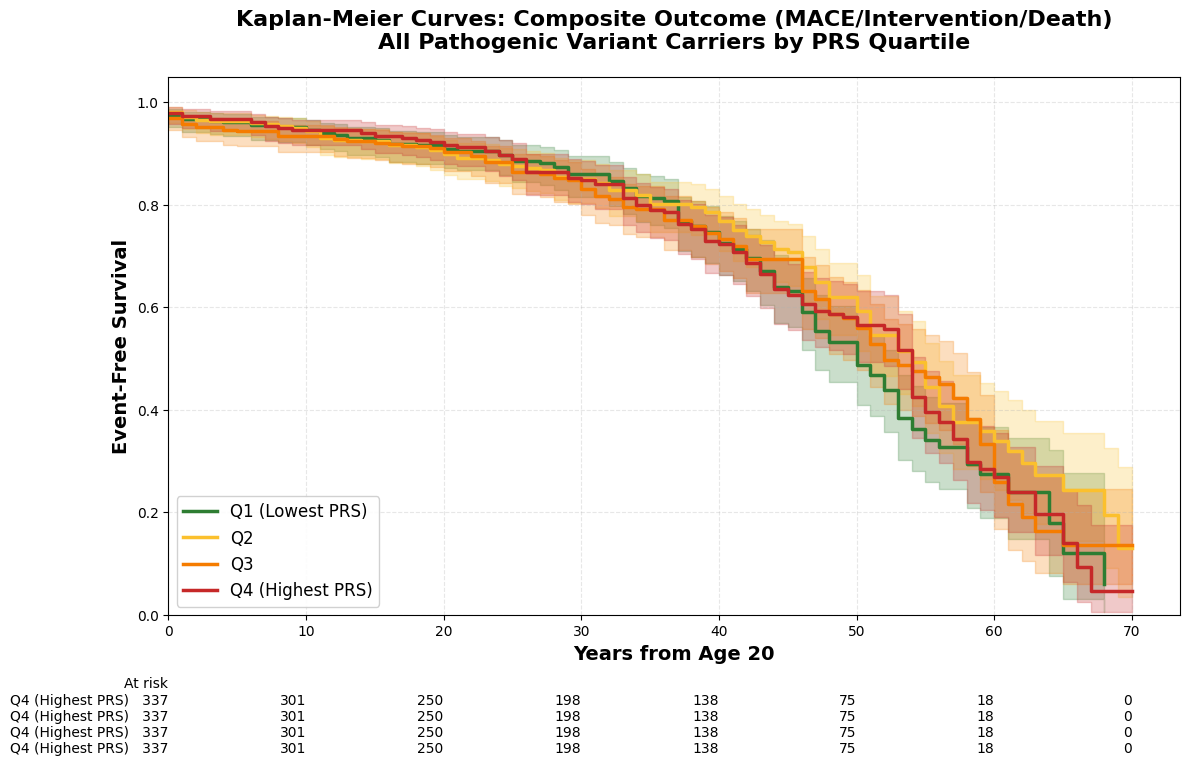


 Plot saved as 'km_curve_composite_all_carriers_by_prs_quartile.png'
EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS (ALL CARRIERS):

5-Year Event-Free Survival:
  Q1: 96.0% (95% CI: 93.4% - 97.6%)
  Q2: 96.3% (95% CI: 93.7% - 97.8%)
  Q3: 94.4% (95% CI: 91.4% - 96.3%)
  Q4: 96.8% (95% CI: 94.3% - 98.2%)

10-Year Event-Free Survival:
  Q1: 94.5% (95% CI: 91.6% - 96.5%)
  Q2: 94.4% (95% CI: 91.3% - 96.4%)
  Q3: 93.4% (95% CI: 90.3% - 95.6%)
  Q4: 94.6% (95% CI: 91.6% - 96.6%)

15-Year Event-Free Survival:
  Q1: 92.6% (95% CI: 89.2% - 94.9%)
  Q2: 92.4% (95% CI: 88.9% - 94.8%)
  Q3: 92.1% (95% CI: 88.7% - 94.5%)
  Q4: 93.3% (95% CI: 90.0% - 95.6%)

20-Year Event-Free Survival:
  Q1: 90.8% (95% CI: 87.1% - 93.5%)
  Q2: 89.8% (95% CI: 85.9% - 92.7%)
  Q3: 90.3% (95% CI: 86.6% - 93.1%)
  Q4: 91.6% (95% CI: 87.9% - 94.1%)


In [29]:
print("Creating composite outcome and running survival analysis by PRS quartile...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome` AS

SELECT 
  *,
  -- Composite outcome: MACE OR Intervention OR Death
  CASE 
    WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 
    THEN 1 
    ELSE 0 
  END as composite_event,
  
  -- Time to composite (earliest of the three)
  LEAST(
    COALESCE(mace_followup_years, 999),
    COALESCE(intervention_followup_years, 999),
    COALESCE(death_followup_years, 999)
  ) as composite_followup_years,
  
  -- Which event happened first (for reference)
  CASE 
    WHEN mace_event = 0 AND intervention_event = 0 AND death_event = 0 THEN 'None'
    WHEN mace_followup_years <= COALESCE(intervention_followup_years, 999) 
         AND mace_followup_years <= COALESCE(death_followup_years, 999) THEN 'MACE'
    WHEN intervention_followup_years <= COALESCE(mace_followup_years, 999)
         AND intervention_followup_years <= COALESCE(death_followup_years, 999) THEN 'Intervention'
    ELSE 'Death'
  END as first_event_type

FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
"""

job = client.query(query_composite)
job.result()
print(" Created composite outcome table")

# Verify composite outcomes
query_verify_composite = f"""
SELECT 
  cohort,
  prs_quartile,
  COUNT(*) as n,
  SUM(composite_event) as n_composite,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as pct_composite,
  SUM(CASE WHEN first_event_type = 'MACE' THEN 1 ELSE 0 END) as n_mace_first,
  SUM(CASE WHEN first_event_type = 'Intervention' THEN 1 ELSE 0 END) as n_intervention_first,
  SUM(CASE WHEN first_event_type = 'Death' THEN 1 ELSE 0 END) as n_death_first,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort, prs_quartile
ORDER BY cohort, prs_quartile
"""

verify_composite_df = client.query(query_verify_composite).to_dataframe()
print("\n Composite Outcome Summary by Cohort and PRS Quartile:")
display(verify_composite_df)

# Pull data for analysis
query_data = f"""
SELECT 
  person_id,
  cohort,
  prs_quartile,
  age_at_entry,
  composite_event,
  composite_followup_years,
  first_event_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE composite_followup_years >= 0  -- Valid follow-up
"""

df_composite = client.query(query_data).to_dataframe()
print(f"\n✓ Loaded {len(df_composite):,} carriers for analysis")
print(f"   - HCM carriers: {len(df_composite[df_composite['cohort']=='HCM']):,}")
print(f"   - GenPop carriers: {len(df_composite[df_composite['cohort']=='GenPop']):,}")

# Fit Kaplan-Meier curves by PRS quartile (combining both cohorts)
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("\n" + "="*80)
print("KAPLAN-MEIER ANALYSIS: Composite Outcome by PRS Quartile (ALL CARRIERS COMBINED)")
print("="*80)

kmf = KaplanMeierFitter()
quartiles = sorted(df_composite['prs_quartile'].unique())

# Fit KM for each quartile
km_results = {}
for q in quartiles:
    df_q = df_composite[df_composite['prs_quartile'] == q]
    kmf.fit(
        durations=df_q['composite_followup_years'],
        event_observed=df_q['composite_event'],
        label=f'Q{q}'
    )
    km_results[q] = kmf.survival_function_.copy()
    
    # Print summary stats
    print(f"\nPRS Quartile {q}:")
    print(f"  N = {len(df_q):,}")
    print(f"  Events = {df_q['composite_event'].sum():,} ({100*df_q['composite_event'].mean():.1f}%)")
    print(f"  Median follow-up = {df_q['composite_followup_years'].median():.1f} years")
    if kmf.median_survival_time_ < 999:
        print(f"  Median survival time = {kmf.median_survival_time_:.1f} years")
    else:
        print(f"  Median survival time = Not reached")

# Log-rank tests
print("\n" + "-"*80)
print("LOG-RANK TESTS (Pairwise Comparisons):")
print("-"*80)

from itertools import combinations
for q1, q2 in combinations(quartiles, 2):
    df_q1 = df_composite[df_composite['prs_quartile'] == q1]
    df_q2 = df_composite[df_composite['prs_quartile'] == q2]
    
    result = logrank_test(
        durations_A=df_q1['composite_followup_years'],
        durations_B=df_q2['composite_followup_years'],
        event_observed_A=df_q1['composite_event'],
        event_observed_B=df_q2['composite_event']
    )
    
    print(f"Q{q1} vs Q{q2}: p = {result.p_value:.4f} {'***' if result.p_value < 0.001 else '**' if result.p_value < 0.01 else '*' if result.p_value < 0.05 else 'ns'}")

# Plot Kaplan-Meier curves
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2E7D32', '#FBC02D', '#F57C00', '#C62828']  # Green to Red gradient
quartile_labels = {1: 'Q1 (Lowest PRS)', 2: 'Q2', 3: 'Q3', 4: 'Q4 (Highest PRS)'}

for i, q in enumerate(quartiles):
    df_q = df_composite[df_composite['prs_quartile'] == q]
    kmf.fit(
        durations=df_q['composite_followup_years'],
        event_observed=df_q['composite_event'],
        label=quartile_labels.get(q, f'Q{q}')
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[i], linewidth=2.5)

ax.set_xlabel('Years from Age 20', fontsize=14, fontweight='bold')
ax.set_ylabel('Event-Free Survival', fontsize=14, fontweight='bold')
ax.set_title('Kaplan-Meier Curves: Composite Outcome (MACE/Intervention/Death)\nAll Pathogenic Variant Carriers by PRS Quartile', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.set_ylim([0, 1.05])
ax.set_xlim([0, None])

# Add at-risk table
from lifelines.plotting import add_at_risk_counts
add_at_risk_counts(
    *[kmf.fit(df_composite[df_composite['prs_quartile']==q]['composite_followup_years'],
              df_composite[df_composite['prs_quartile']==q]['composite_event']) 
      for q in quartiles],
    ax=ax,
    rows_to_show=['At risk']
)

plt.tight_layout()
plt.savefig('km_curve_composite_all_carriers_by_prs_quartile.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot saved as 'km_curve_composite_all_carriers_by_prs_quartile.png'")

# Additional analysis: Event rates at specific time points
print("EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS (ALL CARRIERS):")
time_points = [5, 10, 15, 20]
for t in time_points:
    print(f"\n{t}-Year Event-Free Survival:")
    for q in quartiles:
        df_q = df_composite[df_composite['prs_quartile'] == q]
        kmf.fit(df_q['composite_followup_years'], df_q['composite_event'])
        
        # Get survival probability at time t
        if t <= kmf.survival_function_.index.max():
            surv_prob = kmf.predict(t)
            ci = kmf.confidence_interval_survival_function_.loc[
                kmf.confidence_interval_survival_function_.index <= t
            ].iloc[-1]
            print(f"  Q{q}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%)")
        else:
            print(f"  Q{q}: Insufficient follow-up")

Creating composite outcome and running survival analysis by PRS quartile...
✓ Created composite outcome table

✓ Composite Outcome Summary by Cohort and PRS Quartile:


,cohort,prs_quartile,n,n_composite,pct_composite,n_mace_first,n_intervention_first,n_death_first,mean_followup_years
0,GenPop,1,378,115,30.4,113,2,0,28.8
1,GenPop,2,378,105,27.8,103,2,0,28.9
2,GenPop,3,377,107,28.4,106,1,0,28.1
3,GenPop,4,377,130,34.5,128,2,0,29.8
4,HCM,1,11,10,90.9,10,0,0,3.7
5,HCM,2,9,8,88.9,7,1,0,2.4
6,HCM,3,15,11,73.3,10,1,0,1.2
7,HCM,4,11,9,81.8,7,2,0,1.0



✓ Loaded 1,410 carriers for analysis
   - HCM carriers: 42
   - GenPop carriers: 1,368

BINARY COMPARISON: Q1-Q3 (Lower PRS) vs Q4 (Highest PRS)

Q1-Q3 (Lower):
  N = 1,064
  Events = 355 (33.4%)
  Median follow-up = 32.0 years
  Median survival time = 52.0 years

Q4 (Highest):
  N = 346
  Events = 136 (39.3%)
  Median follow-up = 35.0 years
  Median survival time = 54.0 years

--------------------------------------------------------------------------------
LOG-RANK TEST: Q1-Q3 vs Q4
Chi-square = 0.13
p-value = 7.1947e-01
Significance: ns
--------------------------------------------------------------------------------

APPROXIMATE HAZARD RATIO (Q4 vs Q1-Q3):
Event rate Q1-Q3: 1.07 per 100 person-years
Event rate Q4: 1.17 per 100 person-years
Hazard Ratio: 1.10


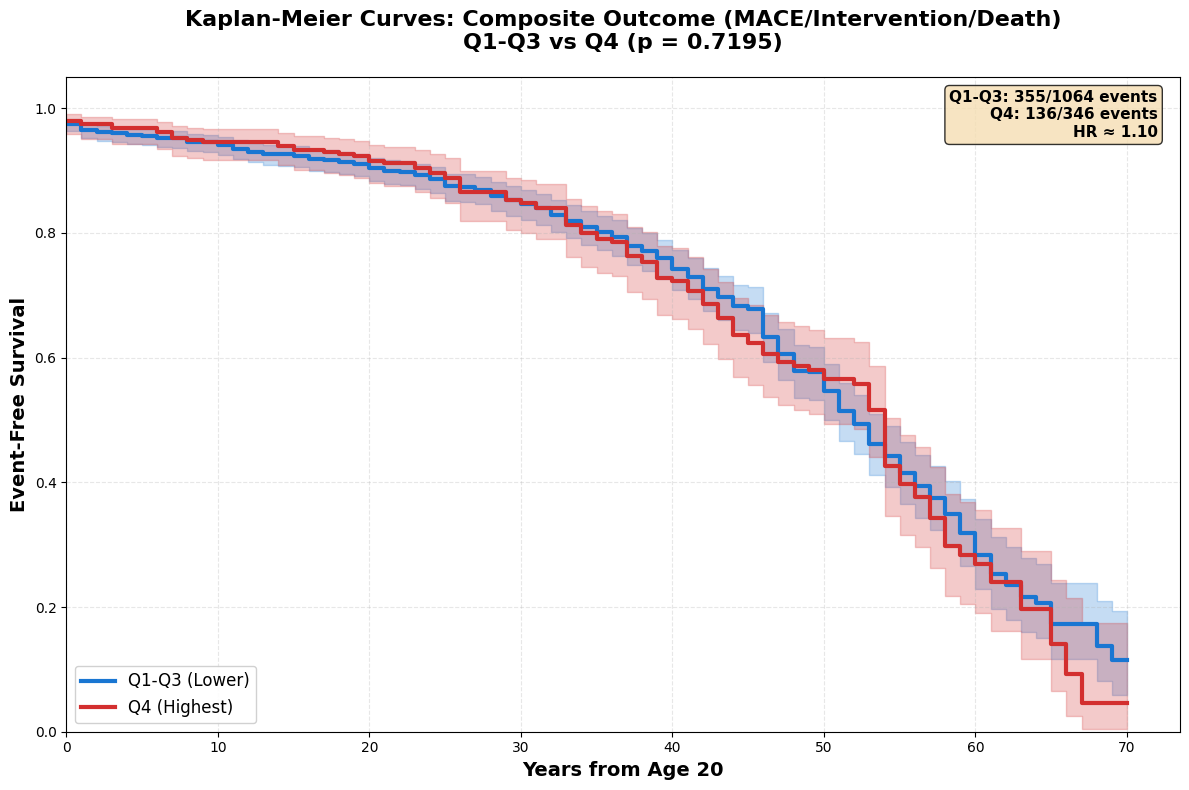


 Plot saved as 'km_curve_composite_q1q3_vs_q4.png'
EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS

5-Year Event-Free Survival:
  Q1-Q3 (Lower): 95.5% (95% CI: 94.1% - 96.6%)
  Q4 (Highest): 96.8% (95% CI: 94.3% - 98.2%) [-1.3% absolute reduction vs Q1-Q3]

10-Year Event-Free Survival:
  Q1-Q3 (Lower): 94.1% (95% CI: 92.5% - 95.4%)
  Q4 (Highest): 94.6% (95% CI: 91.6% - 96.6%) [-0.5% absolute reduction vs Q1-Q3]

15-Year Event-Free Survival:
  Q1-Q3 (Lower): 92.4% (95% CI: 90.5% - 93.9%)
  Q4 (Highest): 93.3% (95% CI: 90.0% - 95.6%) [-1.0% absolute reduction vs Q1-Q3]

20-Year Event-Free Survival:
  Q1-Q3 (Lower): 90.3% (95% CI: 88.3% - 92.0%)
  Q4 (Highest): 91.6% (95% CI: 87.9% - 94.1%) [-1.2% absolute reduction vs Q1-Q3]


In [30]:
print("Creating composite outcome and running survival analysis by PRS quartile...")

query_composite = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome` AS

SELECT 
  *,
  -- Composite outcome: MACE OR Intervention OR Death
  CASE 
    WHEN mace_event = 1 OR intervention_event = 1 OR death_event = 1 
    THEN 1 
    ELSE 0 
  END as composite_event,
  
  -- Time to composite (earliest of the three)
  LEAST(
    COALESCE(mace_followup_years, 999),
    COALESCE(intervention_followup_years, 999),
    COALESCE(death_followup_years, 999)
  ) as composite_followup_years,
  
  -- Which event happened first (for reference)
  CASE 
    WHEN mace_event = 0 AND intervention_event = 0 AND death_event = 0 THEN 'None'
    WHEN mace_followup_years <= COALESCE(intervention_followup_years, 999) 
         AND mace_followup_years <= COALESCE(death_followup_years, 999) THEN 'MACE'
    WHEN intervention_followup_years <= COALESCE(mace_followup_years, 999)
         AND intervention_followup_years <= COALESCE(death_followup_years, 999) THEN 'Intervention'
    ELSE 'Death'
  END as first_event_type,
  
  -- Binary PRS group (Q1-Q3 vs Q4)
  CASE 
    WHEN prs_quartile = 4 THEN 'Q4 (Highest)'
    ELSE 'Q1-Q3 (Lower)'
  END as prs_binary_group

FROM (
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.hcm_carriers_survival_age_based`
  UNION ALL
  SELECT * FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_survival_age_based`
)
"""

job = client.query(query_composite)
job.result()
print("✓ Created composite outcome table")

# Verify composite outcomes
query_verify_composite = f"""
SELECT 
  cohort,
  prs_quartile,
  COUNT(*) as n,
  SUM(composite_event) as n_composite,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as pct_composite,
  SUM(CASE WHEN first_event_type = 'MACE' THEN 1 ELSE 0 END) as n_mace_first,
  SUM(CASE WHEN first_event_type = 'Intervention' THEN 1 ELSE 0 END) as n_intervention_first,
  SUM(CASE WHEN first_event_type = 'Death' THEN 1 ELSE 0 END) as n_death_first,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort, prs_quartile
ORDER BY cohort, prs_quartile
"""

verify_composite_df = client.query(query_verify_composite).to_dataframe()
print("\n Composite Outcome Summary by Cohort and PRS Quartile:")
display(verify_composite_df)

# Pull data for analysis
query_data = f"""
SELECT 
  person_id,
  cohort,
  prs_quartile,
  prs_binary_group,
  age_at_entry,
  composite_event,
  composite_followup_years,
  first_event_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE composite_followup_years >= 0  -- Valid follow-up
"""

df_composite = client.query(query_data).to_dataframe()
print(f"\n✓ Loaded {len(df_composite):,} carriers for analysis")
print(f"   - HCM carriers: {len(df_composite[df_composite['cohort']=='HCM']):,}")
print(f"   - GenPop carriers: {len(df_composite[df_composite['cohort']=='GenPop']):,}")

# Analysis: Q1-Q3 vs Q4
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("\n" + "="*80)
print("BINARY COMPARISON: Q1-Q3 (Lower PRS) vs Q4 (Highest PRS)")
print("="*80)

kmf = KaplanMeierFitter()

# Summary statistics by binary group
for group in ['Q1-Q3 (Lower)', 'Q4 (Highest)']:
    df_group = df_composite[df_composite['prs_binary_group'] == group]
    print(f"\n{group}:")
    print(f"  N = {len(df_group):,}")
    print(f"  Events = {df_group['composite_event'].sum():,} ({100*df_group['composite_event'].mean():.1f}%)")
    print(f"  Median follow-up = {df_group['composite_followup_years'].median():.1f} years")
    
    kmf.fit(df_group['composite_followup_years'], df_group['composite_event'])
    if kmf.median_survival_time_ < 999:
        print(f"  Median survival time = {kmf.median_survival_time_:.1f} years")
    else:
        print(f"  Median survival time = Not reached")

# Log-rank test for binary comparison
df_lower = df_composite[df_composite['prs_binary_group'] == 'Q1-Q3 (Lower)']
df_q4 = df_composite[df_composite['prs_binary_group'] == 'Q4 (Highest)']

result_binary = logrank_test(
    durations_A=df_lower['composite_followup_years'],
    durations_B=df_q4['composite_followup_years'],
    event_observed_A=df_lower['composite_event'],
    event_observed_B=df_q4['composite_event']
)

print("\n" + "-"*80)
print(f"LOG-RANK TEST: Q1-Q3 vs Q4")
print(f"Chi-square = {result_binary.test_statistic:.2f}")
print(f"p-value = {result_binary.p_value:.4e}")
print(f"Significance: {'***' if result_binary.p_value < 0.001 else '**' if result_binary.p_value < 0.01 else '*' if result_binary.p_value < 0.05 else 'ns'}")
print("-"*80)

# Calculate hazard ratio (approximate from KM curves)
events_lower = df_lower['composite_event'].sum()
person_years_lower = df_lower['composite_followup_years'].sum()
rate_lower = events_lower / person_years_lower

events_q4 = df_q4['composite_event'].sum()
person_years_q4 = df_q4['composite_followup_years'].sum()
rate_q4 = events_q4 / person_years_q4

hr_approx = rate_q4 / rate_lower

print(f"\nAPPROXIMATE HAZARD RATIO (Q4 vs Q1-Q3):")
print(f"Event rate Q1-Q3: {rate_lower*100:.2f} per 100 person-years")
print(f"Event rate Q4: {rate_q4*100:.2f} per 100 person-years")
print(f"Hazard Ratio: {hr_approx:.2f}")

# Plot Kaplan-Meier curves: Q1-Q3 vs Q4
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 8))

colors_binary = ['#1976D2', '#D32F2F']  # Blue vs Red
binary_groups = ['Q1-Q3 (Lower)', 'Q4 (Highest)']

for i, group in enumerate(binary_groups):
    df_group = df_composite[df_composite['prs_binary_group'] == group]
    kmf.fit(
        durations=df_group['composite_followup_years'],
        event_observed=df_group['composite_event'],
        label=group
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors_binary[i], linewidth=3)

ax.set_xlabel('Years from Age 20', fontsize=14, fontweight='bold')
ax.set_ylabel('Event-Free Survival', fontsize=14, fontweight='bold')
ax.set_title(f'Kaplan-Meier Curves: Composite Outcome (MACE/Intervention/Death)\nQ1-Q3 vs Q4 (p = {result_binary.p_value:.4f})', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=12, framealpha=0.9)
ax.set_ylim([0, 1.05])
ax.set_xlim([0, None])

# Add sample sizes as text
n_lower = len(df_lower)
n_q4 = len(df_q4)
events_text = f"Q1-Q3: {events_lower}/{n_lower} events\nQ4: {events_q4}/{n_q4} events\nHR ≈ {hr_approx:.2f}"
ax.text(0.98, 0.98, events_text, transform=ax.transAxes,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('km_curve_composite_q1q3_vs_q4.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot saved as 'km_curve_composite_q1q3_vs_q4.png'")

# Event-free survival at specific time points
print("EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS")

time_points = [5, 10, 15, 20]

for t in time_points:
    print(f"\n{t}-Year Event-Free Survival:")
    for group in binary_groups:
        df_group = df_composite[df_composite['prs_binary_group'] == group]
        kmf.fit(df_group['composite_followup_years'], df_group['composite_event'])
        
        if t <= kmf.survival_function_.index.max():
            surv_prob = kmf.predict(t)
            ci = kmf.confidence_interval_survival_function_.loc[
                kmf.confidence_interval_survival_function_.index <= t
            ].iloc[-1]
            
            # Calculate absolute difference if this is Q4
            if group == 'Q4 (Highest)':
                df_lower_temp = df_composite[df_composite['prs_binary_group'] == 'Q1-Q3 (Lower)']
                kmf_lower = KaplanMeierFitter()
                kmf_lower.fit(df_lower_temp['composite_followup_years'], df_lower_temp['composite_event'])
                surv_lower = kmf_lower.predict(t)
                abs_diff = (surv_lower - surv_prob) * 100
                
                print(f"  {group}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%) "
                      f"[{abs_diff:.1f}% absolute reduction vs Q1-Q3]")
            else:
                print(f"  {group}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%)")
        else:
            print(f"  {group}: Insufficient follow-up")


In [41]:
# Check the structure and contents
query_check = f"""
SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
LIMIT 10
"""

df_check = client.query(query_check).to_dataframe()
print("Columns in carriers_composite_outcome:")
print(df_check.columns.tolist())
print("\nFirst 10 rows:")
print(df_check)

# Summary by cohort
query_summary = f"""
SELECT 
  cohort,
  COUNT(*) as n_total,
  SUM(composite_event) as n_events,
  COUNT(DISTINCT prs_quartile) as n_quartiles_present,
  COUNT(DISTINCT prs_binary_group) as n_binary_groups_present,
  ROUND(AVG(composite_followup_years), 2) as mean_followup
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort
"""

df_summary = client.query(query_summary).to_dataframe()
print("\n\nSummary by cohort:")
print(df_summary)

# Check if prs_score column exists
query_columns = f"""
SELECT column_name, data_type
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.INFORMATION_SCHEMA.COLUMNS`
WHERE table_name = 'carriers_composite_outcome'
ORDER BY ordinal_position
"""

df_columns = client.query(query_columns).to_dataframe()
print("\n\nAll columns:")
print(df_columns)

Columns in carriers_composite_outcome:
['person_id', 'is_carrier', 'prs', 'prs_quartile', 'birth_date', 'entry_date', 'first_hcm_date', 'last_visit_date', 'age_at_entry', 'mace_event', 'mace_date', 'mace_time_days', 'age_at_mace', 'mace_followup_years', 'intervention_event', 'intervention_date', 'intervention_time_days', 'age_at_intervention', 'intervention_followup_years', 'death_event', 'death_date', 'death_time_days', 'age_at_death', 'death_followup_years', 'cohort', 'composite_event', 'composite_followup_years', 'first_event_type', 'prs_binary_group']

First 10 rows:
    person_id  is_carrier       prs  prs_quartile  birth_date  entry_date  \
0  R219195857        True -2.521827             4  2003-11-10  2023-11-10   
1  R243257726        True -3.723894             3  2005-10-31  2025-10-31   
2  R230741012        True -2.627946             4  2003-10-25  2023-10-25   
3  R256627940        True -4.166229             2  1965-07-26  2020-01-22   
4  R262510972        True -3.614916  

In [45]:
# ============================================================================
# PENETRANCE ANALYSIS: GenPop Pathogenic Variant Carriers
# ============================================================================

print("PENETRANCE ANALYSIS: GenPop Pathogenic Variant Carriers")

# Event rates by PRS quartile in GenPop carriers
query_genpop_penetrance = f"""
SELECT 
  prs_quartile,
  COUNT(*) as n_carriers,
  SUM(composite_event) as n_with_events,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as event_rate_pct,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'GenPop'
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

df_genpop_pen = client.query(query_genpop_penetrance).to_dataframe()
print("\nGenPop Carriers - Event Rate by PRS Quartile:")
print(df_genpop_pen)

if len(df_genpop_pen) >= 2:
    from scipy.stats import chi2_contingency, spearmanr
    
    # Create contingency table
    contingency_data = []
    for idx, row in df_genpop_pen.iterrows():
        contingency_data.append([row['n_with_events'], 
                                row['n_carriers'] - row['n_with_events']])
    
    chi2, p_chi2, dof, expected = chi2_contingency(contingency_data)
    print(f"\nChi-square test: χ²={chi2:.3f}, p={p_chi2:.4f}")
    
    rho, p_trend = spearmanr(df_genpop_pen['prs_quartile'], 
                             df_genpop_pen['event_rate_pct'])
    print(f"Trend test (Spearman): ρ={rho:.3f}, p={p_trend:.4f}")

# Binary comparison - using the actual group names
query_genpop_binary = f"""
SELECT 
  prs_binary_group,
  COUNT(*) as n,
  SUM(composite_event) as events,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as event_pct
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'GenPop'
GROUP BY prs_binary_group
ORDER BY prs_binary_group
"""

df_genpop_binary = client.query(query_genpop_binary).to_dataframe()
print("\n\nGenPop Carriers - High vs Lower PRS:")
print(df_genpop_binary)

if len(df_genpop_binary) == 2:
    from scipy.stats import fisher_exact
    
    # Use the actual group names
    high = df_genpop_binary[df_genpop_binary['prs_binary_group']=='Q4 (Highest)']
    low = df_genpop_binary[df_genpop_binary['prs_binary_group']=='Q1-Q3 (Lower)']
    
    if len(high) > 0 and len(low) > 0:
        contingency_2x2 = [
            [high['events'].values[0], high['n'].values[0] - high['events'].values[0]],
            [low['events'].values[0], low['n'].values[0] - low['events'].values[0]]
        ]
        
        odds_ratio, p_fisher = fisher_exact(contingency_2x2)
        print(f"\nFisher's exact test: OR={odds_ratio:.2f}, p={p_fisher:.4f}")
        print(f"Q4 (Highest) vs Q1-Q3 (Lower)")
    else:
        print("\nWARNING: Missing one of the PRS groups")
else:
    print("\nWARNING: Don't have both High and Low PRS groups")

# Cox regression
print("\n" + "="*80)
print("Cox Regression - GenPop Carriers (PRS as continuous)")
print("="*80)

from lifelines import CoxPHFitter

# Load data for Cox
query_cox_data = f"""
SELECT 
  person_id,
  composite_followup_years,
  composite_event,
  prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'GenPop'
  AND composite_followup_years > 0
  AND prs IS NOT NULL
"""

df_genpop_cox = client.query(query_cox_data).to_dataframe()

print(f"\nGenPop carriers for Cox model: n={len(df_genpop_cox)}")
print(f"Events: {df_genpop_cox['composite_event'].sum()}")

if len(df_genpop_cox) >= 10 and df_genpop_cox['composite_event'].sum() >= 5:
    cph_genpop = CoxPHFitter()
    cph_genpop.fit(df_genpop_cox[['composite_followup_years', 'composite_event', 'prs']], 
                   duration_col='composite_followup_years', 
                   event_col='composite_event')
    
    print(cph_genpop.summary)
else:
    print("Insufficient sample size or events for Cox regression")

PENETRANCE ANALYSIS: GenPop Pathogenic Variant Carriers

GenPop Carriers - Event Rate by PRS Quartile:
   prs_quartile  n_carriers  n_with_events  event_rate_pct  \
0             1         378            115            30.4   
1             2         378            105            27.8   
2             3         377            107            28.4   
3             4         377            130            34.5   

   mean_followup_years  
0                 28.8  
1                 28.9  
2                 28.1  
3                 29.8  

Chi-square test: χ²=4.924, p=0.1775
Trend test (Spearman): ρ=0.400, p=0.6000


GenPop Carriers - High vs Lower PRS:
  prs_binary_group     n  events  event_pct
0    Q1-Q3 (Lower)  1133     327       28.9
1     Q4 (Highest)   377     130       34.5

Fisher's exact test: OR=1.30, p=0.0448
Q4 (Highest) vs Q1-Q3 (Lower)

Cox Regression - GenPop Carriers (PRS as continuous)

GenPop carriers for Cox model: n=1346
Events: 442
               coef  exp(coef)  se(co

In [46]:
# ============================================================================
# PENETRANCE ANALYSIS: HCM Cohort Pathogenic Variant Carriers
# ============================================================================

print("PENETRANCE ANALYSIS: HCM Cohort Pathogenic Variant Carriers")

# First check sample size
query_hcm_check = f"""
SELECT 
  COUNT(*) as total_carriers,
  SUM(composite_event) as total_events,
  ROUND(AVG(composite_followup_years), 1) as mean_followup
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'HCM'
"""

df_hcm_check = client.query(query_hcm_check).to_dataframe()
print("\nHCM Cohort Overview:")
print(df_hcm_check)

# Event rates by PRS quartile in HCM carriers
query_hcm_penetrance = f"""
SELECT 
  prs_quartile,
  COUNT(*) as n_carriers,
  SUM(composite_event) as n_with_events,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as event_rate_pct,
  ROUND(AVG(composite_followup_years), 1) as mean_followup_years
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'HCM'
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

df_hcm_pen = client.query(query_hcm_penetrance).to_dataframe()
print("\nHCM Carriers - Event Rate by PRS Quartile:")
print(df_hcm_pen)

if len(df_hcm_pen) >= 2:
    from scipy.stats import chi2_contingency, spearmanr
    
    # Create contingency table
    contingency_data = []
    for idx, row in df_hcm_pen.iterrows():
        contingency_data.append([row['n_with_events'], 
                                row['n_carriers'] - row['n_with_events']])
    
    chi2, p_chi2, dof, expected = chi2_contingency(contingency_data)
    print(f"\nChi-square test: χ²={chi2:.3f}, p={p_chi2:.4f}")
    
    rho, p_trend = spearmanr(df_hcm_pen['prs_quartile'], 
                             df_hcm_pen['event_rate_pct'])
    print(f"Trend test (Spearman): ρ={rho:.3f}, p={p_trend:.4f}")
else:
    print("\nInsufficient quartiles for statistical testing")

# Binary comparison
query_hcm_binary = f"""
SELECT 
  prs_binary_group,
  COUNT(*) as n,
  SUM(composite_event) as events,
  ROUND(100.0 * SUM(composite_event) / COUNT(*), 1) as event_pct
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'HCM'
GROUP BY prs_binary_group
ORDER BY prs_binary_group
"""

df_hcm_binary = client.query(query_hcm_binary).to_dataframe()
print("\n\nHCM Carriers - High vs Lower PRS:")
print(df_hcm_binary)

if len(df_hcm_binary) == 2:
    from scipy.stats import fisher_exact
    
    high = df_hcm_binary[df_hcm_binary['prs_binary_group']=='Q4 (Highest)']
    low = df_hcm_binary[df_hcm_binary['prs_binary_group']=='Q1-Q3 (Lower)']
    
    if len(high) > 0 and len(low) > 0:
        contingency_2x2 = [
            [high['events'].values[0], high['n'].values[0] - high['events'].values[0]],
            [low['events'].values[0], low['n'].values[0] - low['events'].values[0]]
        ]
        
        odds_ratio, p_fisher = fisher_exact(contingency_2x2)
        print(f"\nFisher's exact test: OR={odds_ratio:.2f}, p={p_fisher:.4f}")
        print(f"Q4 (Highest) vs Q1-Q3 (Lower)")
    else:
        print("\nWARNING: Missing one of the PRS groups")
else:
    print("\nWARNING: Don't have both High and Low PRS groups")

# Cox regression
print("Cox Regression - HCM Carriers (PRS as continuous)")

from lifelines import CoxPHFitter

# Load data for Cox
query_cox_data = f"""
SELECT 
  person_id,
  composite_followup_years,
  composite_event,
  prs
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE cohort = 'HCM'
  AND composite_followup_years > 0
  AND prs IS NOT NULL
"""

df_hcm_cox = client.query(query_cox_data).to_dataframe()

print(f"\nHCM carriers for Cox model: n={len(df_hcm_cox)}")
print(f"Events: {df_hcm_cox['composite_event'].sum()}")

if len(df_hcm_cox) >= 10 and df_hcm_cox['composite_event'].sum() >= 5:
    cph_hcm = CoxPHFitter()
    cph_hcm.fit(df_hcm_cox[['composite_followup_years', 'composite_event', 'prs']], 
                   duration_col='composite_followup_years', 
                   event_col='composite_event')
    
    print(cph_hcm.summary)
else:
    print("Insufficient sample size or events for Cox regression")
    print("(Need ≥10 subjects and ≥5 events)")

PENETRANCE ANALYSIS: HCM Cohort Pathogenic Variant Carriers

HCM Cohort Overview:
   total_carriers  total_events  mean_followup
0              46            38            2.0

HCM Carriers - Event Rate by PRS Quartile:
   prs_quartile  n_carriers  n_with_events  event_rate_pct  \
0             1          11             10            90.9   
1             2           9              8            88.9   
2             3          15             11            73.3   
3             4          11              9            81.8   

   mean_followup_years  
0                  3.7  
1                  2.4  
2                  1.2  
3                  1.0  

Chi-square test: χ²=1.678, p=0.6419
Trend test (Spearman): ρ=-0.800, p=0.2000


HCM Carriers - High vs Lower PRS:
  prs_binary_group   n  events  event_pct
0    Q1-Q3 (Lower)  35      29       82.9
1     Q4 (Highest)  11       9       81.8

Fisher's exact test: OR=0.93, p=1.0000
Q4 (Highest) vs Q1-Q3 (Lower)
Cox Regression - HCM Carriers (PR

In [64]:
# Check for events BEFORE entry (negative follow-up)
query_check_negative = f"""
SELECT 
  cohort,
  COUNT(*) as n_total,
  
  -- MACE before entry
  SUM(CASE WHEN mace_event = 1 AND age_at_mace < age_at_entry THEN 1 ELSE 0 END) as n_mace_before_entry,
  
  -- Intervention before entry
  SUM(CASE WHEN intervention_event = 1 AND age_at_intervention < age_at_entry THEN 1 ELSE 0 END) as n_intervention_before_entry,
  
  -- Death before entry (shouldn't happen but check)
  SUM(CASE WHEN death_event = 1 AND age_at_death < age_at_entry THEN 1 ELSE 0 END) as n_death_before_entry,
  
  -- Composite event with negative follow-up
  SUM(CASE WHEN composite_event = 1 AND composite_followup_years < 0 THEN 1 ELSE 0 END) as n_composite_negative_followup,
  
  -- Overall negative follow-up (including censored)
  SUM(CASE WHEN composite_followup_years < 0 THEN 1 ELSE 0 END) as n_any_negative_followup

FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
GROUP BY cohort
ORDER BY cohort
"""

negative_check = client.query(query_check_negative).to_dataframe()
print(" CHECKING FOR EVENTS BEFORE ENTRY (NEGATIVE FOLLOW-UP):")
display(negative_check)

 CHECKING FOR EVENTS BEFORE ENTRY (NEGATIVE FOLLOW-UP):


,cohort,n_total,n_mace_before_entry,n_intervention_before_entry,n_death_before_entry,n_composite_negative_followup,n_any_negative_followup
0,GenPop,1510,0,0,0,0,142
1,HCM,46,2,4,0,4,4


In [70]:
# Clean the data - exclude people with negative follow-up or no events after age 20
query_clean_age_based = f"""
CREATE OR REPLACE TABLE `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based` AS

SELECT *
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome`
WHERE 
  -- Exclude anyone with negative follow-up (no data after age 20)
  composite_followup_years >= 0
  
  -- For HCM: also exclude if events happened before entry
  AND NOT (
    cohort = 'HCM' 
    AND (
      (mace_event = 1 AND age_at_mace < age_at_entry)
      OR (intervention_event = 1 AND age_at_intervention < age_at_entry)
    )
  )
"""

client.query(query_clean_age_based).result()
print(" Created carriers_composite_outcome_age_based")

# Check what we excluded
query_summary = f"""
SELECT 
  cohort,
  
  -- Original counts
  COUNT(*) as n_clean,
  SUM(composite_event) as n_events,
  
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based`
GROUP BY cohort
ORDER BY cohort
"""

summary = client.query(query_summary).to_dataframe()
print("\n CLEAN AGE-BASED COHORT:")
display(summary)

# Compare to original
print("\n ORIGINAL (before cleaning):")
print("GenPop: 1510  ", summary[summary.cohort=='GenPop']['n_clean'].values[0], f"(excluded {1510 - summary[summary.cohort=='GenPop']['n_clean'].values[0]})")
print("HCM: 46  ", summary[summary.cohort=='HCM']['n_clean'].values[0], f"(excluded {46 - summary[summary.cohort=='HCM']['n_clean'].values[0]})")

 Created carriers_composite_outcome_age_based

 CLEAN AGE-BASED COHORT:


,cohort,n_clean,n_events
0,GenPop,1368,457
1,HCM,42,34



 ORIGINAL (before cleaning):
GenPop: 1510   1368 (excluded 142)
HCM: 46   42 (excluded 4)


KAPLAN-MEIER ANALYSIS: All Carriers by PRS Quartile
Clean IDs from age-based table: 1,410
TOTAL CARRIERS: 1,410
  - HCM: 42
  - GenPop: 1,368
  - Total Events: 491

--------------------------------------------------------------------------------
ALL CARRIERS - Stratified by PRS Quartile
--------------------------------------------------------------------------------

Q1:
  N = 356
  Events = 125 (35.1%)
  PRS range: -5.867 to -4.233

Q2:
  N = 351
  Events = 113 (32.2%)
  PRS range: -4.482 to -3.840

Q3:
  N = 357
  Events = 117 (32.8%)
  PRS range: -4.060 to -3.287

Q4:
  N = 346
  Events = 136 (39.3%)
  PRS range: -3.618 to -1.790

Log-rank test (all quartiles):
  Chi-square = 2.76
  p-value = 0.4296


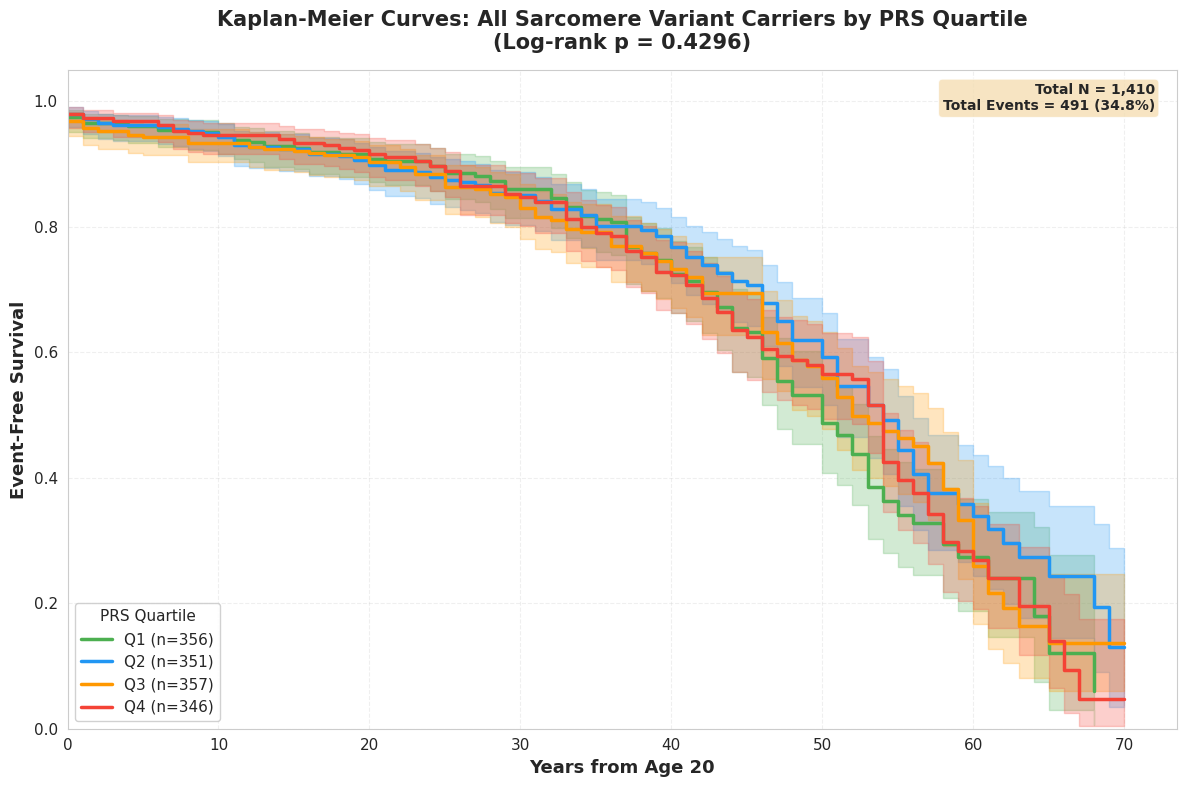


 Plot saved as 'km_curve_all_carriers_by_prs_quartile_v3.png'

EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS

5-Year Event-Free Survival:
  Q1: 96.0% (95% CI: 93.4% - 97.6%)
  Q2: 96.3% (95% CI: 93.7% - 97.8%)
  Q3: 94.4% (95% CI: 91.4% - 96.3%)
  Q4: 96.8% (95% CI: 94.3% - 98.2%)

10-Year Event-Free Survival:
  Q1: 94.5% (95% CI: 91.6% - 96.5%)
  Q2: 94.4% (95% CI: 91.3% - 96.4%)
  Q3: 93.4% (95% CI: 90.3% - 95.6%)
  Q4: 94.6% (95% CI: 91.6% - 96.6%)

15-Year Event-Free Survival:
  Q1: 92.6% (95% CI: 89.2% - 94.9%)
  Q2: 92.4% (95% CI: 88.9% - 94.8%)
  Q3: 92.1% (95% CI: 88.7% - 94.5%)
  Q4: 93.3% (95% CI: 90.0% - 95.6%)

20-Year Event-Free Survival:
  Q1: 90.8% (95% CI: 87.1% - 93.5%)
  Q2: 89.8% (95% CI: 85.9% - 92.7%)
  Q3: 90.3% (95% CI: 86.6% - 93.1%)
  Q4: 91.6% (95% CI: 87.9% - 94.1%)

30-Year Event-Free Survival:
  Q1: 86.0% (95% CI: 81.4% - 89.5%)
  Q2: 85.0% (95% CI: 80.4% - 88.7%)
  Q3: 83.0% (95% CI: 78.0% - 86.9%)
  Q4: 84.8% (95% CI: 80.1% - 88.5%)

40-Year Event-Free Sur

In [76]:
print("KAPLAN-MEIER ANALYSIS: All Carriers by PRS Quartile")

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import numpy as np

# Get person_ids from cleaned age-based table
query_clean_ids = f"""
SELECT DISTINCT person_id
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based`
"""

clean_ids = client.query(query_clean_ids).to_dataframe()

print(f"Clean IDs from age-based table: {len(clean_ids):,}")

# Get ALL data from original table, filtered to clean IDs
query_all_carriers = f"""
SELECT 
  co.person_id,
  co.cohort,
  co.composite_followup_years,
  co.composite_event,
  co.first_event_type,
  co.prs,
  co.prs_quartile
  
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.carriers_composite_outcome` co
INNER JOIN `{PROJECT_ID}.{SCRATCH_DATASET_ID}.carriers_composite_outcome_age_based` clean
  ON co.person_id = clean.person_id
"""

df_composite = client.query(query_all_carriers).to_dataframe()

print(f"TOTAL CARRIERS: {len(df_composite):,}")
print(f"  - HCM: {len(df_composite[df_composite['cohort']=='HCM']):,}")
print(f"  - GenPop: {len(df_composite[df_composite['cohort']=='GenPop']):,}")
print(f"  - Total Events: {df_composite['composite_event'].sum():,}")

kmf = KaplanMeierFitter()

# Create single plot
fig, ax = plt.subplots(figsize=(12, 8))

# Define colors for quartiles
colors_quartiles = {
    1: '#4CAF50',  # Green - Low risk
    2: '#2196F3',  # Blue
    3: '#FF9800',  # Orange
    4: '#F44336'   # Red - High risk
}

print("ALL CARRIERS - Stratified by PRS Quartile")

for q in [1, 2, 3, 4]:
    df_q = df_composite[df_composite['prs_quartile'] == q]
    n = len(df_q)
    events = df_q['composite_event'].sum()
    
    print(f"\nQ{q}:")
    print(f"  N = {n:,}")
    print(f"  Events = {events:,} ({100*events/n:.1f}%)")
    print(f"  PRS range: {df_q['prs'].min():.3f} to {df_q['prs'].max():.3f}")
    
    kmf.fit(
        durations=df_q['composite_followup_years'],
        event_observed=df_q['composite_event'],
        label=f'Q{q} (n={n:,})'
    )
    kmf.plot_survival_function(ax=ax, ci_show=True, color=colors_quartiles[q], linewidth=2.5)

# Log-rank test across all quartiles
result = multivariate_logrank_test(
    df_composite['composite_followup_years'],
    df_composite['prs_quartile'],
    df_composite['composite_event']
)

print(f"\nLog-rank test (all quartiles):")
print(f"  Chi-square = {result.test_statistic:.2f}")
print(f"  p-value = {result.p_value:.4f}")

ax.set_xlabel('Years from Age 20', fontsize=13, fontweight='bold')
ax.set_ylabel('Event-Free Survival', fontsize=13, fontweight='bold')
ax.set_title(f'Kaplan-Meier Curves: All Sarcomere Variant Carriers by PRS Quartile\n(Log-rank p = {result.p_value:.4f})', 
              fontsize=15, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='lower left', fontsize=11, framealpha=0.9, title='PRS Quartile')
ax.set_ylim([0, 1.05])
ax.set_xlim([0, None])

# Add sample size text box
n_total = len(df_composite)
events_total = df_composite['composite_event'].sum()
text_box = f"Total N = {n_total:,}\nTotal Events = {events_total:,} ({100*events_total/n_total:.1f}%)"
ax.text(0.98, 0.98, text_box, transform=ax.transAxes,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('km_curve_all_carriers_by_prs_quartile_v3.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Plot saved as 'km_curve_all_carriers_by_prs_quartile_v3.png'")

print("EVENT-FREE SURVIVAL AT SPECIFIC TIME POINTS")

time_points = [5, 10, 15, 20, 30, 40]

for t in time_points:
    print(f"\n{t}-Year Event-Free Survival:")
    for q in [1, 2, 3, 4]:
        df_q = df_composite[df_composite['prs_quartile'] == q]
        kmf.fit(df_q['composite_followup_years'], df_q['composite_event'])
        
        if t <= kmf.survival_function_.index.max():
            surv_prob = kmf.predict(t)
            ci = kmf.confidence_interval_survival_function_.loc[
                kmf.confidence_interval_survival_function_.index <= t
            ].iloc[-1]
            
            print(f"  Q{q}: {100*surv_prob:.1f}% (95% CI: {100*ci.iloc[0]:.1f}% - {100*ci.iloc[1]:.1f}%)")
        else:
            print(f"  Q{q}: Insufficient follow-up")

print("PAIRWISE LOG-RANK TESTS")

from lifelines.statistics import logrank_test

comparisons = [(1, 4), (1, 3), (2, 4)]

for q1, q2 in comparisons:
    df_q1 = df_composite[df_composite['prs_quartile'] == q1]
    df_q2 = df_composite[df_composite['prs_quartile'] == q2]
    
    result_pair = logrank_test(
        df_q1['composite_followup_years'],
        df_q2['composite_followup_years'],
        df_q1['composite_event'],
        df_q2['composite_event']
    )
    
    print(f"\nQ{q1} vs Q{q2}:")
    print(f"  Chi-square = {result_pair.test_statistic:.2f}")
    print(f"  p-value = {result_pair.p_value:.4f}")


In [79]:
# ============================================================================
# DATASET 1: Main Scratch Dataset (carriers analysis)
# ============================================================================

print(f"DATASET 1: {PROJECT_ID}.{SCRATCH_DATASET_ID}")

query_tables_1 = f"""
SELECT table_name
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.INFORMATION_SCHEMA.TABLES`
WHERE table_type = 'BASE TABLE'
ORDER BY table_name
"""

df_tables_1 = client.query(query_tables_1).to_dataframe()
print(f"\nTotal tables: {len(df_tables_1)}")
print("\nTable names:")
print(df_tables_1['table_name'].tolist())

# Loop through each table and show columns + head
for table_name in df_tables_1['table_name']:
    print(f"\n{'-'*80}")
    print(f"TABLE: {table_name}")
    print(f"{'-'*80}")
    
    # Get columns
    query_cols = f"""
    SELECT column_name, data_type
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{table_name}'
    ORDER BY ordinal_position
    """
    
    df_cols = client.query(query_cols).to_dataframe()
    print(f"\nColumns ({len(df_cols)}):")
    print(df_cols.to_string(index=False))
    
    # Get row count
    query_count = f"""
    SELECT COUNT(*) as row_count
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.{table_name}`
    """
    
    df_count = client.query(query_count).to_dataframe()
    print(f"\nTotal rows: {df_count['row_count'].iloc[0]:,}")
    
    # Get head (first 3 rows)
    query_head = f"""
    SELECT *
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.{table_name}`
    LIMIT 3
    """
    
    try:
        df_head = client.query(query_head).to_dataframe()
        print(f"\nFirst 3 rows:")
        print(df_head.to_string(index=False))
    except Exception as e:
        print(f"\nError fetching head: {e}")

# ============================================================================
# DATASET 2: HCM Scratch Dataset
# ============================================================================

print(f"\n\n{'='*80}")
print(f"DATASET 2: {PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}")
print(f"{'='*80}")

query_tables_2 = f"""
SELECT table_name
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.INFORMATION_SCHEMA.TABLES`
WHERE table_type = 'BASE TABLE'
ORDER BY table_name
"""

df_tables_2 = client.query(query_tables_2).to_dataframe()
print(f"\nTotal tables: {len(df_tables_2)}")
print("\nTable names:")
print(df_tables_2['table_name'].tolist())

# Loop through each table and show columns + head
for table_name in df_tables_2['table_name']:
    print(f"\n{'-'*80}")
    print(f"TABLE: {table_name}")
    print(f"{'-'*80}")
    
    # Get columns
    query_cols = f"""
    SELECT column_name, data_type
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.INFORMATION_SCHEMA.COLUMNS`
    WHERE table_name = '{table_name}'
    ORDER BY ordinal_position
    """
    
    df_cols = client.query(query_cols).to_dataframe()
    print(f"\nColumns ({len(df_cols)}):")
    print(df_cols.to_string(index=False))
    
    # Get row count
    query_count = f"""
    SELECT COUNT(*) as row_count
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.{table_name}`
    """
    
    df_count = client.query(query_count).to_dataframe()
    print(f"\nTotal rows: {df_count['row_count'].iloc[0]:,}")
    
    # Get head (first 3 rows)
    query_head = f"""
    SELECT *
    FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID_HCM}.{table_name}`
    LIMIT 3
    """
    
    try:
        df_head = client.query(query_head).to_dataframe()
        print(f"\nFirst 3 rows:")
        print(df_head.to_string(index=False))
    except Exception as e:
        print(f"\nError fetching head: {e}")

# ============================================================================
# SUMMARY
# ============================================================================

print(f"""
Dataset 1 ({SCRATCH_DATASET_ID}): {len(df_tables_1)} tables
Dataset 2 ({SCRATCH_DATASET_ID_HCM}): {len(df_tables_2)} tables
Total: {len(df_tables_1) + len(df_tables_2)} tables
""")

DATASET 1: nb-tre-dev-2-483522.gen_pop_carriers

Total tables: 17

Table names:
['carriers_composite_outcome_age_based', 'gen_pop_carrier_demographics', 'gen_pop_carriers_all_composite_events', 'gen_pop_carriers_all_composite_events_dedup', 'gen_pop_carriers_composite_outcome', 'gen_pop_carriers_death_events', 'gen_pop_carriers_event_mapping', 'gen_pop_carriers_intervention_events', 'gen_pop_carriers_last_visit_dates', 'gen_pop_carriers_mace_events', 'gen_pop_carriers_survival_age_based', 'gen_pop_carriers_survival_data', 'gen_pop_carriers_variants', 'model1_gen_pop_carriers', 'prs_scores_gen_pop_carriers', 'staging_cardiac_conditions', 'staging_cardiac_procedures']

--------------------------------------------------------------------------------
TABLE: carriers_composite_outcome_age_based
--------------------------------------------------------------------------------

Columns (33):
                column_name data_type
                  person_id    STRING
                 is_carrier

STEP 0A: BASELINE AGE BY PRS QUARTILE

 Querying baseline age data...

Total unique patients: 1510

Age summary:
count       1510.0
mean     57.308609
std      21.507287
min            5.0
25%           41.0
50%           59.0
75%           74.0
max          110.0
Name: current_age, dtype: Float64

STEP 0B: AGE DISTRIBUTION BY PRS QUARTILE

 Current Age by PRS Quartile:
 prs_quartile   n       mean  median        std  min  max
            1 378  56.981481    60.0   20.96624    9  104
            2 378  57.185185    60.0  21.976901    5  105
            3 377  56.580902    56.0  20.724881    5  110
            4 377  58.488064    60.0  22.356528    6  102

STEP 0C: TESTING FOR AGE DIFFERENCES ACROSS QUARTILES

 Sample sizes:
  Q1: 378
  Q2: 378
  Q3: 377
  Q4: 377

 ANOVA Test (parametric):
  F-statistic: 0.555
  P-value: 0.6451

 Kruskal-Wallis Test (non-parametric):
  H-statistic: 2.378
  P-value: 0.4977

 INTERPRETATION:
   No significant age difference across quartiles (p = 0.6451)


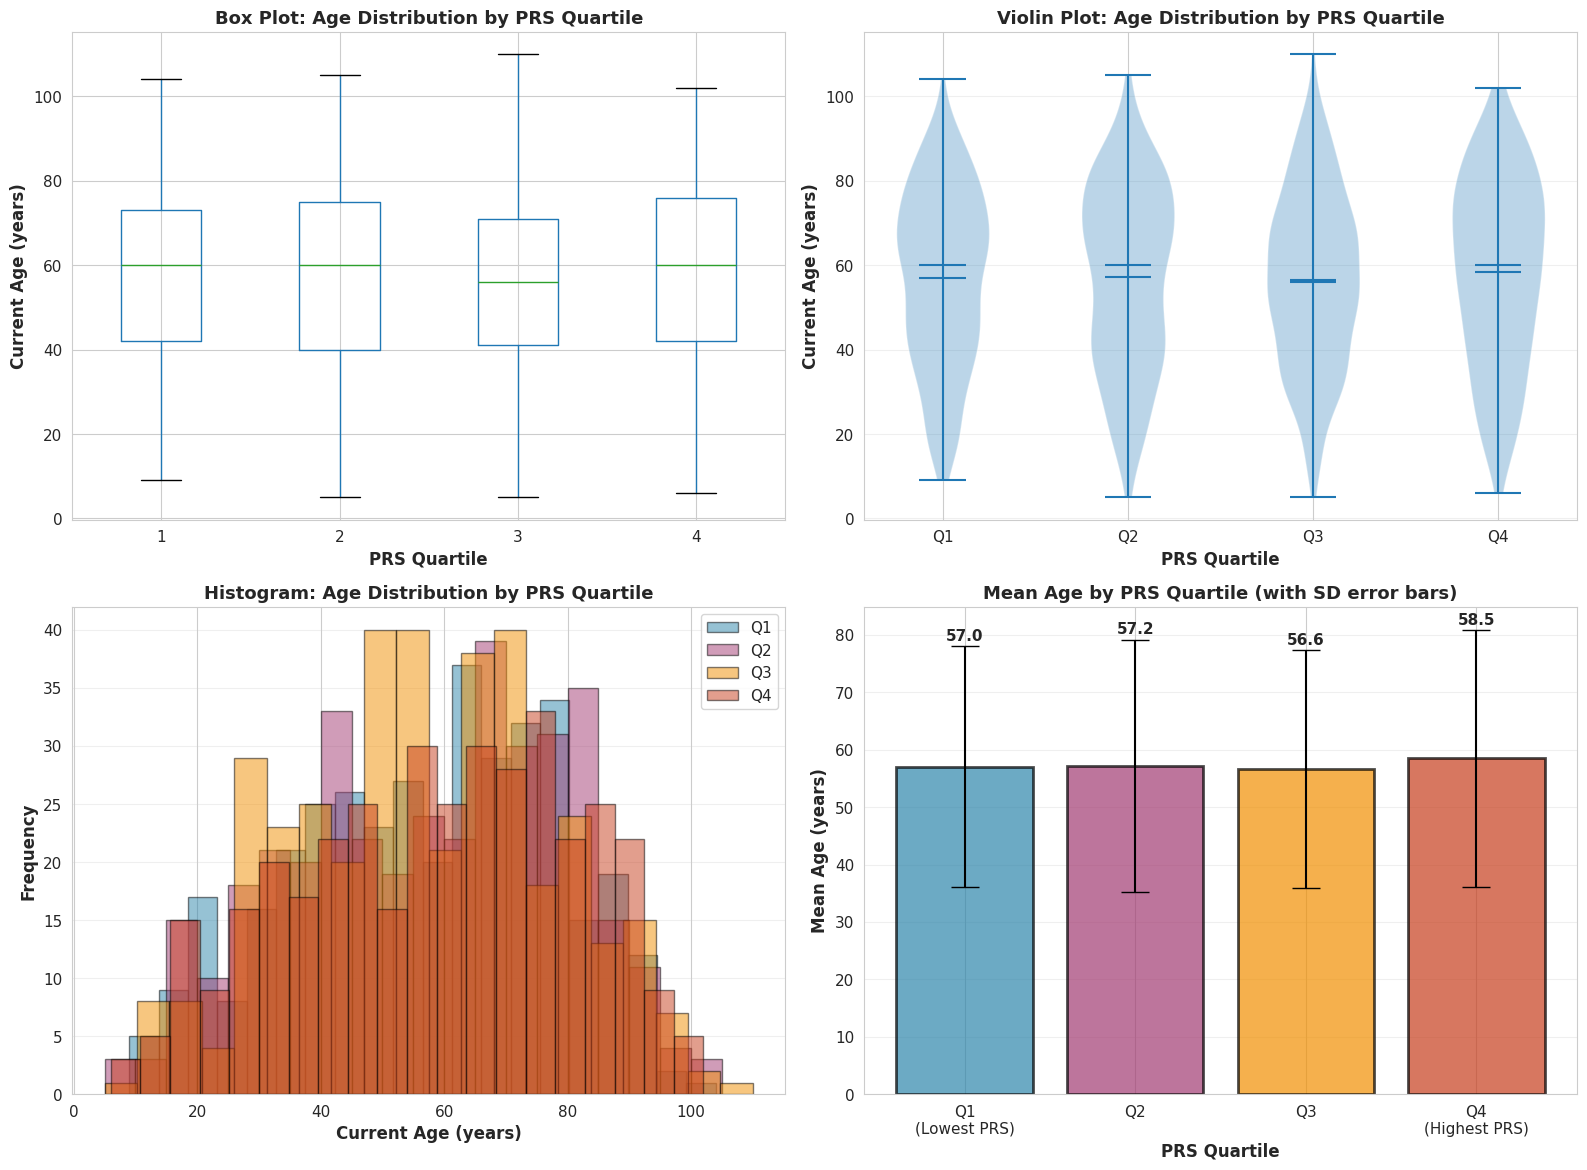


STEP 0F: CORRELATION BETWEEN PRS AND AGE

 Pearson Correlation (PRS vs Age):
  r = 0.039
  p-value = 0.1295

 Spearman Correlation (PRS vs Age):
  rho = 0.032
  p-value = 0.2200

 Correlation plot saved as 'prs_age_correlation.png'


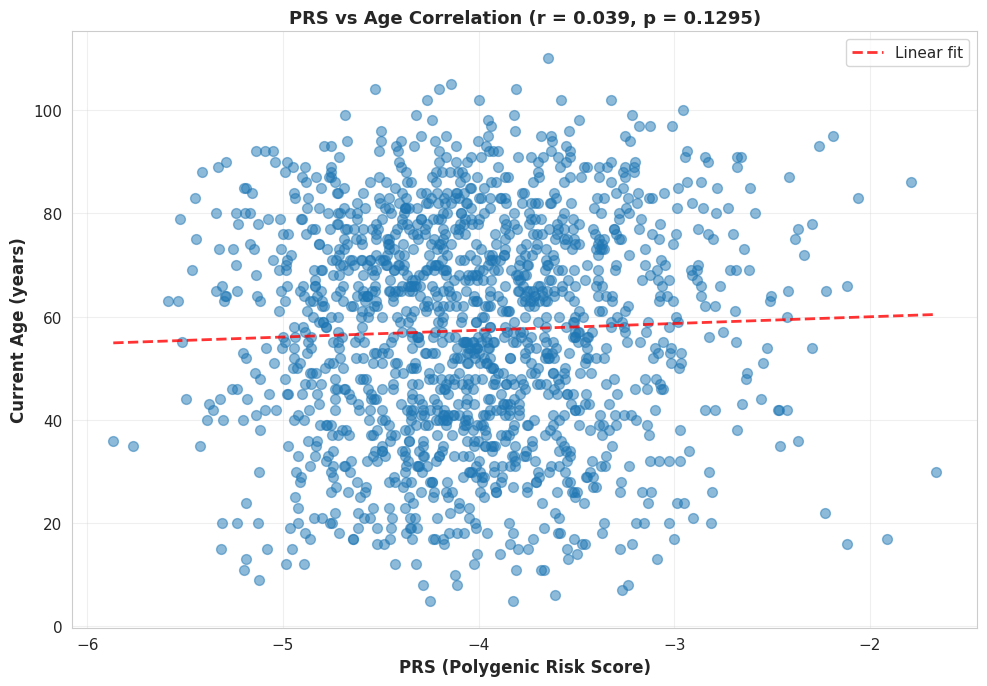

In [81]:
import pandas as pd
import numpy as np
from scipy.stats import f_oneway, kruskal
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STEP 0A: GET BASELINE CHARACTERISTICS BY PRS QUARTILE
# ============================================================================

print("STEP 0A: BASELINE AGE BY PRS QUARTILE")

# First, let's see what we have in the base gen_pop_carriers table
query_baseline_age = f"""
SELECT 
  person_id,
  birth_datetime,
  prs,
  prs_quartile,
  -- Calculate current age
  DATE_DIFF(CURRENT_DATE(), PARSE_DATE('%Y-%m-%d', SUBSTR(birth_datetime, 1, 10)), YEAR) as current_age
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE prs_quartile IS NOT NULL
GROUP BY person_id, birth_datetime, prs, prs_quartile
"""

print("\n Querying baseline age data...")
df_baseline_age = client.query(query_baseline_age).to_dataframe()

print(f"\nTotal unique patients: {len(df_baseline_age)}")
print(f"\nAge summary:")
print(df_baseline_age['current_age'].describe())

# ============================================================================
# STEP 0B: AGE DISTRIBUTION BY QUARTILE
# ============================================================================

print("\n" + "="*80)
print("STEP 0B: AGE DISTRIBUTION BY PRS QUARTILE")
print("="*80)

age_by_quartile = df_baseline_age.groupby('prs_quartile')['current_age'].agg([
    ('n', 'count'),
    ('mean', 'mean'),
    ('median', 'median'),
    ('std', 'std'),
    ('min', 'min'),
    ('max', 'max')
]).reset_index()

print("\n Current Age by PRS Quartile:")
print("="*80)
print(age_by_quartile.to_string(index=False))

# ============================================================================
# STEP 0C: STATISTICAL TEST FOR AGE DIFFERENCES
# ============================================================================

print("\n" + "="*80)
print("STEP 0C: TESTING FOR AGE DIFFERENCES ACROSS QUARTILES")
print("="*80)

# Extract age by quartile
q1_age = df_baseline_age[df_baseline_age['prs_quartile'] == 1]['current_age'].dropna()
q2_age = df_baseline_age[df_baseline_age['prs_quartile'] == 2]['current_age'].dropna()
q3_age = df_baseline_age[df_baseline_age['prs_quartile'] == 3]['current_age'].dropna()
q4_age = df_baseline_age[df_baseline_age['prs_quartile'] == 4]['current_age'].dropna()

print(f"\n Sample sizes:")
print(f"  Q1: {len(q1_age)}")
print(f"  Q2: {len(q2_age)}")
print(f"  Q3: {len(q3_age)}")
print(f"  Q4: {len(q4_age)}")

# ANOVA (parametric test)
if all(len(q) > 0 for q in [q1_age, q2_age, q3_age, q4_age]):
    f_stat, p_val_anova = f_oneway(q1_age, q2_age, q3_age, q4_age)
    print(f"\n ANOVA Test (parametric):")
    print(f"  F-statistic: {f_stat:.3f}")
    print(f"  P-value: {p_val_anova:.4f}")
    
    # Kruskal-Wallis (non-parametric alternative)
    h_stat, p_val_kruskal = kruskal(q1_age, q2_age, q3_age, q4_age)
    print(f"\n Kruskal-Wallis Test (non-parametric):")
    print(f"  H-statistic: {h_stat:.3f}")
    print(f"  P-value: {p_val_kruskal:.4f}")
    
    # Interpretation
    print(f"\n INTERPRETATION:")
    if p_val_anova < 0.05:
        print(f"    SIGNIFICANT age difference across quartiles (p = {p_val_anova:.4f})")
        print(f"   Age is a potential CONFOUNDER")
    else:
        print(f"   No significant age difference across quartiles (p = {p_val_anova:.4f})")
        print(f"   Age adjustment less critical but still recommended")
        print(f"   Can show both unadjusted and adjusted results")

# ============================================================================
# STEP 0D: PAIRWISE COMPARISONS (Q4 vs Q1)
# ============================================================================

print("\n" + "="*80)
print("STEP 0D: PAIRWISE COMPARISON (Q4 vs Q1)")
print("="*80)

from scipy.stats import ttest_ind, mannwhitneyu

# T-test
t_stat, p_val_ttest = ttest_ind(q4_age, q1_age)
print(f"\n T-test (Q4 vs Q1):")
print(f"  Q1 mean age: {q1_age.mean():.1f} ± {q1_age.std():.1f}")
print(f"  Q4 mean age: {q4_age.mean():.1f} ± {q4_age.std():.1f}")
print(f"  Difference: {q4_age.mean() - q1_age.mean():.1f} years")
print(f"  T-statistic: {t_stat:.3f}")
print(f"  P-value: {p_val_ttest:.4f}")

# Mann-Whitney U
u_stat, p_val_mw = mannwhitneyu(q4_age, q1_age, alternative='two-sided')
print(f"\n Mann-Whitney U Test (Q4 vs Q1):")
print(f"  Q1 median age: {q1_age.median():.1f}")
print(f"  Q4 median age: {q4_age.median():.1f}")
print(f"  U-statistic: {u_stat:.0f}")
print(f"  P-value: {p_val_mw:.4f}")

# ============================================================================
# STEP 0E: VISUALIZE AGE DISTRIBUTIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 0E: VISUALIZING AGE DISTRIBUTIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Box plot
ax1 = axes[0, 0]
df_baseline_age.boxplot(column='current_age', by='prs_quartile', ax=ax1)
ax1.set_xlabel('PRS Quartile', fontsize=12, fontweight='bold')
ax1.set_ylabel('Current Age (years)', fontsize=12, fontweight='bold')
ax1.set_title('Box Plot: Age Distribution by PRS Quartile', fontsize=13, fontweight='bold')
ax1.get_figure().suptitle('')  # Remove default title
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

# Plot 2: Violin plot
ax2 = axes[0, 1]
parts = ax2.violinplot([q1_age, q2_age, q3_age, q4_age], 
                        positions=[1, 2, 3, 4],
                        showmeans=True, showmedians=True)
ax2.set_xlabel('PRS Quartile', fontsize=12, fontweight='bold')
ax2.set_ylabel('Current Age (years)', fontsize=12, fontweight='bold')
ax2.set_title('Violin Plot: Age Distribution by PRS Quartile', fontsize=13, fontweight='bold')
ax2.set_xticks([1, 2, 3, 4])
ax2.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Histogram overlays
ax3 = axes[1, 0]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
labels = ['Q1', 'Q2', 'Q3', 'Q4']
for q, color, label in zip([q1_age, q2_age, q3_age, q4_age], colors, labels):
    ax3.hist(q, bins=20, alpha=0.5, color=color, label=label, edgecolor='black')
ax3.set_xlabel('Current Age (years)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Histogram: Age Distribution by PRS Quartile', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Mean age with error bars
ax4 = axes[1, 1]
means = age_by_quartile['mean']
stds = age_by_quartile['std']
quartiles = age_by_quartile['prs_quartile']

ax4.bar(quartiles, means, yerr=stds, capsize=10, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax4.set_xlabel('PRS Quartile', fontsize=12, fontweight='bold')
ax4.set_ylabel('Mean Age (years)', fontsize=12, fontweight='bold')
ax4.set_title('Mean Age by PRS Quartile (with SD error bars)', fontsize=13, fontweight='bold')
ax4.set_xticks([1, 2, 3, 4])
ax4.set_xticklabels(['Q1\n(Lowest PRS)', 'Q2', 'Q3', 'Q4\n(Highest PRS)'])
ax4.grid(axis='y', alpha=0.3)

# Add mean values on bars
for i, (q, m) in enumerate(zip(quartiles, means)):
    ax4.text(q, m + stds.iloc[i] + 1, f'{m:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('prs_quartile_age_distribution.png', dpi=300, bbox_inches='tight')
print("\n Age distribution plots saved as 'prs_quartile_age_distribution.png'")
plt.show()

# ============================================================================
# STEP 0F: CORRELATION BETWEEN PRS AND AGE
# ============================================================================

print("\n" + "="*80)
print("STEP 0F: CORRELATION BETWEEN PRS AND AGE")
print("="*80)

from scipy.stats import pearsonr, spearmanr

# Remove any missing values
df_corr = df_baseline_age[['prs', 'current_age']].dropna()

# Pearson correlation
r_pearson, p_pearson = pearsonr(df_corr['prs'], df_corr['current_age'])
print(f"\n Pearson Correlation (PRS vs Age):")
print(f"  r = {r_pearson:.3f}")
print(f"  p-value = {p_pearson:.4f}")

# Spearman correlation
r_spearman, p_spearman = spearmanr(df_corr['prs'], df_corr['current_age'])
print(f"\n Spearman Correlation (PRS vs Age):")
print(f"  rho = {r_spearman:.3f}")
print(f"  p-value = {p_spearman:.4f}")

# Scatter plot
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
scatter = ax.scatter(df_corr['prs'], df_corr['current_age'], alpha=0.5, s=50)
ax.set_xlabel('PRS (Polygenic Risk Score)', fontsize=12, fontweight='bold')
ax.set_ylabel('Current Age (years)', fontsize=12, fontweight='bold')
ax.set_title(f'PRS vs Age Correlation (r = {r_pearson:.3f}, p = {p_pearson:.4f})', 
            fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)

# Add regression line
z = np.polyfit(df_corr['prs'], df_corr['current_age'], 1)
p = np.poly1d(z)
ax.plot(df_corr['prs'].sort_values(), p(df_corr['prs'].sort_values()), 
        "r--", alpha=0.8, linewidth=2, label=f'Linear fit')
ax.legend()

plt.tight_layout()
plt.savefig('prs_age_correlation.png', dpi=300, bbox_inches='tight')
print("\n Correlation plot saved as 'prs_age_correlation.png'")
plt.show()



STEP 1: GET EVENT DATA BY PRS QUARTILE

 Getting cohort sizes by quartile...

 Cohort sizes by PRS quartile:
 prs_quartile  n_patients
            1         378
            2         378
            3         377
            4         377

Total patients: 1510

 Querying event counts...

Total event records: 57
Unique event categories: 15

 Sample of event rates:
 prs_quartile         event_category  patients_with_event  n_patients  event_rate_pct
            1    Atrial Fibrillation                   60         378       15.873016
            1       Cardiac Ablation                   11         378        2.910053
            1         Cardiac Arrest                    7         378        1.851852
            1      Cardiogenic Shock                    7         378        1.851852
            1                  Death                   25         378        6.613757
            1                    HCM                   16         378        4.232804
            1          Heart Fai

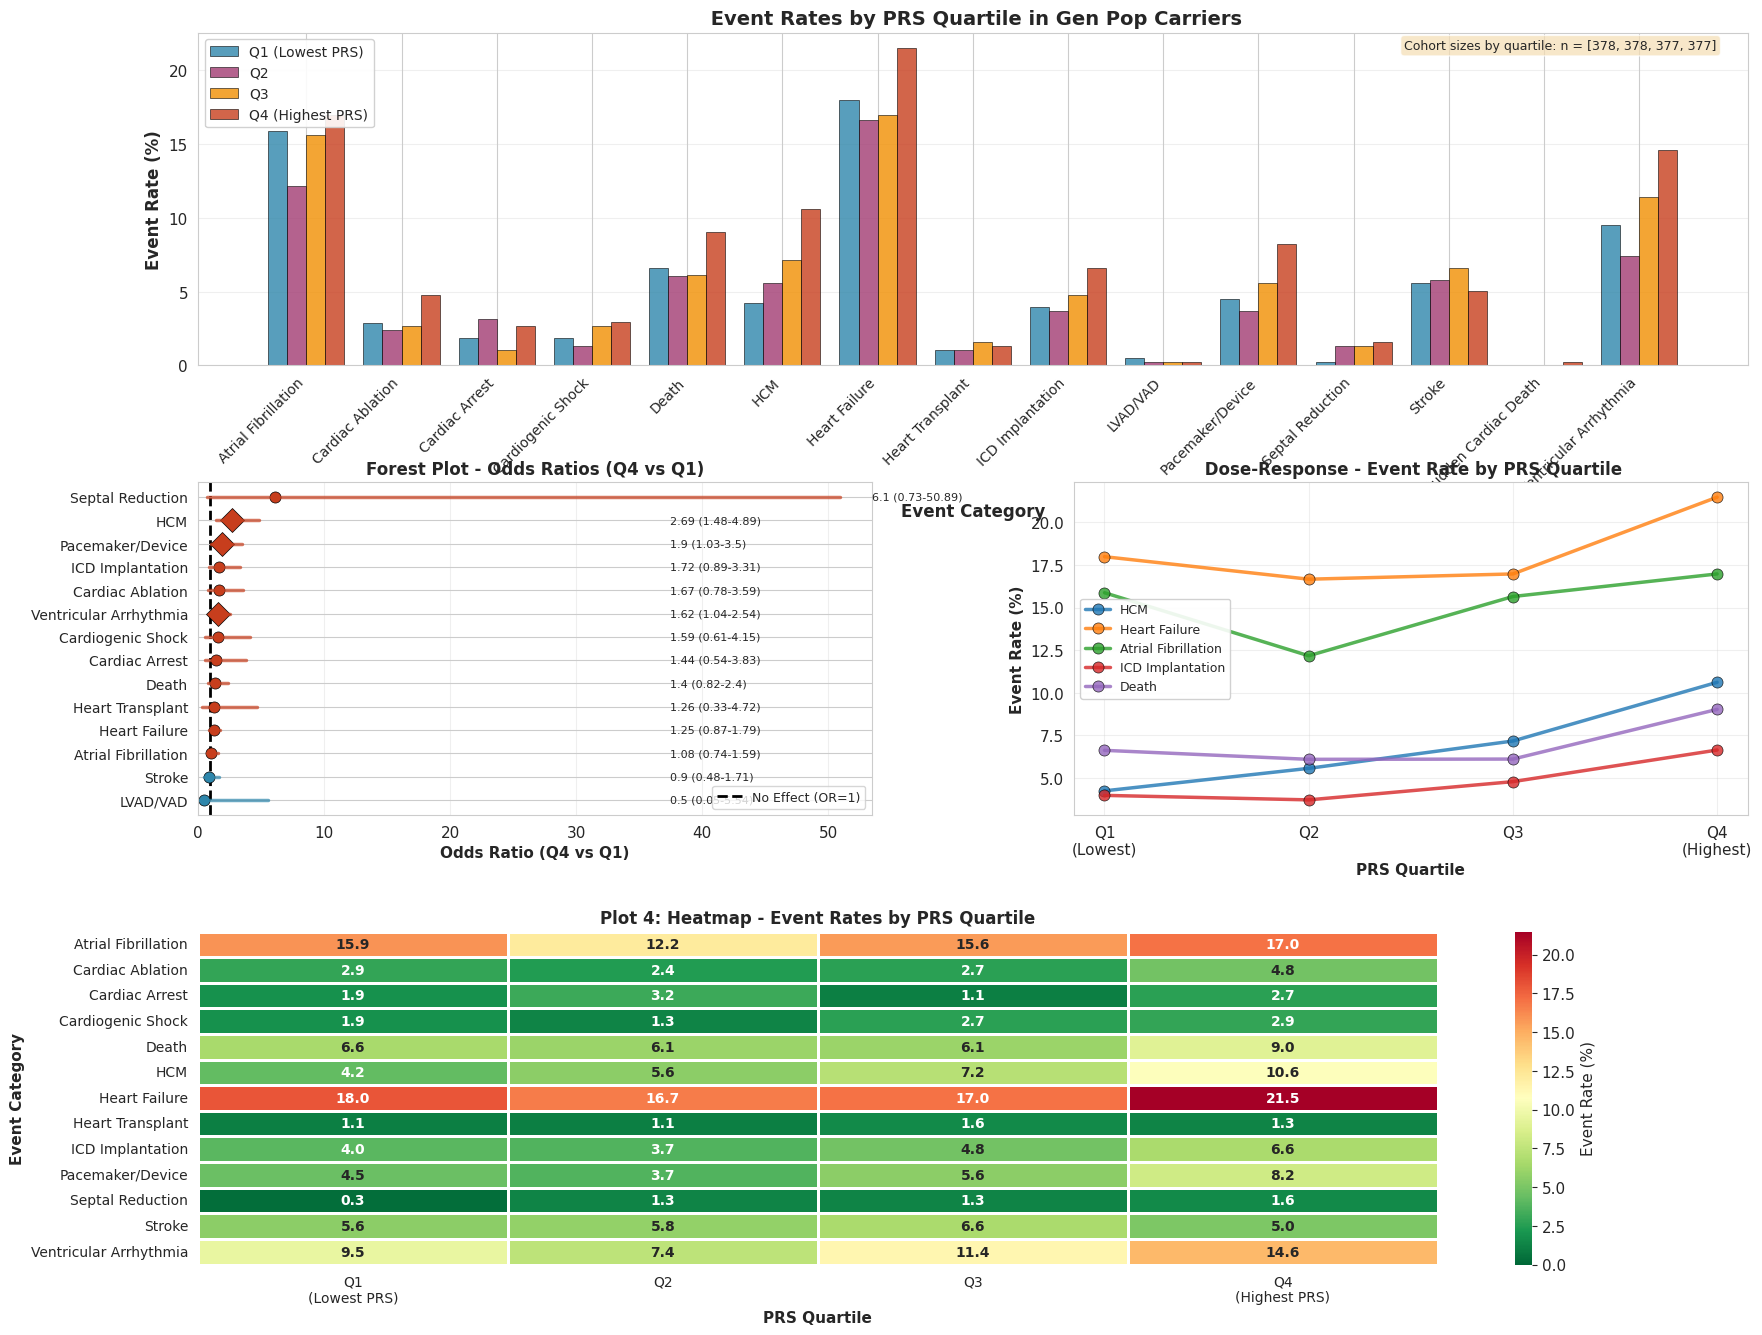


STEP 5: KEY FINDINGS SUMMARY

 COHORT SUMMARY:
  Total Gen Pop Carriers: 1510
  Q1: 378 patients
  Q2: 378 patients
  Q3: 377 patients
  Q4: 377 patients

 SIGNIFICANT ASSOCIATIONS (p < 0.05): 3

   HCM:
    Q1: 4.2% (16/378)
    Q4: 10.6% (40/377)
    OR: 2.69 (95% CI: 1.48-4.89)
    P-value: 0.0008 ***
    → Q4 has HIGHER risk

   Pacemaker/Device:
    Q1: 4.5% (17/378)
    Q4: 8.2% (31/377)
    OR: 1.9 (95% CI: 1.03-3.5)
    P-value: 0.0377 *
    → Q4 has HIGHER risk

   Ventricular Arrhythmia:
    Q1: 9.5% (36/378)
    Q4: 14.6% (55/377)
    OR: 1.62 (95% CI: 1.04-2.54)
    P-value: 0.0341 *
    → Q4 has HIGHER risk

 TRENDS (OR > 1.5 or < 0.67, not significant):

   Sudden Cardiac Death:
    OR: Inf (95% CI: N/A-N/A), p = 0.4993
    Q1: 0.0% vs Q4: 0.3%

   Septal Reduction:
    OR: 6.1 (95% CI: 0.73-50.89), p = 0.0689
    Q1: 0.3% vs Q4: 1.6%

   ICD Implantation:
    OR: 1.72 (95% CI: 0.89-3.31), p = 0.1073
    Q1: 4.0% vs Q4: 6.6%

   Cardiac Ablation:
    OR: 1.67 (95% CI: 0.

In [87]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# STEP 1: DATA PREPARATION
# ============================================================================
print("STEP 1: GET EVENT DATA BY PRS QUARTILE")

# Get unique patients per quartile (denominator)
query_cohort_size = f"""
SELECT 
  prs_quartile,
  COUNT(DISTINCT person_id) as n_patients
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE prs_quartile IS NOT NULL
GROUP BY prs_quartile
ORDER BY prs_quartile
"""

print("\n Getting cohort sizes by quartile...")
df_cohort_size = client.query(query_cohort_size).to_dataframe()

print("\n Cohort sizes by PRS quartile:")
print(df_cohort_size.to_string(index=False))
print(f"\nTotal patients: {df_cohort_size['n_patients'].sum()}")

# Get event counts by quartile and category
query_events = f"""
SELECT 
  prs_quartile,
  event_category,
  COUNT(DISTINCT person_id) as patients_with_event
FROM `{PROJECT_ID}.{SCRATCH_DATASET_ID}.gen_pop_carriers_all_composite_events_dedup`
WHERE prs_quartile IS NOT NULL
  AND event_category IS NOT NULL
  AND event_category != 'None'
GROUP BY prs_quartile, event_category
ORDER BY prs_quartile, event_category
"""

print("\n Querying event counts...")
df_events = client.query(query_events).to_dataframe()

print(f"\nTotal event records: {len(df_events)}")
print(f"Unique event categories: {df_events['event_category'].nunique()}")

# Merge to calculate rates
df_event_rates = df_events.merge(df_cohort_size, on='prs_quartile')
df_event_rates['event_rate_pct'] = 100 * df_event_rates['patients_with_event'] / df_event_rates['n_patients']

print("\n Sample of event rates:")
print(df_event_rates.head(20).to_string(index=False))

# ============================================================================
# STEP 2: CALCULATE ODDS RATIOS (Q4 vs Q1)
# ============================================================================

print("\n" + "="*80)
print("STEP 2: CALCULATE ODDS RATIOS (Q4 vs Q1, Reference = Q1)")
print("="*80)

# Define key event categories
key_events = [
    'HCM',
    'Heart Failure',
    'Atrial Fibrillation',
    'Ventricular Arrhythmia',
    'ICD Implantation',
    'Stroke',
    'Death',
    'Cardiac Arrest',
    'Heart Transplant',
    'Septal Reduction',
    'Cardiac Ablation',
    'LVAD/VAD',
    'Pacemaker/Device',
    'Cardiogenic Shock',
    'Sudden Cardiac Death'
]

or_results = []

for event_cat in key_events:
    
    # Get Q1 data
    q1_data = df_event_rates[(df_event_rates['prs_quartile'] == 1) & 
                              (df_event_rates['event_category'] == event_cat)]
    
    # Get Q4 data
    q4_data = df_event_rates[(df_event_rates['prs_quartile'] == 4) & 
                              (df_event_rates['event_category'] == event_cat)]
    
    # Get cohort sizes
    q1_total = df_cohort_size[df_cohort_size['prs_quartile'] == 1]['n_patients'].values[0]
    q4_total = df_cohort_size[df_cohort_size['prs_quartile'] == 4]['n_patients'].values[0]
    
    if len(q1_data) > 0 and len(q4_data) > 0:
        q1_events = q1_data['patients_with_event'].values[0]
        q1_rate = q1_data['event_rate_pct'].values[0]
        
        q4_events = q4_data['patients_with_event'].values[0]
        q4_rate = q4_data['event_rate_pct'].values[0]
    elif len(q1_data) > 0:
        # Event only in Q1
        q1_events = q1_data['patients_with_event'].values[0]
        q1_rate = q1_data['event_rate_pct'].values[0]
        q4_events = 0
        q4_rate = 0.0
    elif len(q4_data) > 0:
        # Event only in Q4
        q1_events = 0
        q1_rate = 0.0
        q4_events = q4_data['patients_with_event'].values[0]
        q4_rate = q4_data['event_rate_pct'].values[0]
    else:
        # Event in neither
        q1_events = 0
        q1_rate = 0.0
        q4_events = 0
        q4_rate = 0.0
    
    # Skip if no events in either group
    if q1_events == 0 and q4_events == 0:
        continue
    
    # 2x2 contingency table
    contingency = np.array([
        [q4_events, q4_total - q4_events],
        [q1_events, q1_total - q1_events]
    ])
    
    # Calculate OR
    if q1_events > 0 and q4_events > 0:
        or_value = (q4_events / (q4_total - q4_events)) / (q1_events / (q1_total - q1_events))
        
        # Calculate 95% CI
        log_or = np.log(or_value)
        se_log_or = np.sqrt(1/q4_events + 1/(q4_total-q4_events) + 1/q1_events + 1/(q1_total-q1_events))
        ci_lower = np.exp(log_or - 1.96 * se_log_or)
        ci_upper = np.exp(log_or + 1.96 * se_log_or)
        
        # Fisher's exact test
        oddsratio, p_val = fisher_exact(contingency)
        
    elif q1_events == 0 and q4_events > 0:
        # Only events in Q4
        or_value = np.inf
        ci_lower = np.nan
        ci_upper = np.nan
        _, p_val = fisher_exact(contingency)
    elif q4_events == 0 and q1_events > 0:
        # Only events in Q1
        or_value = 0
        ci_lower = np.nan
        ci_upper = np.nan
        _, p_val = fisher_exact(contingency)
    else:
        or_value = np.nan
        ci_lower = np.nan
        ci_upper = np.nan
        p_val = np.nan
    
    or_results.append({
        'Event_Category': event_cat,
        'Q1_Events': int(q1_events),
        'Q1_Total': int(q1_total),
        'Q1_Rate': round(q1_rate, 1),
        'Q4_Events': int(q4_events),
        'Q4_Total': int(q4_total),
        'Q4_Rate': round(q4_rate, 1),
        'OR': round(or_value, 2) if not np.isnan(or_value) and not np.isinf(or_value) else ('Inf' if np.isinf(or_value) else 'N/A'),
        'CI_Lower': round(ci_lower, 2) if not np.isnan(ci_lower) else 'N/A',
        'CI_Upper': round(ci_upper, 2) if not np.isnan(ci_upper) else 'N/A',
        'P_value': round(p_val, 4) if not np.isnan(p_val) else 'N/A',
        'Significant': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    })

df_or_results = pd.DataFrame(or_results)

# Sort by OR (numeric only)
df_or_results['OR_numeric'] = pd.to_numeric(df_or_results['OR'], errors='coerce')
df_or_results = df_or_results.sort_values('OR_numeric', ascending=False)

print("\n ODDS RATIOS (Q4 vs Q1, Reference = Q1):")
print("="*100)
print(f"{'Event Category':<25} {'Q1 Rate':>10} {'Q4 Rate':>10} {'OR':>8} {'95% CI':>20} {'P-value':>10} {'Sig':>5}")
print("-"*100)

for _, row in df_or_results.iterrows():
    ci_str = f"({row['CI_Lower']}-{row['CI_Upper']})" if row['CI_Lower'] != 'N/A' else 'N/A'
    print(f"{row['Event_Category']:<25} "
          f"{row['Q1_Rate']:>9.1f}% "
          f"{row['Q4_Rate']:>9.1f}% "
          f"{str(row['OR']):>7} "
          f"{ci_str:>20} "
          f"{str(row['P_value']):>9} "
          f"{row['Significant']:>3}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")

# ============================================================================
# STEP 3: CALCULATE DOSE-RESPONSE (ALL QUARTILES)
# ============================================================================

print("\n" + "="*80)
print("STEP 3: DOSE-RESPONSE ANALYSIS (Q2, Q3, Q4 vs Q1)")
print("="*80)

# For top events, calculate OR for each quartile vs Q1
top_events_for_trend = ['HCM', 'Heart Failure', 'Atrial Fibrillation', 'ICD Implantation', 'Death']

dose_response_results = []

for event_cat in top_events_for_trend:
    q1_data = df_event_rates[(df_event_rates['prs_quartile'] == 1) & 
                              (df_event_rates['event_category'] == event_cat)]
    q1_total = df_cohort_size[df_cohort_size['prs_quartile'] == 1]['n_patients'].values[0]
    
    if len(q1_data) > 0:
        q1_events = q1_data['patients_with_event'].values[0]
    else:
        q1_events = 0
    
    for q in [2, 3, 4]:
        qx_data = df_event_rates[(df_event_rates['prs_quartile'] == q) & 
                                  (df_event_rates['event_category'] == event_cat)]
        qx_total = df_cohort_size[df_cohort_size['prs_quartile'] == q]['n_patients'].values[0]
        
        if len(qx_data) > 0:
            qx_events = qx_data['patients_with_event'].values[0]
            qx_rate = qx_data['event_rate_pct'].values[0]
        else:
            qx_events = 0
            qx_rate = 0.0
        
        if q1_events > 0 and qx_events > 0:
            or_value = (qx_events / (qx_total - qx_events)) / (q1_events / (q1_total - q1_events))
        else:
            or_value = np.nan
        
        dose_response_results.append({
            'Event': event_cat,
            'Quartile': f'Q{q}',
            'Quartile_Num': q,
            'OR': or_value,
            'Rate': qx_rate
        })

df_dose_response = pd.DataFrame(dose_response_results)

print("\n Dose-Response ORs (vs Q1):")
for event in top_events_for_trend:
    event_data = df_dose_response[df_dose_response['Event'] == event]
    if len(event_data) > 0:
        print(f"\n{event}:")
        for _, row in event_data.iterrows():
            if not np.isnan(row['OR']):
                print(f"  {row['Quartile']}: OR = {row['OR']:.2f}, Rate = {row['Rate']:.1f}%")

# ============================================================================
# STEP 4: VISUALIZATIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 4: CREATING VISUALIZATIONS")
print("="*80)

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# ============================================================================
# PLOT 1: EVENT RATES BY PRS QUARTILE (BAR CHART)
# ============================================================================

ax1 = fig.add_subplot(gs[0, :])

# Prepare data - focus on events that occurred
events_to_plot = df_or_results[df_or_results['Q1_Events'] + df_or_results['Q4_Events'] > 0]['Event_Category'].tolist()
plot_data = df_event_rates[df_event_rates['event_category'].isin(events_to_plot)]

# Pivot for plotting
pivot_data = plot_data.pivot(index='event_category', columns='prs_quartile', values='event_rate_pct').fillna(0)

x = np.arange(len(pivot_data.index))
width = 0.2

colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
labels = ['Q1 (Lowest PRS)', 'Q2', 'Q3', 'Q4 (Highest PRS)']

for i, (quartile, color, label) in enumerate(zip([1, 2, 3, 4], colors, labels)):
    if quartile in pivot_data.columns:
        offset = width * (i - 1.5)
        bars = ax1.bar(x + offset, pivot_data[quartile], width, label=label, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)

ax1.set_xlabel('Event Category', fontsize=12, fontweight='bold')
ax1.set_ylabel('Event Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title(' Event Rates by PRS Quartile in Gen Pop Carriers', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pivot_data.index, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)

# Add sample sizes
cohort_text = f"n = {df_cohort_size['n_patients'].tolist()}"
ax1.text(0.98, 0.98, f'Cohort sizes by quartile: {cohort_text}', 
         transform=ax1.transAxes, ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7), fontsize=9)

# ============================================================================
# PLOT 2: FOREST PLOT OF ODDS RATIOS
# ============================================================================

ax2 = fig.add_subplot(gs[1, 0])

# Prepare forest plot data
df_forest = df_or_results[df_or_results['OR'] != 'N/A'].copy()
df_forest = df_forest[df_forest['OR'] != 'Inf'].copy()
df_forest['OR_num'] = pd.to_numeric(df_forest['OR'])
df_forest['CI_Lower_num'] = pd.to_numeric(df_forest['CI_Lower'])
df_forest['CI_Upper_num'] = pd.to_numeric(df_forest['CI_Upper'])
df_forest = df_forest.sort_values('OR_num', ascending=True)

y_pos = np.arange(len(df_forest))

# Plot points and CIs
for i, (idx, row) in enumerate(df_forest.iterrows()):
    color = '#C73E1D' if row['OR_num'] > 1 else '#2E86AB'
    marker = 'D' if row['Significant'] else 'o'
    markersize = 12 if row['Significant'] else 8
    
    ax2.plot(row['OR_num'], i, marker, color=color, markersize=markersize, markeredgecolor='black', markeredgewidth=0.5)
    ax2.plot([row['CI_Lower_num'], row['CI_Upper_num']], [i, i], '-', color=color, linewidth=2.5, alpha=0.7)

ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Effect (OR=1)', zorder=0)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(df_forest['Event_Category'], fontsize=10)
ax2.set_xlabel('Odds Ratio (Q4 vs Q1)', fontsize=11, fontweight='bold')
ax2.set_title('Forest Plot - Odds Ratios (Q4 vs Q1)', fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(axis='x', alpha=0.3)
ax2.set_xlim(left=0)

# Add OR values as text
for i, (idx, row) in enumerate(df_forest.iterrows()):
    text_x = max(row['CI_Upper_num'] * 1.05, ax2.get_xlim()[1] * 0.7)
    ax2.text(text_x, i, f"{row['OR']} ({row['CI_Lower']}-{row['CI_Upper']})", 
            va='center', fontsize=8)

# ============================================================================
# PLOT 3: DOSE-RESPONSE CURVES
# ============================================================================

ax3 = fig.add_subplot(gs[1, 1])

# Plot event rates across all quartiles
for event in top_events_for_trend:
    event_data = df_event_rates[df_event_rates['event_category'] == event].sort_values('prs_quartile')
    if len(event_data) > 0:
        ax3.plot(event_data['prs_quartile'], event_data['event_rate_pct'], 
                marker='o', linewidth=2.5, markersize=8, label=event, alpha=0.8, markeredgecolor='black', markeredgewidth=0.5)

ax3.set_xlabel('PRS Quartile', fontsize=11, fontweight='bold')
ax3.set_ylabel('Event Rate (%)', fontsize=11, fontweight='bold')
ax3.set_title(' Dose-Response - Event Rate by PRS Quartile', fontsize=12, fontweight='bold')
ax3.set_xticks([1, 2, 3, 4])
ax3.set_xticklabels(['Q1\n(Lowest)', 'Q2', 'Q3', 'Q4\n(Highest)'])
ax3.legend(loc='best', fontsize=9, framealpha=0.9)
ax3.grid(alpha=0.3)

# ============================================================================
# PLOT 4: HEATMAP
# ============================================================================

ax4 = fig.add_subplot(gs[2, :])

# Prepare heatmap data
heatmap_events = df_or_results[df_or_results['Q1_Events'] + df_or_results['Q4_Events'] > 5]['Event_Category'].tolist()

if len(heatmap_events) > 0:
    heatmap_data = df_event_rates[df_event_rates['event_category'].isin(heatmap_events)]
    
    # Create pivot and explicitly handle missing quartiles
    heatmap_pivot = heatmap_data.pivot(index='event_category', columns='prs_quartile', values='event_rate_pct')
    
    # Ensure we have all quartiles (fill missing with 0)
    for q in [1, 2, 3, 4]:
        if q not in heatmap_pivot.columns:
            heatmap_pivot[q] = 0.0
    
    # Reorder columns and select only 1,2,3,4
    heatmap_pivot = heatmap_pivot[[1, 2, 3, 4]]
    
    # Fill any NaN values with 0
    heatmap_pivot = heatmap_pivot.fillna(0)
    
    # NOW rename columns AFTER we have the right structure
    heatmap_pivot.columns = ['Q1', 'Q2', 'Q3', 'Q4']
    
    # Double check all values are numeric
    print("\n Heatmap pivot after cleaning:")
    print(heatmap_pivot)
    print(f"\nDtypes: {heatmap_pivot.dtypes}")
    print(f"\nValues dtype: {heatmap_pivot.values.dtype}")
    
    # Force conversion to float
    heatmap_pivot = heatmap_pivot.astype(float)
    
    sns.heatmap(heatmap_pivot, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax4,
               cbar_kws={'label': 'Event Rate (%)'}, linewidths=1, vmin=0, 
               annot_kws={'fontsize': 10, 'fontweight': 'bold'})
    
    ax4.set_title('Plot 4: Heatmap - Event Rates by PRS Quartile', fontsize=12, fontweight='bold')
    ax4.set_xlabel('PRS Quartile', fontsize=11, fontweight='bold')
    ax4.set_ylabel('Event Category', fontsize=11, fontweight='bold')
    ax4.set_xticklabels(['Q1\n(Lowest PRS)', 'Q2', 'Q3', 'Q4\n(Highest PRS)'], rotation=0, fontsize=10)
    ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=10)
else:
    # If no events meet criteria, show message
    ax4.text(0.5, 0.5, 'Insufficient events for heatmap\n(threshold: >5 events in Q1+Q4)', 
            ha='center', va='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))
    ax4.set_title(' Heatmap - Event Rates by PRS Quartile', fontsize=12, fontweight='bold')
    ax4.axis('off')

plt.savefig('prs_quartile_event_analysis.png', dpi=300, bbox_inches='tight')
print("\n Visualizations saved as 'prs_quartile_event_analysis.png'")
plt.show()

# ============================================================================
# STEP 5: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 5: KEY FINDINGS SUMMARY")
print("="*80)

print(f"\n COHORT SUMMARY:")
print(f"  Total Gen Pop Carriers: {df_cohort_size['n_patients'].sum()}")
for _, row in df_cohort_size.iterrows():
    print(f"  Q{row['prs_quartile']}: {row['n_patients']} patients")

sig_results = df_or_results[df_or_results['Significant'] != '']
print(f"\n SIGNIFICANT ASSOCIATIONS (p < 0.05): {len(sig_results)}")
if len(sig_results) > 0:
    for _, row in sig_results.iterrows():
        direction = "HIGHER" if pd.to_numeric(row['OR']) > 1 else "LOWER"
        print(f"\n   {row['Event_Category']}:")
        print(f"    Q1: {row['Q1_Rate']}% ({row['Q1_Events']}/{row['Q1_Total']})")
        print(f"    Q4: {row['Q4_Rate']}% ({row['Q4_Events']}/{row['Q4_Total']})")
        print(f"    OR: {row['OR']} (95% CI: {row['CI_Lower']}-{row['CI_Upper']})")
        print(f"    P-value: {row['P_value']} {row['Significant']}")
        print(f"    → Q4 has {direction} risk")
else:
    print("  None - No significant associations between PRS quartile and event risk")

print(f"\n TRENDS (OR > 1.5 or < 0.67, not significant):")
trends = df_or_results[(df_or_results['Significant'] == '') & 
                       (df_or_results['OR_numeric'].notna())]
notable = trends[(trends['OR_numeric'] > 1.5) | (trends['OR_numeric'] < 0.67)]

if len(notable) > 0:
    for _, row in notable.iterrows():
        print(f"\n   {row['Event_Category']}:")
        print(f"    OR: {row['OR']} (95% CI: {row['CI_Lower']}-{row['CI_Upper']}), p = {row['P_value']}")
        print(f"    Q1: {row['Q1_Rate']}% vs Q4: {row['Q4_Rate']}%")
else:
    print("  None identified")